In [ ]:
# FAN SENTIMENT ANALYSIS PIPELINE — pysentimiento RoBERTa Edition
# Raw Apify Instagram comment data → structured insights
# Upgrade: replaced generic BERT with pysentimiento social-media-tuned RoBERTa

# Install dependencies
!pip install -q pysentimiento
!pip install -q emoji langdetect
!pip install -q scikit-learn pandas numpy matplotlib seaborn wordcloud

# Imports
import pandas as pd
import numpy as np
import re
import json
import warnings
from datetime import datetime
from collections import Counter

import emoji
from langdetect import detect, LangDetectException
from pysentimiento import create_analyzer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

print("All imports loaded.")

# Load & inspect raw Apify data
CSV_PATH = "/content/Full_Instagram_merged_dataset.csv"

PLATFORM = "instagram"

df_raw = pd.read_csv(CSV_PATH)

print(f"Raw shape: {df_raw.shape}")
print(f"Columns ({len(df_raw.columns)}): {df_raw.columns.tolist()}")
print(f"\nNull counts for key columns:")
print(df_raw[["text", "likesCount", "repliesCount", "timestamp",
              "ownerUsername", "postUrl"]].isnull().sum())
print(f"\nUnique posts: {df_raw['postUrl'].nunique()}")
print(f"\nSample texts:")
df_raw["text"].dropna().head(8).apply(lambda x: print(" ", repr(x)))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 26.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 31.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
All imports loaded.
Raw shape: (12167, 53)
Columns (53): ['commentUrl', 'error', 'errorDescription', 'id', 'inputUrl', 'likesCount', 'media/gif_media_id', 'media/id', 'media/images/fixed_height/height', 'media/images/fixed_height/mp4', 'media/images/fixed_height/mp4_size', 'media/images/fixed_height/size', 'media/images/fixed_height/url', 'media/images/fixed_height/webp', 'media/images/fixed_height/webp_size', 'media/images/fixed_height/width', 'media/is_sticker', 'media/title', 'media/username', 'owner/fbid_v2', 'owner/full_name', 'owner/id', 'owner/is_mentionable', 'owner/is_private', 'owner/is_verified', 'owner/profile_pic_id', 'owner/profile_pic_url', 'owner/username', 'ownerProfilePicUrl', 'ownerUsername', 'parentCommentUrl', 'postUrl', 'replies/0/id', 'replies/0/likesCount', 'repl

,text
0,None
1,None
2,None
3,None
4,None
5,None
6,None
7,None


In [ ]:
# MODULE 1: Data Extraction & Flattening
class ApifyFlattener:
    KEEP_MAP = {
        "id":                   "comment_id",
        "text":                 "raw_text",
        "likesCount":           "likes",
        "repliesCount":         "replies_count",
        "timestamp":            "timestamp",
        "postUrl":              "post_url",
        "commentUrl":           "comment_url",
        "parentCommentUrl":     "parent_comment_url",
        "ownerUsername":        "author_username",
        "owner/full_name":      "author_full_name",
        "owner/is_verified":    "author_is_verified",
        "owner/is_private":     "author_is_private",
        "owner/is_mentionable": "author_is_mentionable",
    }

    def fit_transform(self, df: pd.DataFrame,
                      platform: str = "instagram") -> pd.DataFrame:
        available = {k: v for k, v in self.KEEP_MAP.items() if k in df.columns}
        out = df[list(available.keys())].rename(columns=available).copy()
        out["timestamp"]   = pd.to_datetime(out["timestamp"], utc=True, errors="coerce")
        out["date"]        = out["timestamp"].dt.date
        out["hour"]        = out["timestamp"].dt.hour
        out["day_of_week"] = out["timestamp"].dt.day_name()
        out["post_id"]     = out["post_url"].str.extract(r"/p/([^/]+)/|/reel/([^/]+)/").bfill(axis=1).iloc[:, 0]
        out["is_reply"]    = (out["parent_comment_url"].notna()
                              if "parent_comment_url" in out.columns else False)
        out["platform"]    = platform
        n_replies = int(out["is_reply"].sum())
        print(f" Flattened to {out.shape[1]} columns, {len(out)} rows.")
        print(f"   Platform: '{platform}' | Top-level: {(~out['is_reply']).sum()} | Replies: {n_replies}")
        return out


flattener = ApifyFlattener()
df = flattener.fit_transform(df_raw, platform=PLATFORM)
df.head(3)


# MODULE 2: Post Categorizer

POST_CAPTION_MAP = {}   # populate with {post_id: caption} when available

POST_CATEGORY_RULES = {
    "judge_posts": {
        "keywords": [r"\bjudge\b", r"\baaron judge\b", r"\b99\b"],
        "description": "Posts about Aaron Judge"
    },
    "cole_posts": {
        "keywords": [r"\bgerrit cole\b", r"\bcole\b", r"\bace\b"],
        "description": "Posts about Gerrit Cole"
    },
    "other_player_posts": {
        "keywords": [
            r"\bjuan soto\b", r"\bsoto\b", r"\bgiancarlo stanton\b", r"\bstanton\b",
            r"\bjazz chisholm\b", r"\bchisholm\b", r"\banthony volpe\b", r"\bvolpe\b",
            r"\bcarlos rodon\b", r"\brodon\b", r"\bnestor cortes\b", r"\bcortes\b",
            r"\bben rice\b", r"\bluis gil\b", r"\bplayer\b", r"\broster\b",
            r"\bprospect\b", r"\bcall.?up\b",
        ],
        "description": "Posts mentioning other Yankees players"
    },
    "divisional_opponents": {
        "keywords": [
            r"\borioles\b", r"\bred sox\b", r"\brays\b", r"\bblue jays\b", r"\bal east\b",
        ],
        "description": "AL East divisional opponent posts"
    },
    "big_market_rivals": {
        "keywords": [r"\bdodgers\b", r"\bmets\b", r"\bsubway series\b"],
        "description": "Dodgers / Mets rival posts"
    },
    "world_baseball_classic": {
        "keywords": [r"\bworld baseball classic\b", r"\bwbc\b"],
        "description": "WBC content"
    },
    "lockout_2027": {
        "keywords": [r"\blockout\b", r"\blabor (dispute|deal)\b", r"\bstrike\b.*\bbaseball\b"],
        "description": "2027 lockout discussion"
    },
    "cba_salary_cap": {
        "keywords": [r"\bcba\b", r"\bsalary cap\b", r"\bluxury tax\b", r"\bpayroll\b"],
        "description": "CBA / salary cap discussion"
    },
    "non_yankee_events": {
        "keywords": [r"\bconcert\b", r"\bjay.?z\b", r"\bnfl\b", r"\bfootball\b.*\bstadium\b"],
        "description": "Non-baseball stadium events"
    },
    "general_yankees": {
        "keywords": [
            r"\byankees\b", r"\bpinstripes\b", r"\bbronx bombers\b",
            r"\byanks\b", r"\byankee stadium\b",
        ],
        "description": "General Yankees content"
    },
}

# Rival / non-Yankees team patterns
NON_YANKEE_PATTERNS = [
    r"\bjays\b", r"\bblue jays\b", r"\bgo jays\b",
    r"\bmarlins\b", r"\bdodgers\b", r"\bdodger\b",
    r"\bred sox\b", r"\borioles\b", r"\brays\b",
    r"\bcubs\b", r"\bbraves\b", r"\bphillies\b",
    r"\bpadres\b", r"\bastros\b", r"\bguardians\b",
    r"\btwins\b", r"\bangels\b", r"\brockies\b",
    r"\bpirates\b", r"\bgiants\b", r"\bcardinals\b",
]

# Yankees keywords that override a rival mention
YANKEE_OVERRIDE_PATTERN = re.compile(
    r"\byankees\b|\byanks\b|\bbronx\b|\bpinstripes\b"
    r"|\bjudge\b|\bcole\b|\bsoto\b|\bstanton\b|\bvolpe\b|\bchisholm\b",
    re.IGNORECASE
)


class PostCategorizer:
    def __init__(self, rules=POST_CATEGORY_RULES, caption_map=POST_CAPTION_MAP):
        self.rules = {
            cat: {
                "patterns": [re.compile(kw, re.IGNORECASE | re.UNICODE)
                              for kw in cfg["keywords"]],
            }
            for cat, cfg in rules.items()
        }
        self.caption_map        = caption_map
        self.non_yankee_patterns = [re.compile(p, re.IGNORECASE)
                                     for p in NON_YANKEE_PATTERNS]

    def _match_text(self, text):
        if not isinstance(text, str) or not text.strip():
            return None
        for cat, cfg in self.rules.items():
            if any(p.search(text) for p in cfg["patterns"]):
                return cat
        return None

    def _categorize_post(self, post_id, agg_text):
        caption = self.caption_map.get(str(post_id), "")
        result  = self._match_text(caption) or self._match_text(agg_text)
        return result or "uncategorized_posts"

    def _is_non_yankee(self, text):
        if not isinstance(text, str) or not text.strip():
            return False
        if YANKEE_OVERRIDE_PATTERN.search(text):
            return False
        return any(p.search(text) for p in self.non_yankee_patterns)

    def transform(self, df):
        out = df.copy()
        post_text_agg = (
            out.groupby("post_id")["raw_text"]
               .apply(lambda x: " ".join(x.dropna()))
               .to_dict()
        )
        cat_map = {pid: self._categorize_post(pid, txt)
                   for pid, txt in post_text_agg.items()}
        out["post_category"] = out["post_id"].map(cat_map).fillna("uncategorized_posts")
        out["is_non_yankee"] = out["raw_text"].fillna("").apply(self._is_non_yankee)
        n_non_yankee = int(out["is_non_yankee"].sum())
        print(f"   Non-Yankees comments flagged: {n_non_yankee} "
              f"({n_non_yankee / len(out) * 100:.1f}%)")
        dist = out.drop_duplicates("post_id")["post_category"].value_counts()
        print(f"✅ Post categorization complete.\n{dist.to_string()}")
        return out


post_categorizer = PostCategorizer()
df = post_categorizer.transform(df)



# MODULE 3: Preprocessor
EMOJI_SENTIMENT = {
    "❤️": 1.0, "🔥": 0.9, "😍": 0.95, "🥹": 0.8, "🙌": 0.85,
    "👏": 0.8, "💪": 0.8, "⭐": 0.9, "🌟": 0.9, "🏆": 0.95,
    "😊": 0.75, "🥰": 0.9, "💯": 0.85, "🎉": 0.9, "👍": 0.7,
    "😂": 0.6,  "🤣": 0.6,  "😁": 0.7,  "♥️": 1.0, "💕": 0.9,
    "😮": 0.3,  "🤔": 0.1,  "👀": 0.2,
    "😤": -0.7, "😡": -0.9, "😢": -0.6, "😭": -0.5, "💔": -0.8,
    "👎": -0.7, "🤦": -0.5, "😒": -0.6, "😑": -0.4,
    "🙄": -0.3, "😬": -0.2,
    # Yankees-specific additions
    "⚾": 0.3, "🏟️": 0.4, "🎽": 0.3,
}

SLANG_MAP = {
    r"\bgoat\b": "greatest of all time", r"\blmao+\b": "laughing",
    r"\blol+\b": "laughing", r"\bomg\b": "oh my god",
    r"\bngl\b": "not gonna lie", r"\bfr\b": "for real",
    r"\bw\b": "win", r"\bl\b": "loss", r"\bgg\b": "good game",
    r"\bidk\b": "i don't know", r"\bsmh\b": "shaking my head",
    r"\bwtf\b": "what the", r"\bbruh\b": "bro",
    r"\bslay\b": "excellent", r"\bbanger\b": "excellent",
    r"\blit\b": "exciting", r"\bbussin\b": "excellent",
    r"\bno cap\b": "seriously", r"\bcap\b": "lie",
    r"\bbet\b": "okay agreed", r"\btbh\b": "to be honest",
    r"\brepbx\b": "represent the bronx", r"\byanks\b": "yankees",
    r"\bbronx bombers\b": "new york yankees",
    r"\bpinstripes\b": "yankees uniform",
    r"\blfg\b": "let's go", r"\bhim\b": "him dominating",
    r"\bhimmy\b": "him dominating",
    r"\ball rise\b": "aaron judge home run yankees",
    r"\bforever home\b": "yankee stadium beloved",
    r"\bour house\b": "yankee stadium home",
    r"\bbombers\b": "new york yankees",
}

BOT_PATTERNS = [
    r"follow me", r"check (my|out my) (page|profile|account)",
    r"dm (me|us) for", r"click (the )?link in (my|our) bio",
    r"get \d+% off", r"promo code", r"free (followers|likes)",
    r"make \$\d+", r"earn money", r"investment opportunity",
]


class Preprocessor:
    def __init__(self, emoji_sentiment=EMOJI_SENTIMENT,
                 slang_map=SLANG_MAP, bot_patterns=BOT_PATTERNS):
        self.emoji_sentiment = emoji_sentiment
        self.slang_map       = slang_map
        self.bot_patterns    = [re.compile(p, re.IGNORECASE) for p in bot_patterns]

    def detect_language(self, text):
        try:
            return detect(text)
        except Exception:
            return "unknown"

    def extract_emoji_features(self, text):
        if not isinstance(text, str):
            return {"emoji_list": [], "emoji_count": 0,
                    "distinct_emoji_count": 0, "emoji_sentiment_score": 0.0}
        found = [c for c in text if c in emoji.EMOJI_DATA]
        score = float(np.mean([self.emoji_sentiment.get(e, 0.0)
                                for e in found])) if found else 0.0
        return {"emoji_list": found, "emoji_count": len(found),
                "distinct_emoji_count": len(set(found)),
                "emoji_sentiment_score": round(score, 4)}

    def is_noise(self, text):
        if not isinstance(text, str):
            return False
        return any(p.search(text) for p in self.bot_patterns)

    def clean_text(self, text):
        if not isinstance(text, str) or not text.strip():
            return ""
        t = text
        t = t.replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
        t = re.sub(r"\s+", " ", t).strip()
        t = emoji.replace_emoji(t, replace=lambda c, _: f" {c} ")
        t = re.sub(r"@\w+", "@user", t)
        t = re.sub(r"#(\w+)", r"\1", t)
        t = re.sub(r"https?://\S+", "", t)
        t = re.sub(r"(.)\1{2,}", r"\1\1", t)
        t = re.sub(r"([!?.]){2,}", r"\1\1", t)
        for pattern, replacement in self.slang_map.items():
            t = re.sub(pattern, replacement, t, flags=re.IGNORECASE)
        return re.sub(r"\s+", " ", t).strip().lower()

    def classify_comment_type(self, raw, cleaned, emoji_count):
        if not isinstance(raw, str) or not raw.strip():
            return "empty"
        words = cleaned.split() if cleaned else []
        if not words and emoji_count > 0:
            return "emoji_only"
        if len(words) <= 3:
            return "short"
        if emoji_count / max(len(words), 1) > 0.5:
            return "emoji_heavy"
        return "standard"

    def transform(self, df):
        out = df.copy()
        print("  → Detecting language...")
        out["language"] = out["raw_text"].apply(
            lambda x: self.detect_language(x) if isinstance(x, str) else "unknown")
        print("  → Extracting emoji features...")
        ef = out["raw_text"].apply(self.extract_emoji_features)
        out["emoji_list"]            = ef.apply(lambda x: x["emoji_list"])
        out["emoji_count"]           = ef.apply(lambda x: x["emoji_count"])
        out["distinct_emoji_count"]  = ef.apply(lambda x: x["distinct_emoji_count"])
        out["emoji_sentiment_score"] = ef.apply(lambda x: x["emoji_sentiment_score"])
        print("  → Flagging noise / bots...")
        out["is_noise"]     = out["raw_text"].apply(self.is_noise)
        out["is_null_text"] = out["raw_text"].isna()
        print("  → Cleaning text...")
        out["cleaned_text"] = out["raw_text"].apply(self.clean_text)
        print("  → Classifying comment types...")
        out["comment_type"] = out.apply(
            lambda r: self.classify_comment_type(
                r["raw_text"], r["cleaned_text"], r["emoji_count"]), axis=1)
        print(f"✅ Preprocessing complete.")
        print(f"   Comment types: {out['comment_type'].value_counts().to_dict()}")
        print(f"   Languages:     {out['language'].value_counts().head(5).to_dict()}")
        print(f"   Noise flagged: {out['is_noise'].sum()} | Null texts: {out['is_null_text'].sum()}")
        return out


preprocessor = Preprocessor()
print("Running Preprocessor...")
df = preprocessor.transform(df)

# MODULE 4: Feature Engineer
class FeatureEngineer:
    def transform(self, df):
        out = df.copy()
        out["char_length"]       = out["raw_text"].fillna("").apply(len)
        out["word_count"]        = out["cleaned_text"].apply(
            lambda x: len(x.split()) if isinstance(x, str) else 0)
        out["sentence_count"]    = out["raw_text"].fillna("").apply(
            lambda x: max(1, len(re.split(r"[.!?]+", x))))
        out["exclamation_count"] = out["raw_text"].fillna("").apply(lambda x: x.count("!"))
        out["question_count"]    = out["raw_text"].fillna("").apply(lambda x: x.count("?"))
        out["caps_word_count"]   = out["raw_text"].fillna("").apply(
            lambda x: sum(1 for w in x.split() if w.isupper() and len(w) > 1))
        out["has_mention"]       = out["raw_text"].fillna("").apply(
            lambda x: bool(re.search(r"@\w+", x))).astype(int)
        out["has_hashtag"]       = out["raw_text"].fillna("").apply(
            lambda x: bool(re.search(r"#\w+", x))).astype(int)
        out["has_url"]           = out["raw_text"].fillna("").apply(
            lambda x: bool(re.search(r"https?://", x))).astype(int)
        out["emoji_density"]     = out.apply(
            lambda r: r["emoji_count"] / max(r["word_count"], 1), axis=1)
        out["log_likes"]         = np.log1p(out["likes"])
        out["log_replies"]       = np.log1p(out["replies_count"])
        out["has_replies"]       = (out["replies_count"] > 0).astype(int)
        out["intensity_raw"]     = (
            out["exclamation_count"].clip(0, 3) * 0.3 +
            out["caps_word_count"].clip(0, 5) * 0.2 +
            out["emoji_count"].clip(0, 5) * 0.2 +
            out["emoji_sentiment_score"].abs() * 0.3
        )
        out["intensity_level"] = pd.cut(
            out["intensity_raw"],
            bins=[-0.01, 0.25, 0.70, 100],
            labels=["mild", "moderate", "strong"]
        )
        print("✅ Feature engineering complete.")
        return out


feature_engineer = FeatureEngineer()
df = feature_engineer.transform(df)

# =============================================================================
# MODULE 4b: Game-Day Classifier
# =============================================================================
YANKEES_2024_GAME_DATES = {
    "2024-03-20","2024-03-21","2024-03-22",
    "2024-04-01","2024-04-02","2024-04-03","2024-04-04","2024-04-05",
    "2024-04-06","2024-04-07","2024-04-08","2024-04-09","2024-04-10",
    "2024-04-12","2024-04-13","2024-04-14","2024-04-15","2024-04-16",
    "2024-04-17","2024-04-19","2024-04-20","2024-04-21","2024-04-22",
    "2024-04-23","2024-04-24","2024-04-26","2024-04-27","2024-04-28",
    "2024-04-29","2024-04-30",
    "2024-05-01","2024-05-02","2024-05-03","2024-05-04","2024-05-05",
    "2024-05-06","2024-05-07","2024-05-08","2024-05-10","2024-05-11",
    "2024-05-12","2024-05-13","2024-05-14","2024-05-15","2024-05-16",
    "2024-05-17","2024-05-18","2024-05-19","2024-05-20","2024-05-21",
    "2024-05-22","2024-05-24","2024-05-25","2024-05-26","2024-05-27",
    "2024-05-28","2024-05-29","2024-05-30","2024-05-31",
    "2024-06-01","2024-06-02","2024-06-03","2024-06-04","2024-06-05",
    "2024-06-06","2024-06-07","2024-06-08","2024-06-09","2024-06-10",
    "2024-06-11","2024-06-12","2024-06-14","2024-06-15","2024-06-16",
    "2024-06-17","2024-06-18","2024-06-19","2024-06-20","2024-06-21",
    "2024-06-22","2024-06-23","2024-06-24","2024-06-25","2024-06-26",
    "2024-06-27","2024-06-28","2024-06-29","2024-06-30",
    "2024-07-01","2024-07-02","2024-07-03","2024-07-04","2024-07-05",
    "2024-07-06","2024-07-07","2024-07-08","2024-07-09","2024-07-10",
    "2024-07-11","2024-07-12","2024-07-19","2024-07-20","2024-07-21",
    "2024-07-22","2024-07-23","2024-07-24","2024-07-25","2024-07-26",
    "2024-07-27","2024-07-28","2024-07-29","2024-07-30","2024-07-31",
    "2024-08-01","2024-08-02","2024-08-03","2024-08-04","2024-08-05",
    "2024-08-06","2024-08-07","2024-08-08","2024-08-09","2024-08-10",
    "2024-08-11","2024-08-12","2024-08-13","2024-08-14","2024-08-15",
    "2024-08-16","2024-08-17","2024-08-18","2024-08-19","2024-08-20",
    "2024-08-21","2024-08-22","2024-08-23","2024-08-24","2024-08-25",
    "2024-08-26","2024-08-27","2024-08-28","2024-08-29","2024-08-30","2024-08-31",
    "2024-09-01","2024-09-02","2024-09-03","2024-09-04","2024-09-05",
    "2024-09-06","2024-09-07","2024-09-08","2024-09-09","2024-09-10",
    "2024-09-11","2024-09-12","2024-09-13","2024-09-14","2024-09-15",
    "2024-09-16","2024-09-17","2024-09-18","2024-09-19","2024-09-20",
    "2024-09-21","2024-09-22","2024-09-23","2024-09-24","2024-09-25",
    "2024-09-26","2024-09-27","2024-09-28","2024-09-29",
    "2024-10-01","2024-10-02","2024-10-05","2024-10-06","2024-10-07",
    "2024-10-08","2024-10-09","2024-10-10","2024-10-11","2024-10-14",
    "2024-10-15","2024-10-16","2024-10-17","2024-10-18","2024-10-19",
    "2024-10-22","2024-10-23","2024-10-25","2024-10-26","2024-10-27",
    "2024-10-28","2024-10-29","2024-10-30",
    "2025-03-27","2025-03-28","2025-03-29","2025-03-30","2025-03-31",
    "2025-04-01","2025-04-02","2025-04-03","2025-04-04","2025-04-05",
    "2025-04-07","2025-04-08","2025-04-09","2025-04-10","2025-04-11",
    "2025-04-12","2025-04-13","2025-04-14","2025-04-15","2025-04-16",
    "2025-04-18","2025-04-19","2025-04-20","2025-04-21","2025-04-22",
    "2025-04-23","2025-04-24","2025-04-25","2025-04-26","2025-04-27",
}

_GAME_DAY_PATTERNS = re.compile(
    r"\b(walk.?off|home run|homer|grand slam|strikeout|k'd|inning|at.?bat|"
    r"pitch count|bullpen|lineup|first pitch|play ball|game day|gameday|"
    r"let'?s go yanks|let'?s go yankees|we won|we lost|great win|tough loss|"
    r"w tonight|l tonight|took the series|sweep|comeback|clutch hit|"
    r"shut.?out|no.?hitter|perfect game|rbi|era tonight)\b",
    re.IGNORECASE
)

def _classify_gameday(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    date_str    = out["timestamp"].dt.strftime("%Y-%m-%d").fillna("")
    schedule_hit = date_str.isin(YANKEES_2024_GAME_DATES)
    keyword_hit  = out["raw_text"].fillna("").apply(
        lambda t: bool(_GAME_DAY_PATTERNS.search(str(t))))
    post_kw_rate = (out.assign(_kw=keyword_hit)
                      .groupby("post_id")["_kw"].mean()
                      .rename("post_kw_rate"))
    out = out.join(post_kw_rate, on="post_id")
    post_keyword_gd = out["post_kw_rate"] >= 0.15
    out["is_game_day"] = schedule_hit | post_keyword_gd
    out["game_context"] = "Non-Game Day"
    out.loc[schedule_hit & ~post_keyword_gd, "game_context"] = "Game Day (scheduled)"
    out.loc[~schedule_hit & post_keyword_gd,  "game_context"] = "Game Day (content)"
    out.loc[schedule_hit & post_keyword_gd,   "game_context"] = "Game Day (confirmed)"
    out.drop(columns=["post_kw_rate"], inplace=True)
    gd  = int(out["is_game_day"].sum())
    ngd = int((~out["is_game_day"]).sum())
    print(f"✅ Game-day classification complete.")
    print(f"   Game-day: {gd:,} ({gd/max(len(out),1)*100:.1f}%)  |  Non-game-day: {ngd:,}")
    print(out["game_context"].value_counts().to_string())
    return out

df = _classify_gameday(df)


 Flattened to 19 columns, 12167 rows.
   Platform: 'instagram' | Top-level: 8209 | Replies: 3958
   Non-Yankees comments flagged: 443 (3.6%)
✅ Post categorization complete.
post_category
judge_posts            46
other_player_posts      4
cole_posts              2
big_market_rivals       1
uncategorized_posts     1
Running Preprocessor...
  → Detecting language...
  → Extracting emoji features...
  → Flagging noise / bots...
  → Cleaning text...
  → Classifying comment types...
✅ Preprocessing complete.
   Comment types: {'standard': 7214, 'short': 2836, 'empty': 1245, 'emoji_heavy': 872}
   Languages:     {'en': 6502, 'unknown': 2614, 'es': 451, 'so': 245, 'de': 238}
   Noise flagged: 2 | Null texts: 1245
✅ Feature engineering complete.
✅ Game-day classification complete.
   Game-day: 0 (0.0%)  |  Non-game-day: 12,167
game_context
Non-Game Day    12167


In [ ]:

# =============================================================================
# MODULE 5: pysentimiento RoBERTa Sentiment + Emotion Classifier
# =============================================================================
# Stronger version:
# - runs RoBERTa on short comments too (not only >3 words)
# - adds richer Mixed detection
# - adds stronger sports/fan sarcasm handling
# - adds prediction quality / uncertainty flags
# - preserves original downstream columns so the rest of the notebook still works
# =============================================================================

POSITIVE_THRESHOLD = 0.08
NEGATIVE_THRESHOLD = -0.08
MIXED_POS_MIN      = 0.22
MIXED_NEG_MIN      = 0.22

BUSINESS_EMOTIONS = [
    "excitement", "joy", "pride", "frustration", "disappointment", "neutral"
]

PYSENTIMIENTO_EMOTION_MAP = {
    "joy":      "joy",
    "surprise": "excitement",
    "others":   "neutral",
    "sadness":  "disappointment",
    "disgust":  "frustration",
    "anger":    "frustration",
    "fear":     "frustration",
}

FAN_POSITIVE_PATTERNS = [
    # Classic hype / praise
    r"\blfg\b", r"\blet'?s\s+go\b", r"\bhim\b", r"\bhimmy\b",
    r"\bgoat\b", r"\bmvp\b", r"\bking\b", r"\bace\b", r"\bcaptain\b",
    r"\belite\b", r"\bgenerational\b", r"\bmonster\b", r"\bbeast\b",
    r"\bnasty\b", r"\bfilthy\b", r"\bcook(ing)?\b", r"\bclutch\b",
    r"\bbeautiful\b", r"\bincredible\b", r"\bamazing\b", r"\bperfect\b",
    r"\blove\b", r"\bfire\b", r"\blegend\b", r"\biconic\b",
    r"\bmy\s+guy\b", r"\bwhat a play\b", r"\binsane\b", r"\bunreal\b",
    r"\ball rise\b", r"\bforever home\b", r"\bour house\b",
    r"\bbronx bombers\b", r"\brepbx\b", r"\bpinstripes\b",
    r"\blet'?s go yankees\b", r"\bgo yanks\b", r"\bgo yankees\b",
    # NEW — baseball/Yankee fan specific
    r"\bpieced\s+it\s+up\b",       # "Pieced it up" = dominated a pitcher
    r"\bmammoth\s+homer\b",
    r"\byanks\s+year\b",
    r"\bgood\s+(game|lil|steal|catch|call|swing|pitch)\b",
    r"\bw\b",                        # single "W" = win
    # Multilingual
    r"\b역시\b",                     # Korean: "as expected / impressive"
    r"\bdueño\b",                    # Spanish: "the owner / the boss"
    r"\bmis\s+respetos\b",           # Spanish: "my respects"
    r"\bel\s+mejor\b",               # Spanish: "the best"
    r"\bque\s+swing\b",              # Spanish: "what a swing"
]

FAN_NEGATIVE_PATTERNS = [
    # Classic criticism
    r"\btrash\b", r"\bgarbage\b", r"\bawful\b", r"\bterrible\b",
    r"\bsucks?\b", r"\bwashed\b", r"\bfraud\b", r"\boverrated\b",
    r"\bbum\b", r"\bbozo\b", r"\bsoft\b", r"\bpathetic\b",
    r"\bembarrassing\b", r"\bchok(e|ed|ing)\b", r"\bbrutal\b",
    r"\bdisaster\b", r"\bworst\b", r"\bhorrible\b",
    r"\bfire boone\b", r"\bsell the team\b", r"\bwhat a joke\b",
    # NEW — contextual / sarcastic negatives
    r"\bgolden\s+sombrero\b",        # 4 strikeouts — always mocking
    r"\b0-3\b.*\bk(s)?\b",          # "0-3 3ks" — explicitly bad stat
    r"\brent\s+free\b",              # "living rent free" = ironic dig
    r"\bexcept\s+in\s+important\b",  # sarcasm: "except in important games"
    r"\bl\b",                        # single "L" = loss / negative
    r"\bsmh\b",
    r"\bmid\b",
    r"\bsame\s+old\b",
    r"\bblow(ing)?\s+(it|the game|the lead)\b",
    # Spanish negatives
    r"\bse\s+desaparece\b",          # "disappears" — criticism
    r"\bdolor\b",                    # "pain / sorrow"
    r"\bno\s+lo\s+necesitan\b",
    # Hateful short phrases (sarcastic love / real hate)
    r"\bi\s+hate\b",
    r"\bhate\s+you\b",
]

# (pattern, score_adjustment, label_if_dominant)
EMOJI_SPORT_MAP = [
    # Strongly positive
    (r"🐐",         +0.55, "Positive"),  # GOAT
    (r"👑",         +0.50, "Positive"),  # crown
    (r"🔥",         +0.45, "Positive"),  # fire / lit
    (r"💪",         +0.35, "Positive"),  # strength
    (r"🙌",         +0.35, "Positive"),  # celebration
    (r"❤️|❤",       +0.30, "Positive"),  # love
    (r"😍",         +0.30, "Positive"),  # adoration
    (r"🤩",         +0.30, "Positive"),  # star-struck
    (r"🫡",         +0.25, "Positive"),  # salute / respect
    (r"🤘",         +0.25, "Positive"),  # rock on / hype
    (r"⚾",         +0.10, None),        # baseball context, slight positive
    (r"🙏",         +0.10, None),        # prayer hands, context-dependent
    # Heritage / pride (positive in Yankees fan context)
    (r"🇩🇴",        +0.30, "Positive"),  # Dominican flag — Soto pride
    (r"🇵🇷",        +0.30, "Positive"),  # Puerto Rican flag
    (r"🇺🇸",        +0.10, None),
    # Playful
    (r"😛|😜|🤪",   +0.10, None),       # silly / playful
    (r"😂|🤣",      +0.10, None),       # laughing — usually positive
    (r"🏆",         +0.40, "Positive"),  # trophy
    # Negative
    (r"🧹",         -0.40, "Negative"),  # broom = rival sweep
    (r"😤",         -0.25, "Negative"),  # frustrated
    (r"😡",         -0.35, "Negative"),  # angry
    (r"🤬",         -0.45, "Negative"),  # very angry
    (r"😞",         -0.25, "Negative"),  # disappointed
    (r"😢",         -0.25, "Negative"),  # sad
    (r"🙄",         -0.20, "Negative"),  # eye-roll / sarcasm
    (r"😮‍💨",        -0.15, None),        # sigh / mild frustration
]

SARCASM_PATTERNS = [
    r"\byeah right\b",
    r"\boh great\b",
    r"\blove that for us\b",
    r"\bwhat a joke\b",
    r"\bclassic yankees\b",
    r"\bwe'?re so back\b",
    r"\bgolden\s+sombrero\b",
    r"\bexcept\s+in\s+important\s+(games|moments)\b",
    r"\brent\s+free\b",
    r"\banother\s+(k|strikeout|loss|choke)\b",
    r"\bjust\s+yankees\s+things\b",
    r"\bwe\s+do\s+this\s+every\s+year\b",
    r"\bsame\s+old\s+yankees\b",
    r"\bcan'?t\s+(hit|pitch|field|win)\b",
    r"\bseason\s+(over|done)\b",
]

SHORT_POSITIVE_PHRASES = re.compile(
    r"^(yes+[!]*|let'?s go[!]*|lfg[!]*|w[!]*|him[!]*|himmy[!]*|"
    r"love (it|this|him|her|them)[!]*|amazing[!]*|incredible[!]*|"
    r"perfect[!]*|beautiful[!]*|king[!]*|queen[!]*|goat[!]*|"
    r"legend[!]*|fire[!]*|so good[!]*|too good[!]*|facts[!]*|"
    r"absolutely[!]*|100%[!]*|iconic[!]*|blessed[!]*|mvp[!]*|ace[!]*|"
    r"all rise[!]*|forever home[!]*|go yanks[!]*|go yankees[!]*|"
    r"pieced it up[!]*|yanks year[!]*)$",
    re.IGNORECASE,
)

SHORT_NEGATIVE_PHRASES = re.compile(
    r"^(l[!]*|trash[!]*|washed[!]*|bum[!]*|awful[!]*|"
    r"terrible[!]*|horrible[!]*|embarrassing[!]*|pathetic[!]*|"
    r"smh[!]*|bozo[!]*|fraud[!]*|mid[!]*|joke[!]*|"
    r"golden sombrero[!]*|same old[!]*)$",
    re.IGNORECASE,
)

# ── LAYER 1 Helper: Language detection ───────────────────────────────────────
def _detect_lang(text: str) -> str:
    try:
        return detect(str(text))
    except (LangDetectException, Exception):
        return "en"


# ── LAYER 3 Helper: Emoji score ───────────────────────────────────────────────
def _score_emojis(text: str) -> tuple:
    """Return (cumulative_score, strongest_label_override_or_None)."""
    total = 0.0
    override = None
    if not isinstance(text, str):
        return 0.0, None
    for pattern, adj, lbl in EMOJI_SPORT_MAP:
        matches = len(re.findall(pattern, text))
        if matches:
            total += adj * min(matches, 3)  # cap at 3 so repeat emojis don't dominate
            if lbl and abs(adj) >= 0.25 and override is None:
                override = lbl
    # If total is significant even without a single dominant emoji, set override
    if override is None and total >= 0.30:
        override = "Positive"
    elif override is None and total <= -0.30:
        override = "Negative"
    return round(total, 3), override


# ── LAYER 4 Helper: Pattern override ─────────────────────────────────────────
def _lexicon_score(text: str) -> tuple:
    """
    Returns (score, polarity_or_None).
    Fires BEFORE RoBERTa — a strong lexicon match overrides the model.
    """
    if not isinstance(text, str):
        return 0.0, None
    lower = text.lower()

    if SHORT_POSITIVE_PHRASES.match(lower.strip()):
        return 0.55, "Positive"
    if SHORT_NEGATIVE_PHRASES.match(lower.strip()):
        return -0.55, "Negative"

    pos_hits = sum(1 for p in FAN_POSITIVE_PATTERNS if re.search(p, lower))
    neg_hits = sum(1 for p in FAN_NEGATIVE_PATTERNS if re.search(p, lower))

    score = (pos_hits * 0.20) - (neg_hits * 0.25)
    score = max(-1.0, min(1.0, score))

    if score >= POSITIVE_THRESHOLD:
        return score, "Positive"
    if score <= NEGATIVE_THRESHOLD:
        return score, "Negative"
    return score, None


# ── LAYER 5 Helper: Sarcasm detection ────────────────────────────────────────
def _is_sarcastic(text: str) -> bool:
    if not isinstance(text, str):
        return False
    lower = text.lower()
    return any(re.search(p, lower) for p in SARCASM_PATTERNS)

# ── Main Classifier
class SocialSentimentEmotionClassifier:
    def __init__(self):
        from pysentimiento import create_analyzer
        print("Loading EN sentiment analyzer…")
        self._en_analyzer = create_analyzer(task="sentiment", lang="en")
        print("Loading ES sentiment analyzer…")   # LAYER 1: language routing
        self._es_analyzer = create_analyzer(task="sentiment", lang="es")
        print("Loading emotion analyzer…")
        self._emo_analyzer = create_analyzer(task="emotion", lang="en")
        print("All analyzers ready.")

    def _score_comment(self, text: str) -> dict:
        """Run all layers and return a result dict."""
        if not isinstance(text, str) or not text.strip():
            return {
                "sentiment_score": 0.0, "polarity": "Neutral",
                "roberta_confidence": 0.0, "fan_lexicon_score": 0.0,
                "emoji_sentiment_score": 0.0, "is_sarcastic": False,
                "emotion_top": "neutral", "emotion_confidence": 0.0,
                "override_source": "empty", "language_detected": "unknown",
            }

        # LAYER 1: detect language
        lang = _detect_lang(text)

        # LAYER 3: emoji signal
        emoji_sc, emoji_lbl = _score_emojis(text)

        # LAYER 4: fan lexicon
        lex_sc, lex_lbl = _lexicon_score(text)

        # LAYER 5: sarcasm
        sarcastic = _is_sarcastic(text)

        # Strip emojis for text-model input (keeps Latin + Korean + Cyrillic)
        text_clean = re.sub(
            r"[^\x00-\x7F\u00C0-\u024F\u0400-\u04FF\uAC00-\uD7A3\u4E00-\u9FFF]",
            " ", text
        ).strip()

        # LAYER 1: language-routed RoBERTa call
        analyzer = self._es_analyzer if lang in ("es", "pt") else self._en_analyzer
        rob_scores = {"POS": 0.0, "NEG": 0.0, "NEU": 1.0}
        rob_compound = 0.0
        rob_conf = 0.0
        try:
            rob_out = analyzer.predict(text_clean or text)
            rob_scores   = rob_out.probas          # {"POS": x, "NEG": y, "NEU": z}
            rob_compound = rob_scores.get("POS", 0) - rob_scores.get("NEG", 0)
            rob_conf     = max(rob_scores.values())
        except Exception:
            pass

        # Emotion (EN model — multilingual emotion not available in pysentimiento)
        emo_label = "neutral"
        emo_conf  = 0.0
        try:
            emo_out   = self._emo_analyzer.predict(text_clean or text)
            emo_label = PYSENTIMIENTO_EMOTION_MAP.get(
                max(emo_out.probas, key=emo_out.probas.get), "neutral")
            emo_conf  = max(emo_out.probas.values())
        except Exception:
            pass

        # ── Decision logic (layer priority) ──────────────────────────────────
        # Sarcasm guard: flip apparent positive lexicon to negative
        if sarcastic and lex_lbl == "Positive":
            lex_lbl = "Negative"
            lex_sc  = -abs(lex_sc)

        # 1. Emoji-only comment (no meaningful text after stripping)
        if emoji_lbl and abs(emoji_sc) >= 0.25 and not text_clean.strip():
            polarity   = emoji_lbl
            final_sc   = emoji_sc
            confidence = 0.78
            source     = "emoji_only"

        # 2. Strong fan lexicon signal (beats RoBERTa)
        elif lex_lbl and abs(lex_sc) >= 0.20:
            polarity   = lex_lbl
            final_sc   = round(
                (lex_sc * 0.55) + (rob_compound * 0.25) + (emoji_sc * 0.20), 4)
            confidence = min(0.95, 0.65 + abs(lex_sc) * 0.30)
            source     = "fan_lexicon"

        # 3. Emoji + RoBERTa combination (emoji score is meaningful)
        elif abs(emoji_sc) >= 0.15:
            combined   = round(
                (rob_compound * 0.55) + (emoji_sc * 0.30) + (lex_sc * 0.15), 4)
            polarity   = ("Positive" if combined >= POSITIVE_THRESHOLD
                          else "Negative" if combined <= NEGATIVE_THRESHOLD
                          else "Neutral")
            final_sc   = combined
            confidence = min(0.95, rob_conf * 0.80 + abs(emoji_sc) * 0.20)
            source     = "roberta+emoji"

        # 4. Pure RoBERTa (no strong lexicon / emoji signal)
        else:
            final_sc   = round(rob_compound, 4)
            polarity   = ("Positive" if final_sc >= POSITIVE_THRESHOLD
                          else "Negative" if final_sc <= NEGATIVE_THRESHOLD
                          else "Neutral")
            confidence = rob_conf
            source     = "roberta"

        # Mixed detection (high probability on both sides)
        pos_p = rob_scores.get("POS", 0)
        neg_p = rob_scores.get("NEG", 0)
        if (pos_p >= MIXED_POS_MIN and neg_p >= MIXED_NEG_MIN
                and polarity not in ("Neutral",)):
            polarity = "Mixed"

        # Final sarcasm flip (catches sarcastic RoBERTa-positive outputs)
        if sarcastic and polarity == "Positive":
            polarity  = "Negative"
            final_sc  = -abs(final_sc)
            source    = "sarcasm_override"

        return {
            "sentiment_score":       final_sc,
            "polarity":              polarity,
            "roberta_confidence":    round(confidence, 4),
            "fan_lexicon_score":     round(lex_sc, 4),
            "emoji_sentiment_score": round(emoji_sc, 4),
            "is_sarcastic":          sarcastic,
            "emotion_top":           emo_label,
            "emotion_confidence":    round(emo_conf, 4),
            "override_source":       source,
            "language_detected":     lang,
        }
#same
    def _pys_to_signed(self, result):
        probs = result.probas
        pos_p = float(probs.get("POS", 0.0))
        neg_p = float(probs.get("NEG", 0.0))
        neu_p = float(probs.get("NEU", 0.0))
        signed = round(pos_p - neg_p, 4)
        label = result.output.lower()
        return signed, round(pos_p, 4), round(neg_p, 4), round(neu_p, 4), label

    def _aggregate_emotions(self, result):
        probs = result.probas
        bucket = {emo: 0.0 for emo in BUSINESS_EMOTIONS}
        for pys_emo, p in probs.items():
            biz_emo = PYSENTIMIENTO_EMOTION_MAP.get(pys_emo, "neutral")
            bucket[biz_emo] += float(p)

        total = sum(bucket.values()) or 1.0
        bucket = {k: v / total for k, v in bucket.items()}
        top = max(bucket, key=bucket.get)
        return top, round(bucket[top], 4), bucket

    def _fan_lexicon_score(self, text: str, emoji_score: float = 0.0) -> float:
        if not isinstance(text, str) or not text.strip():
            return float(np.clip(emoji_score, -1, 1))

        pos = sum(bool(p.search(text)) for p in self.fan_positive)
        neg = sum(bool(p.search(text)) for p in self.fan_negative)

        if SHORT_POSITIVE_PHRASES.match(text.strip()):
            pos += 2
        if SHORT_NEGATIVE_PHRASES.match(text.strip()):
            neg += 2

        base = 0.0
        if pos > neg:
            base = min(0.85, 0.28 + 0.18 * (pos - neg))
        elif neg > pos:
            base = -min(0.85, 0.28 + 0.18 * (neg - pos))

        return float(np.clip(base + 0.20 * emoji_score, -1, 1))

    def _to_business_label(self, score: float, pos_prob: float, neg_prob: float,
                           neu_prob: float, raw_text: str = "") -> str:
        gap = abs(pos_prob - neg_prob)
        conflict_text = bool(re.search(
            r"\b(but|though|however|still|yet|except)\b", str(raw_text), re.IGNORECASE
        ))

        if ((pos_prob >= MIXED_POS_MIN and neg_prob >= MIXED_NEG_MIN) or
            (gap < 0.08 and (pos_prob + neg_prob) > 0.45 and conflict_text)):
            return "Mixed"
        if score >= POSITIVE_THRESHOLD:
            return "Positive"
        if score <= NEGATIVE_THRESHOLD:
            return "Negative"
        return "Neutral"

    def _detect_sarcasm(self, raw: str, emoji_score: float, signed_score: float) -> bool:
        if not isinstance(raw, str):
            return False

        raw_low = raw.lower()
        incongruent = emoji_score > 0.35 and signed_score < -0.20
        cue = any(re.search(p, raw_low, re.IGNORECASE) for p in SARCASM_PATTERNS)
        hype_then_negative = bool(re.search(
            r"\b(love|great|amazing|beautiful|perfect)\b.*\b(choke|loss|injury|terrible|awful|bad)\b",
            raw_low, re.IGNORECASE
        ))
        return incongruent or cue or hype_then_negative

    def _prediction_quality(self, row):
        conf = float(row.get("roberta_confidence", 0) or 0)
        score = abs(float(row.get("sentiment_score", 0) or 0))
        sarcasm = bool(row.get("sarcasm_flag", False))
        roberta_label = str(row.get("roberta_label", "neu"))
        lex = abs(float(row.get("fan_lexicon_score", 0) or 0))

        if sarcasm:
            return "sarcasm_risk"
        if conf < 0.45 and score < 0.12:
            return "uncertain"
        if roberta_label == "neu" and lex > 0.40:
            return "rule_override_risk"
        return "stable"

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        results   = out["raw_text"].apply(self._score_comment)
        result_df = pd.DataFrame(list(results))
        for col in result_df.columns:
            out[col] = result_df[col].values

        # word count
        out["word_count"] = out["raw_text"].fillna("").apply(
            lambda x: len(str(x).split()))

        # intensity
        out["intensity_level"] = pd.cut(
            out["sentiment_score"].abs(),
            bins=[-0.001, 0.15, 0.35, 1.01],
            labels=["mild", "moderate", "strong"],
        )

        # neutral subtype
        out["neutral_subtype"] = "classified"
        mask = out["polarity"] == "Neutral"
        out.loc[mask & (out["word_count"] <= 2), "neutral_subtype"]             = "low_engagement_neutral"
        out.loc[mask & (out["word_count"] > 2) & (out["word_count"] <= 6),
                "neutral_subtype"]                                               = "ambiguous_neutral"
        out.loc[mask & (out["word_count"] > 6), "neutral_subtype"]              = "informational_neutral"

        # prediction quality flag
        out["prediction_quality"] = "stable"
        unreliable = (
            (out["polarity"] == "Neutral") &
            (out["roberta_confidence"] >= 0.95) &
            (out["fan_lexicon_score"].abs() < 0.05) &
            (out["emoji_sentiment_score"].abs() < 0.10) &
            (out["word_count"] <= 4)
        )
        out.loc[unreliable, "prediction_quality"] = "needs_review"

        print(f"\nClassified {len(out)} comments.")
        vc = out["polarity"].value_counts()
        for lbl, cnt in vc.items():
            print(f"  {lbl:12s}: {cnt:5d} ({cnt/len(out):.1%})")
        return out

clf = SocialSentimentEmotionClassifier()
df = clf.transform(df)

# ── Column-alias patch: map enhanced columns → legacy names ─────────────────
# The OutputFormatter and downstream cells expect these legacy column names.
if "is_sarcastic" in df.columns and "sarcasm_flag" not in df.columns:
    df["sarcasm_flag"] = df["is_sarcastic"]
if "roberta_compound" not in df.columns:
    # roberta_compound = pos_prob - neg_prob; best proxy from sentiment_score
    df["roberta_compound"] = df["sentiment_score"]
if "roberta_label" not in df.columns:
    df["roberta_label"] = df["polarity"].str.lower().replace(
        {"positive": "pos", "negative": "neg", "neutral": "neu", "mixed": "neu"})
if "roberta_pos_score" not in df.columns:
    df["roberta_pos_score"] = df["sentiment_score"].clip(lower=0)
if "roberta_neg_score" not in df.columns:
    df["roberta_neg_score"] = (-df["sentiment_score"]).clip(lower=0)
if "roberta_confidence" not in df.columns:
    df["roberta_confidence"] = df["emotion_confidence"].fillna(0.5)
if "context_boosted" not in df.columns:
    df["context_boosted"] = False
if "context_boost_from" not in df.columns:
    df["context_boost_from"] = None
if "is_noise" not in df.columns:
    df["is_noise"] = False
if "is_null_text" not in df.columns:
    df["is_null_text"] = df["raw_text"].isna()
if "is_non_yankee" not in df.columns:
    df["is_non_yankee"] = False
if "neutral_subtype" not in df.columns:
    df["neutral_subtype"] = df["polarity"].apply(
        lambda p: "ambiguous_neutral" if p == "Neutral" else None)
# ─────────────────────────────────────────────────────────────────────────────


# ─────────────────────────────────────────────────────────────────────────────
# MODULE 5b: Emotion Upgrade Layer
# Problem: pysentimiento maps "others" → "neutral" which floods the neutral bucket.
# Solution: multi-signal rule system recovers real emotions from "neutral" rows.
# Runs AFTER clf.transform() — deterministic overrides only.
# ─────────────────────────────────────────────────────────────────────────────

EMOTION_UPGRADE_RULES = [
    # (regex_pattern, target_emotion, min_confidence, applies_to_polarity)
    # PRIDE
    (r"\b(goat|mvp|legend|captain|greatest|generational|iconic|all rise|hall of fame|hof)\b",
     "pride", 0.80, ["Positive"]),
    (r"\b(proud|pride|represent|bronx|pinstripes|yankees forever|our team)\b",
     "pride", 0.72, ["Positive"]),
    (r"\b(my guy|that'?s my|him dominating|himmy)\b",
     "pride", 0.70, ["Positive"]),
    (r"🐐|👑|🏆|🇺🇸|🇩🇴|🇵🇷",
     "pride", 0.72, ["Positive"]),
    # EXCITEMENT
    (r"\b(let'?s go|lfg|walk.?off|grand slam|home run|homer|bomb|huge|insane|unreal|what a play|clutch)\b",
     "excitement", 0.82, ["Positive"]),
    (r"\b(electric|on fire|locked in|beast mode|going crazy|omg|oh my|no way)\b",
     "excitement", 0.75, ["Positive"]),
    (r"🔥|🚀|⚡|💥|🎉|🙌|💪|🤩",
     "excitement", 0.72, ["Positive"]),
    # JOY
    (r"\b(love|beautiful|amazing|perfect|incredible|awesome|wonderful|blessed|grateful|so good|too good)\b",
     "joy", 0.75, ["Positive"]),
    (r"\b(forever home|our house|best team|always|makes me happy|so happy|smiling)\b",
     "joy", 0.72, ["Positive"]),
    (r"❤️|❤|😍|🥰|💕|😊|🥹|😁",
     "joy", 0.72, ["Positive"]),
    # FRUSTRATION
    (r"\b(trash|garbage|awful|terrible|sucks|washed|fraud|overrated|bum|bozo|pathetic|horrible|worst)\b",
     "frustration", 0.82, ["Negative"]),
    (r"\b(fire boone|sell the team|what a joke|embarrassing|choking|choke|disaster|unacceptable)\b",
     "frustration", 0.82, ["Negative"]),
    (r"\b(smh|bruh|come on|not again|every time|always blowing)\b",
     "frustration", 0.70, ["Negative"]),
    (r"😡|🤬|😤|👎|🤦|😒|🙄|💀",
     "frustration", 0.72, ["Negative"]),
    # DISAPPOINTMENT
    (r"\b(disappointed|disappointing|sad|heartbroken|miss|miss the old|painful|hurt|shame|unfortunately)\b",
     "disappointment", 0.78, ["Negative"]),
    (r"\b(could have|should have|wasted|what happened|so close|almost|blown)\b",
     "disappointment", 0.68, ["Negative"]),
    (r"😢|😭|💔|😞|😔|🫤",
     "disappointment", 0.72, ["Negative"]),
]

POLARITY_DEFAULT_EMOTION = {
    "Positive": "joy",
    "Negative": "frustration",
    "Mixed":    "excitement",
    "Neutral":  "neutral",
}

def upgrade_emotions(df: pd.DataFrame) -> pd.DataFrame:
    """Replace 'neutral' emotion on non-Neutral polarity rows using rules + polarity fallback."""
    out = df.copy()
    compiled = [
        (re.compile(pat, re.IGNORECASE | re.UNICODE), emo, conf, pols)
        for pat, emo, conf, pols in EMOTION_UPGRADE_RULES
    ]

    def _upgrade(row):
        cur_emo  = row.get("emotion_top", "neutral")
        polarity = row.get("polarity", "Neutral")
        text     = str(row.get("raw_text", ""))
        cur_conf = float(row.get("emotion_confidence", 0.0))

        if cur_emo != "neutral" and cur_conf >= 0.55:
            return cur_emo, cur_conf

        for pattern, emo, conf, pols in compiled:
            if polarity in pols and pattern.search(text):
                return emo, max(conf, cur_conf)

        if polarity != "Neutral":
            return POLARITY_DEFAULT_EMOTION.get(polarity, "neutral"), max(0.55, cur_conf)
        return cur_emo, cur_conf

    results = out.apply(_upgrade, axis=1, result_type="expand")
    results.columns = ["emotion_top", "emotion_confidence"]
    out["emotion_top"]        = results["emotion_top"]
    out["emotion_confidence"] = results["emotion_confidence"]

    print("✅ Emotion upgrade complete.")
    dist = out["emotion_top"].value_counts()
    for emo, cnt in dist.items():
        print(f"   {emo:20s}: {cnt:5d} ({cnt/len(out):.1%})")
    return out

df = upgrade_emotions(df)
# ─────────────────────────────────────────────────────────────────────────────
df[[
    "raw_text", "polarity", "sentiment_score",
    "roberta_confidence", "fan_lexicon_score", "emotion_top",
    "prediction_quality", "comment_type", "is_non_yankee"
]].head(12)


# MODULE 6: Neutral Subtype Classifier
NEUTRAL_SCORE_THRESHOLD = 0.05
INFO_NEUTRAL_WORD_MIN   = 5
LOW_ENG_WORD_MAX        = 3
LOW_ENG_INTENSITY_MAX   = 0.10

INFO_PATTERNS = [
    r"\?", r"\b(when|where|what|how|who|why)\b",
    r"\b(game|start|time|date|schedule|score|stats|era|avg|rbi)\b",
    r"\b(announced|confirmed|report|according|source)\b",
    r"\b\d{1,2}(:\d{2})?\s*(am|pm|et|est|pt)\b",
    r"\b(season|record|standing|ranking)\b",
]

LOW_ENG_FILLERS = [
    r"^(ok|okay|lol|lmao|haha|nice|cool|sure|wow|yep|yup|nah|nope|true|facts|same)$",
    r"^(👀|🤔|😬|😐|🙄|😑)$",
]


class NeutralSubtypeClassifier:
    def __init__(self):
        self.info_pats   = [re.compile(p, re.IGNORECASE) for p in INFO_PATTERNS]
        self.filler_pats = [re.compile(p, re.IGNORECASE) for p in LOW_ENG_FILLERS]

    def _is_informational(self, text, word_count):
        if word_count < INFO_NEUTRAL_WORD_MIN:
            return False
        return isinstance(text, str) and any(p.search(text) for p in self.info_pats)

    def _is_low_engagement(self, text, word_count, intensity_raw):
        if word_count > LOW_ENG_WORD_MAX or intensity_raw > LOW_ENG_INTENSITY_MAX:
            return False
        stripped = text.strip().lower() if isinstance(text, str) else ""
        return any(p.match(stripped) for p in self.filler_pats) or word_count <= 1

    def classify(self, row):
        if row["polarity"] != "Neutral":
            return None
        text          = row.get("raw_text", "")
        word_count    = row.get("word_count", 0)
        intensity_raw = row.get("intensity_raw", 0)
        if self._is_informational(text, word_count):
            return "informational_neutral"
        if self._is_low_engagement(text, word_count, intensity_raw):
            return "low_engagement_neutral"
        return "ambiguous_neutral"

    def transform(self, df):
        out = df.copy()
        out["neutral_subtype"] = out.apply(self.classify, axis=1)
        return out


neutral_clf = NeutralSubtypeClassifier()
df = neutral_clf.transform(df)
print("✅ Neutral subtype classification complete.")
print(df["neutral_subtype"].value_counts(dropna=False).to_string())


Loading EN sentiment analyzer…


config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/338 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/17.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

All analyzers ready.

Classified 12167 comments.
  Positive    :  5818 (47.8%)
  Neutral     :  3643 (29.9%)
  Negative    :  2696 (22.2%)
  Mixed       :    10 (0.1%)
✅ Emotion upgrade complete.
   joy                 :  3934 (32.3%)
   neutral             :  3507 (28.8%)
   frustration         :  2706 (22.2%)
   excitement          :  1368 (11.2%)
   pride               :   428 (3.5%)
   disappointment      :   224 (1.8%)
✅ Neutral subtype classification complete.
neutral_subtype
None                      8524
ambiguous_neutral         1764
low_engagement_neutral    1475
informational_neutral      404


ContextNeutralBooster: nudged 2744 neutral → classified.
✅ Theme extraction complete.

Top TF-IDF keywords:
   keyword  tfidf_score
      user     0.161713
   yankees     0.028371
     judge     0.015706
       let     0.015687
      like     0.014390
      game     0.014085
  laughing     0.012953
      just     0.012584
      love     0.012465
      team     0.012441
dominating     0.011642
      year     0.011340
      good     0.011263
       bro     0.009891
    season     0.009306
   Impact filter: 10247 impactful comments (1920 excluded, incl. 443 non-Yankees)
   Impact filter: 10247 impactful comments (1920 excluded, incl. 443 non-Yankees)
   Impact filter: 10247 impactful comments (1920 excluded, incl. 443 non-Yankees)
   Impact filter: 10247 impactful comments (1920 excluded, incl. 443 non-Yankees)
   Impact filter: 10247 impactful comments (1920 excluded, incl. 443 non-Yankees)
   Impact filter: 10247 impactful comments (1920 excluded, incl. 443 non-Yankees)

SENTIMENT SUMMA

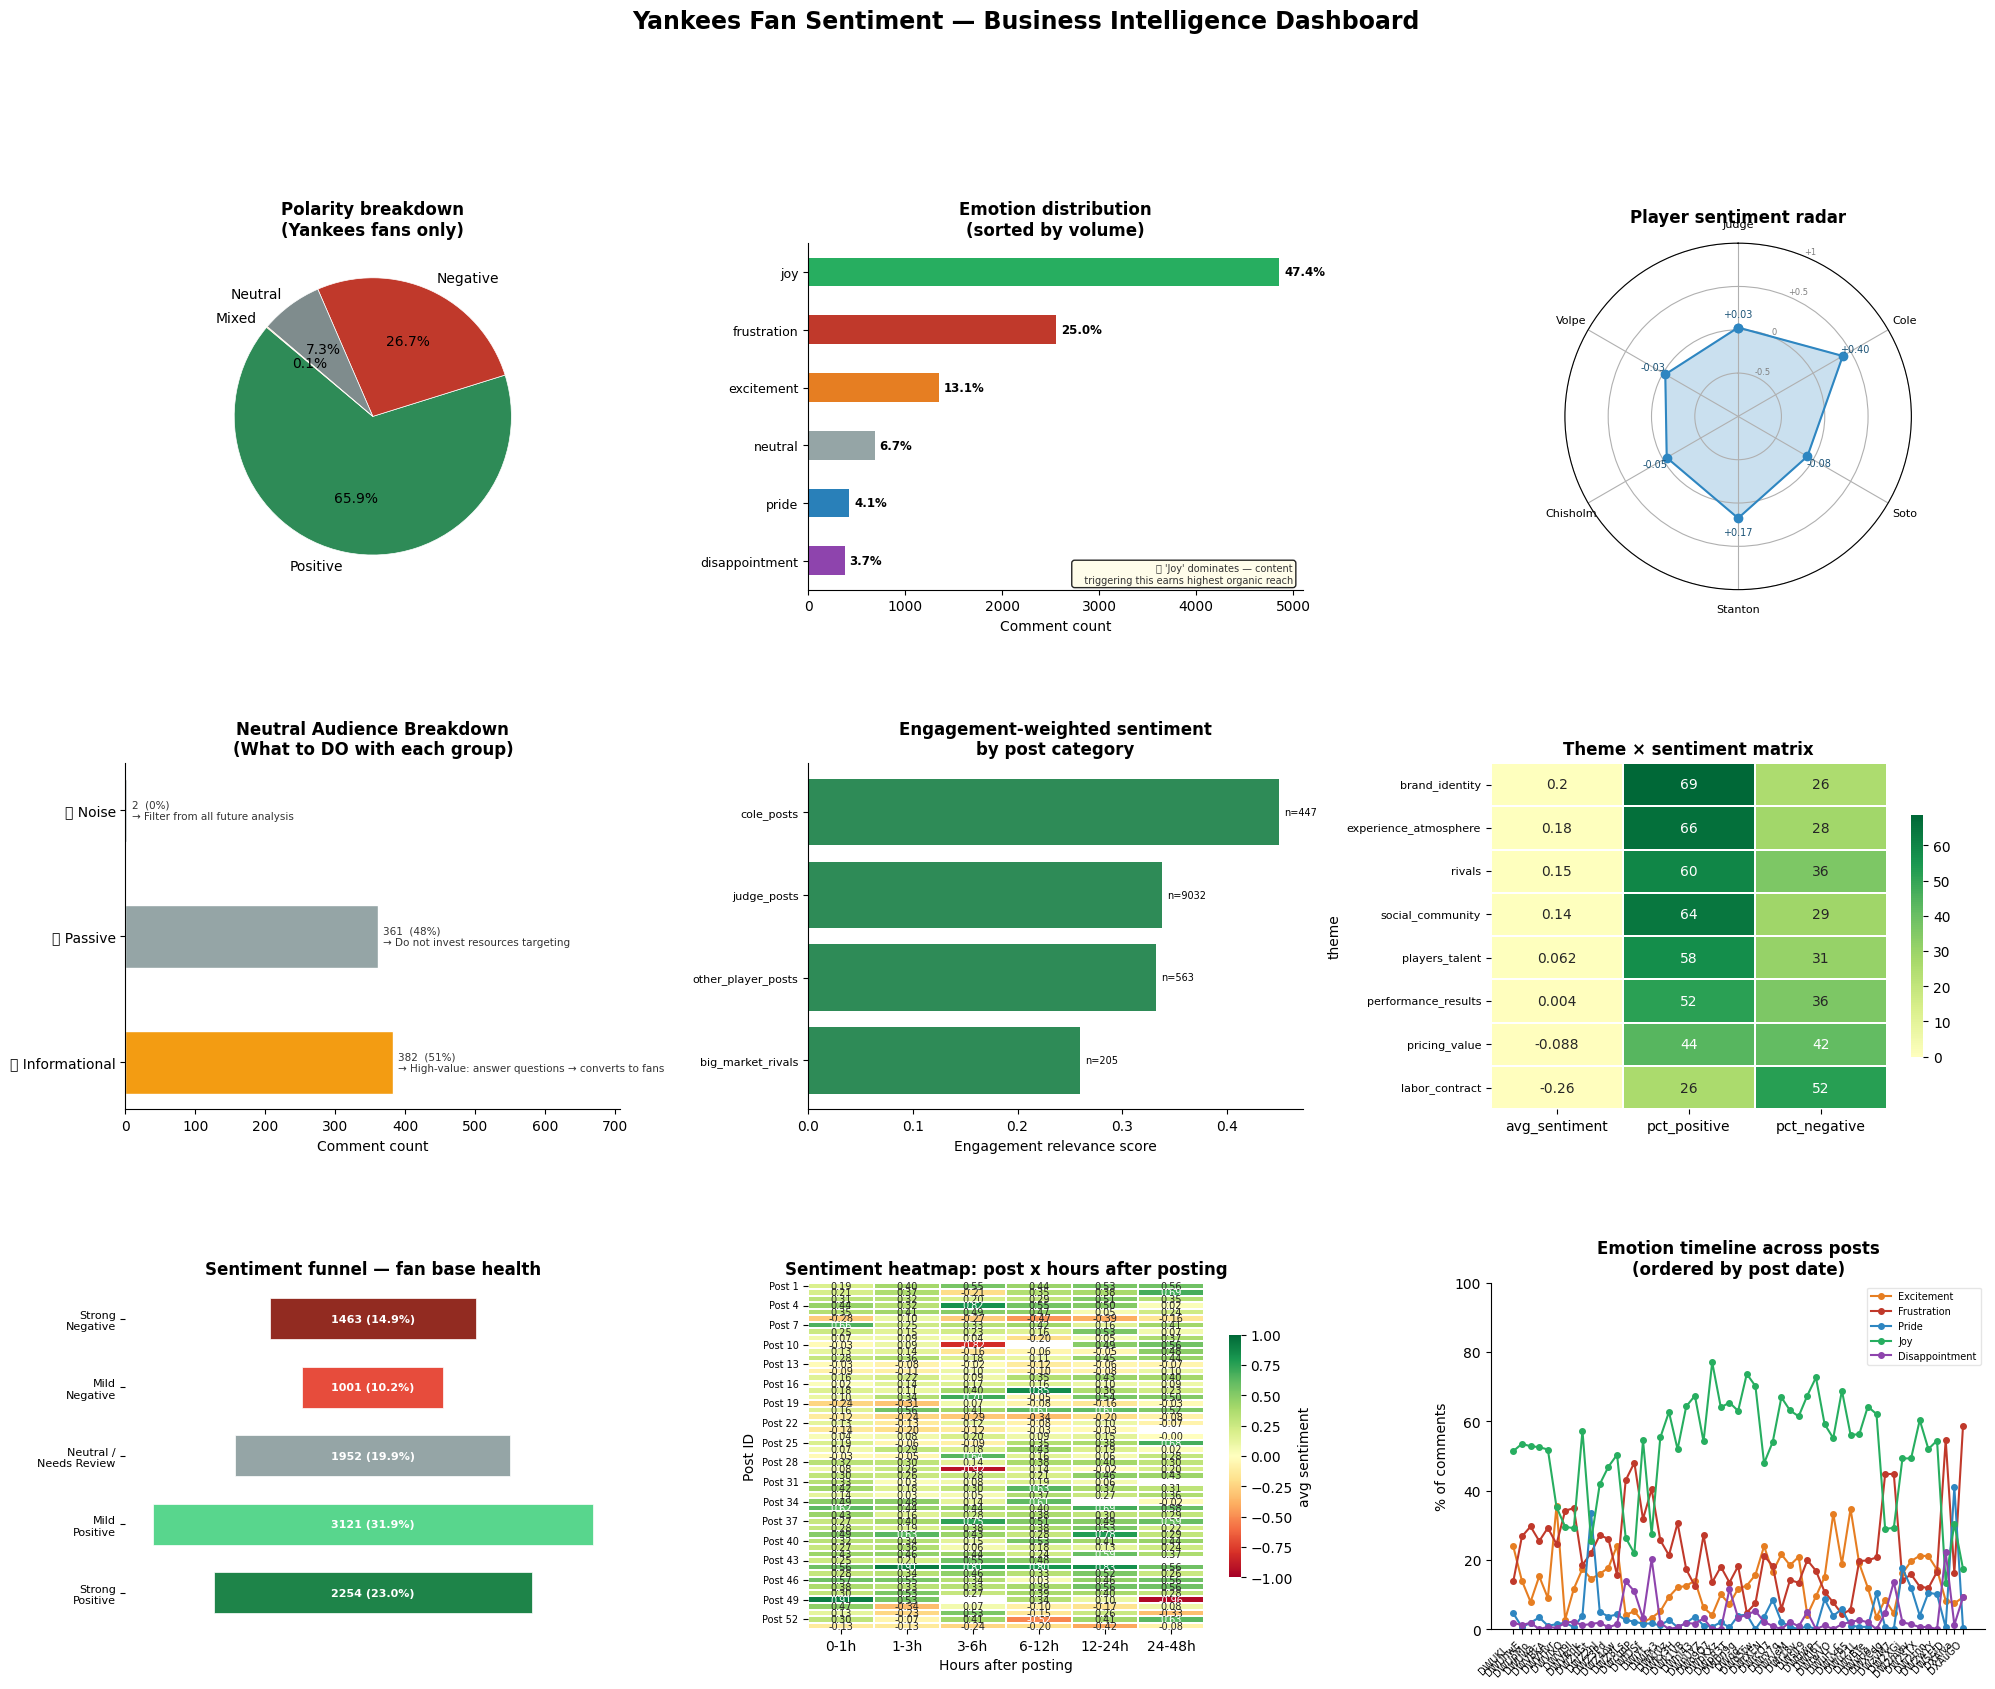

✅ Dashboard saved: sentiment_dashboard_pysentimiento.png

Building product strategy insights...


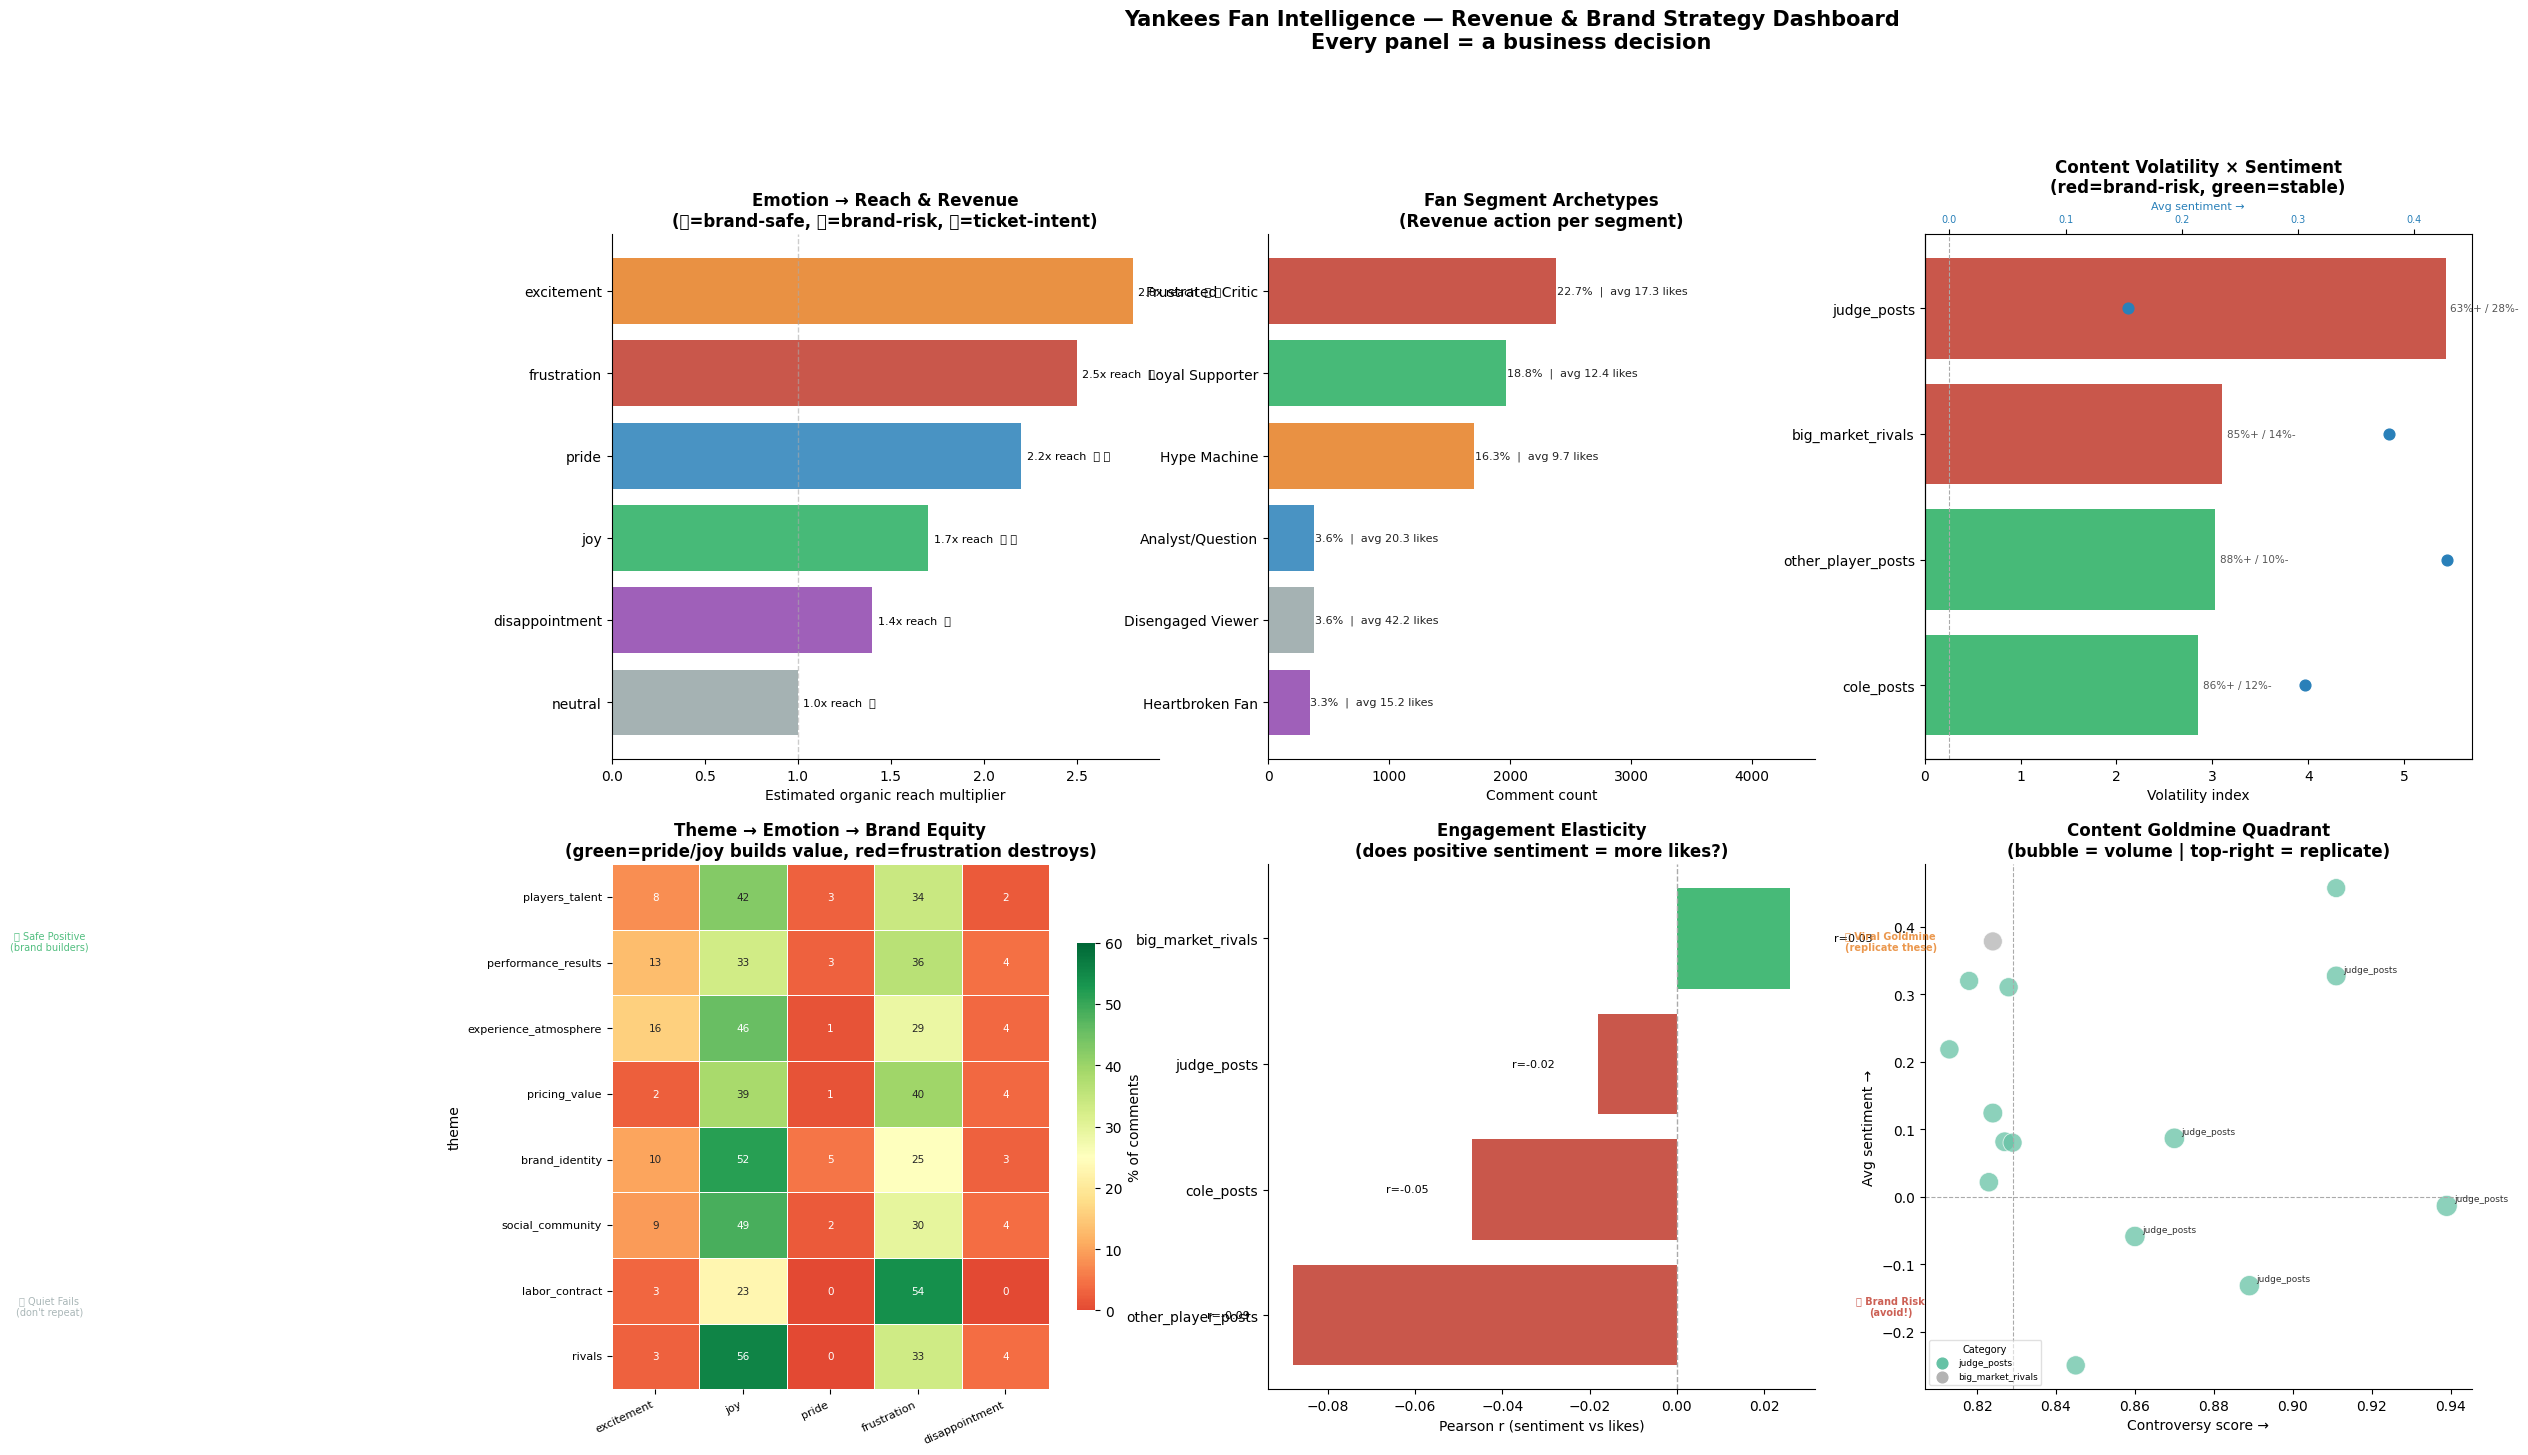

✅ Product strategy dashboard saved: product_strategy_dashboard.png

  YANKEES FAN INTELLIGENCE — EXECUTIVE ACTION REPORT
  (Revenue-linked insights unavailable via manual review)

[1] EMOTION → REACH → REVENUE
    ● 'NEUTRAL' content produces an estimated 1.0x
      organic reach vs baseline — the highest of any emotion.
      Avg likes per comment: 32.3
    ● Brand risk score: LOW 🟢
    ● Ticket purchase intent proxy: 40%
    ▶ ACTION: Engineer posts that trigger neutral (e.g. milestone
      moments, big wins, iconic plays). This maximises reach AND brand safety.

    ● 'EXCITEMENT' has lowest reach (2.8x) —
      minimise content that produces this emotional response.

[2] FAN SEGMENT REVENUE STRATEGY
    Frustrated Critic        2379 cmts (22.7%)  avg likes: 17.3
    ⚠️  Address — respond publicly to reduce brand risk
    Loyal Supporter          1965 cmts (18.8%)  avg likes: 12.4
    💎 Nurture — exclusive content / loyalty programmes
    Hype Machine             1705 cmts (16.3%) 

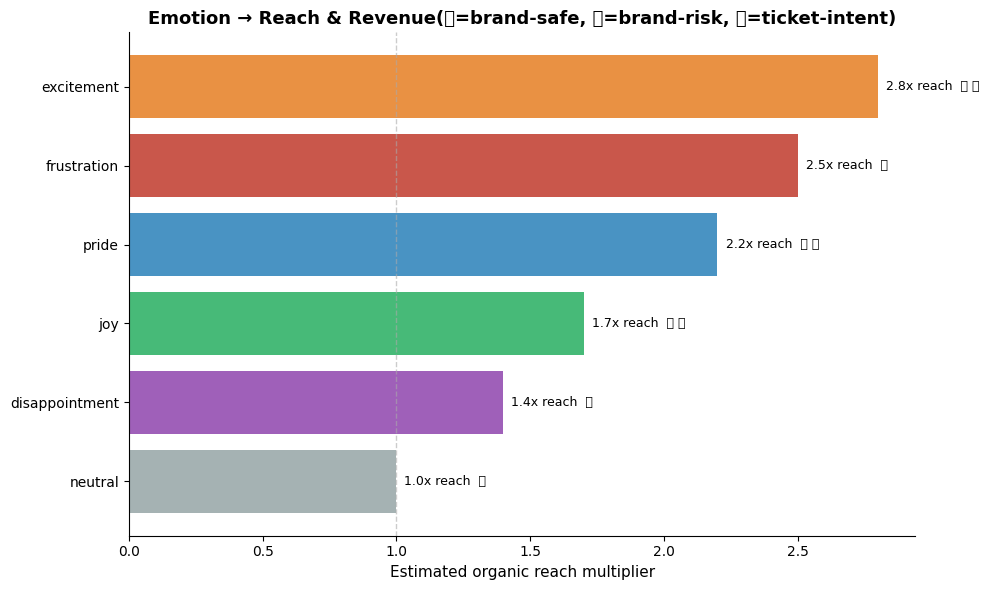

✅ Saved: panel_1_emotion_reach.png


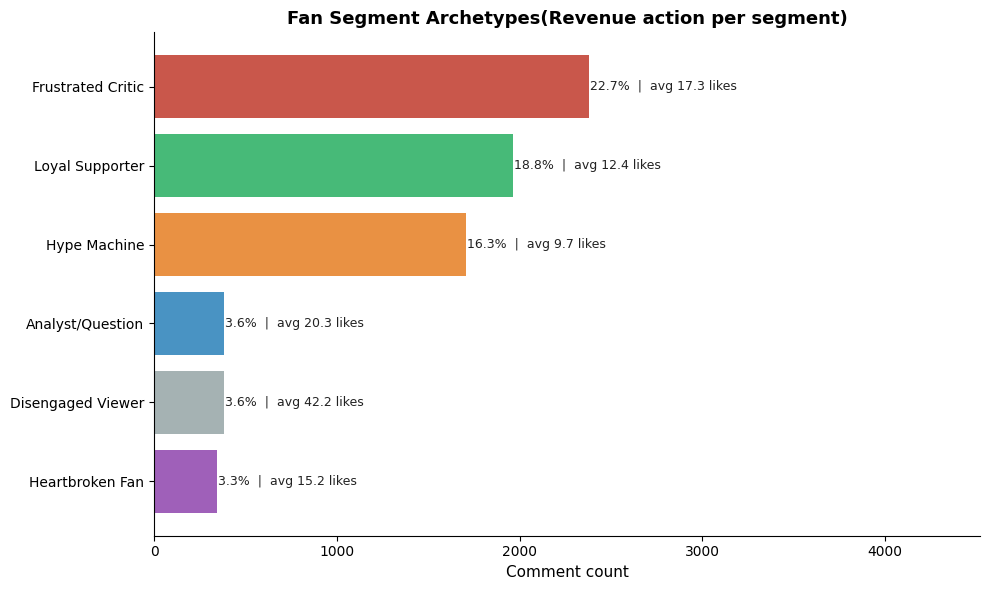

✅ Saved: panel_2_fan_segments.png


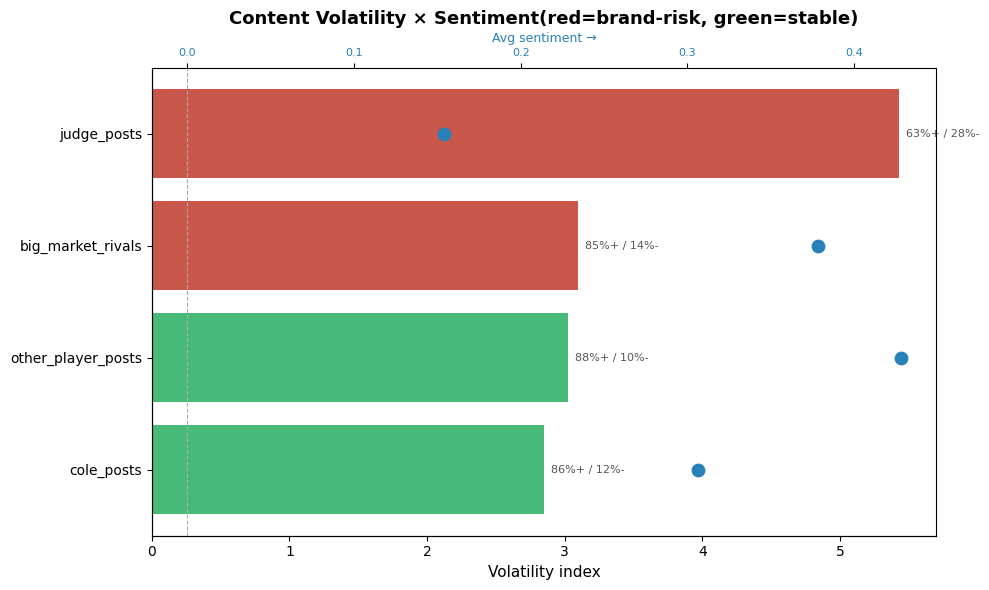

✅ Saved: panel_3_content_volatility.png


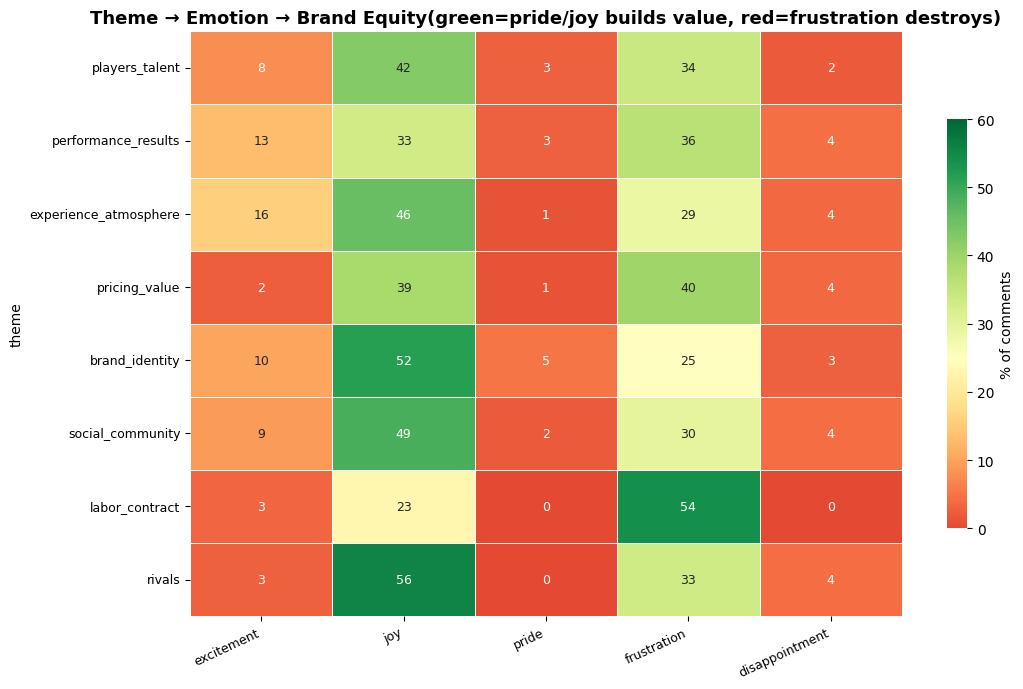

✅ Saved: panel_4_theme_emotion_heatmap.png


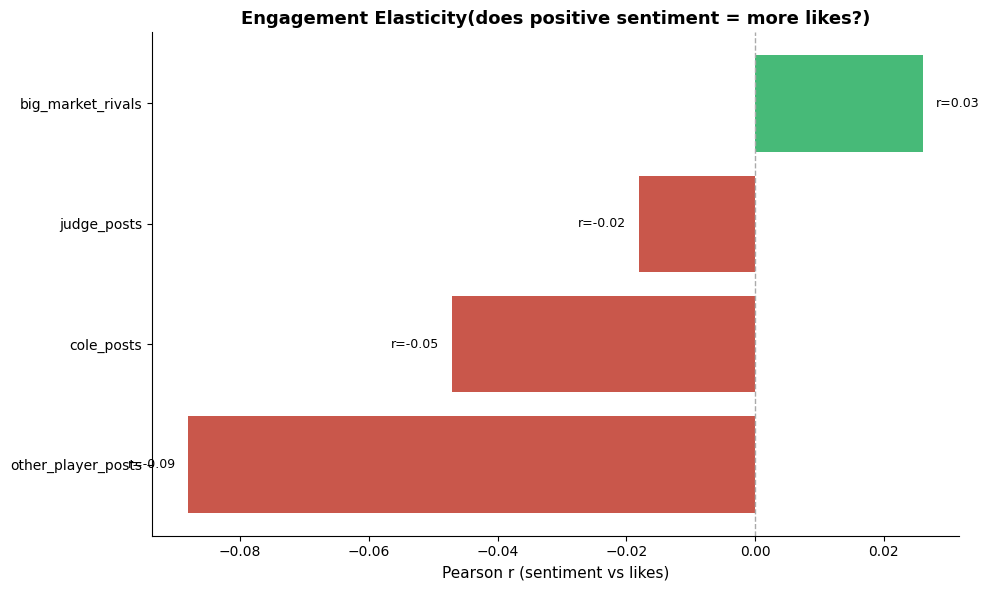

✅ Saved: panel_5_engagement_elasticity.png


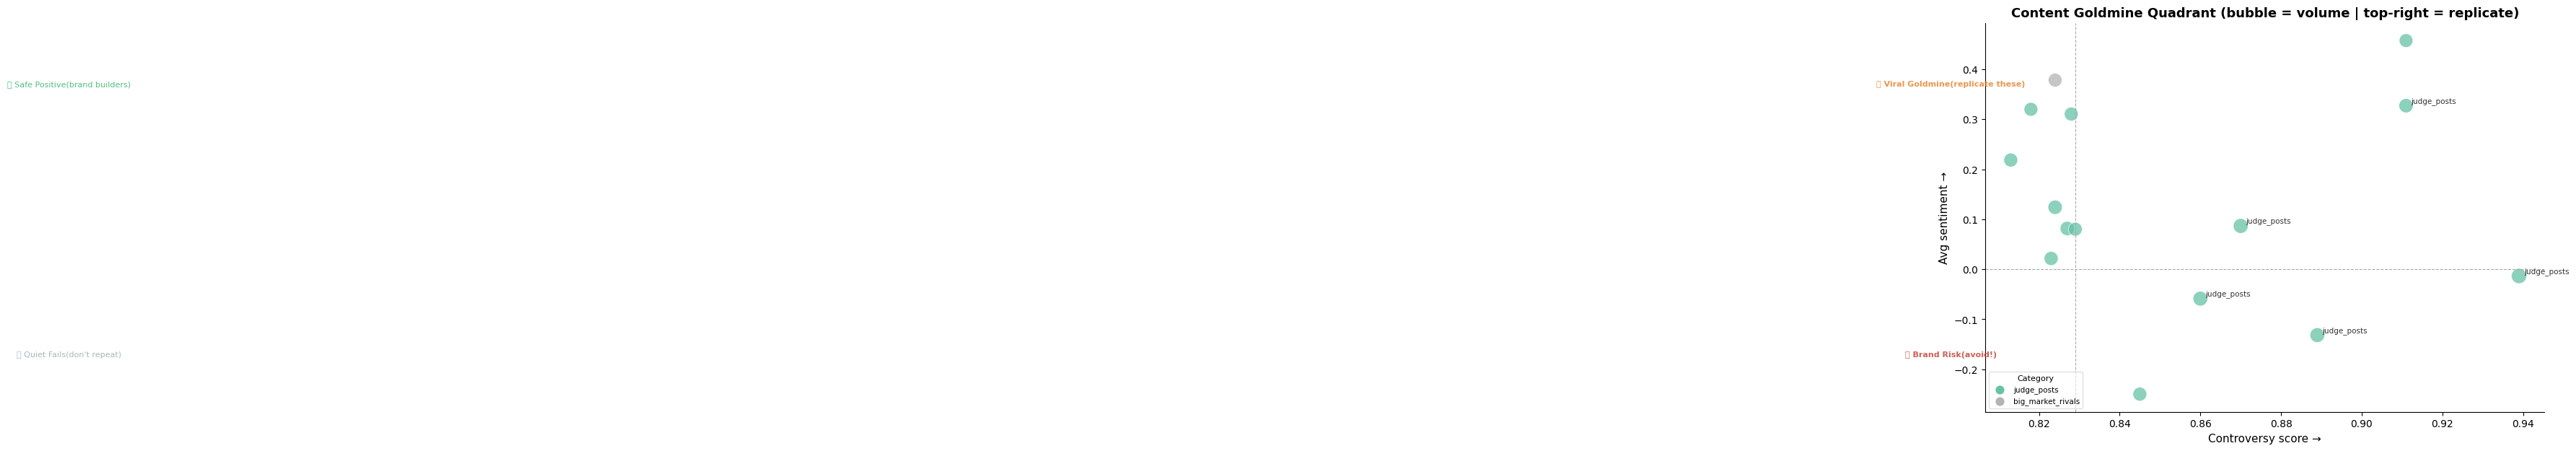

✅ Saved: panel_6_content_goldmine.png

✅ All 6 individual strategy panels saved.
   📊 panel_1_emotion_reach.png
   📊 panel_2_fan_segments.png
   📊 panel_3_content_volatility.png
   📊 panel_4_theme_emotion_heatmap.png
   📊 panel_5_engagement_elasticity.png
   📊 panel_6_content_goldmine.png

Building game-day vs non-game-day analysis...


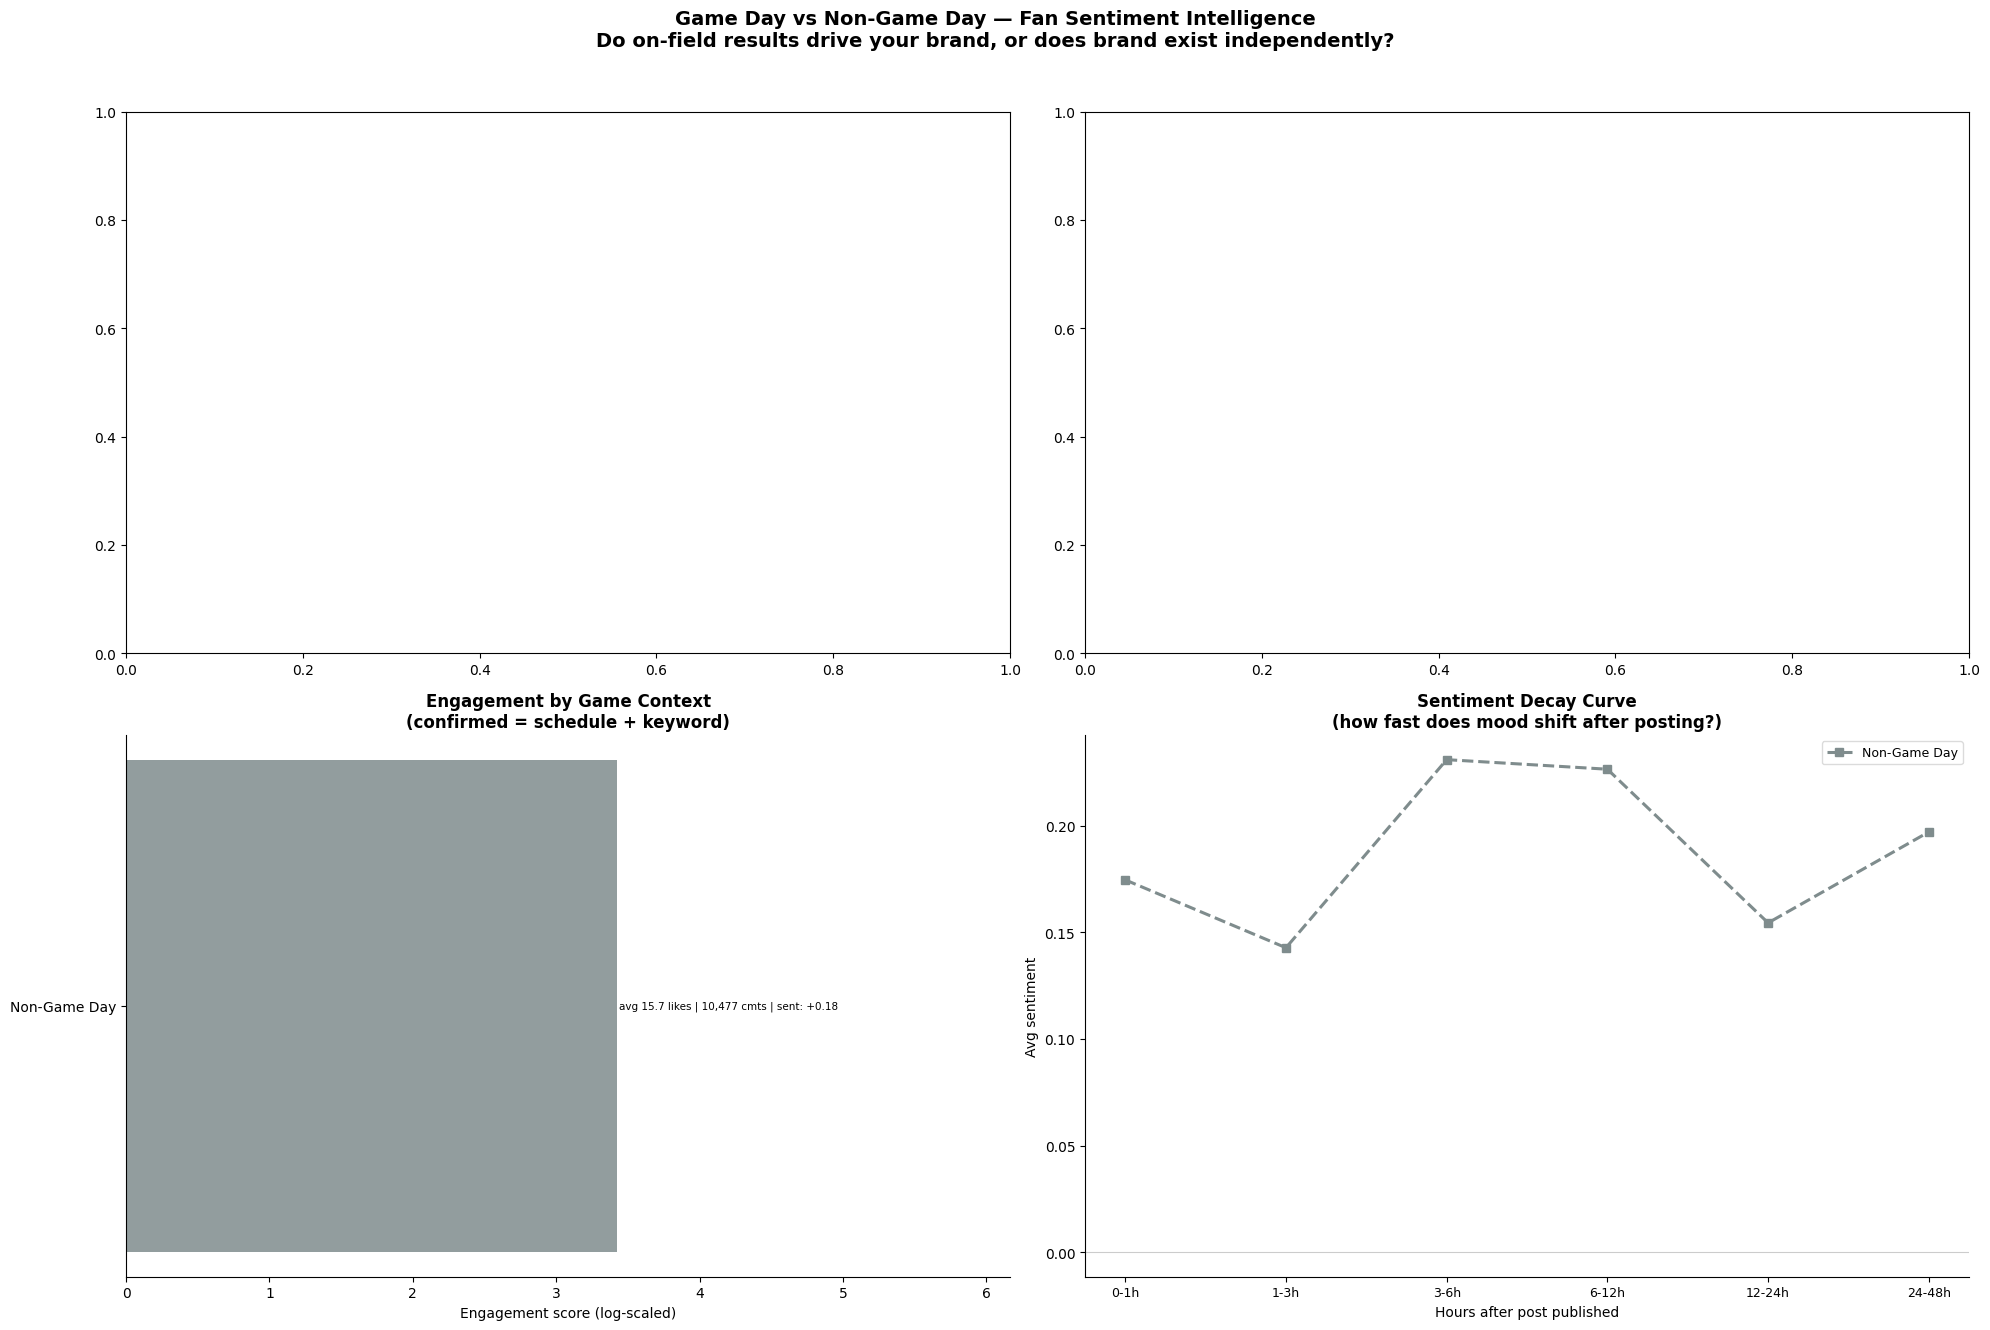

✅ Saved: chart_gameday_dashboard.png
Insufficient split data.
Full results: fan_sentiment_results_pysentimiento.csv (12167 rows)
Summaries saved.
Non-Yankees audit: non_yankee_filtered.csv (443 rows)
Boost audit: context_boost_audit.csv (2744 rows)
Summary JSON saved: fan_sentiment_summary_pysentimiento.json


In [ ]:
# MODULE 7: Context Neutral Booster (Approach A)
CONTEXT_THRESHOLD_STRONG   = 0.70
CONTEXT_THRESHOLD_MODERATE = 0.55
CONTEXT_WORD_LIMIT         = 8


class ContextNeutralBooster:
    """
    Nudges short neutral comments toward the post's dominant sentiment.

    Strong majority (≥70%)  → nudges ALL non-informational neutral subtypes.
    Moderate majority (≥55%) → nudges only ambiguous + low_engagement.
    Informational neutrals   → never nudged (factual questions, debates).
    """

    def __init__(self,
                 strong_threshold=CONTEXT_THRESHOLD_STRONG,
                 moderate_threshold=CONTEXT_THRESHOLD_MODERATE,
                 word_limit=CONTEXT_WORD_LIMIT):
        self.strong_threshold   = strong_threshold
        self.moderate_threshold = moderate_threshold
        self.word_limit         = word_limit

    def _compute_post_majority(self, df: pd.DataFrame) -> dict:
        result      = {}
        non_neutral = df[df["polarity"] != "Neutral"]
        for post_id, group in non_neutral.groupby("post_id"):
            n       = len(group)
            pos_pct = (group["polarity"] == "Positive").sum() / n
            neg_pct = (group["polarity"] == "Negative").sum() / n
            if pos_pct >= self.strong_threshold:
                result[post_id] = ("Positive", pos_pct, "strong")
            elif neg_pct >= self.strong_threshold:
                result[post_id] = ("Negative", neg_pct, "strong")
            elif pos_pct >= self.moderate_threshold:
                result[post_id] = ("Positive", pos_pct, "moderate")
            elif neg_pct >= self.moderate_threshold:
                result[post_id] = ("Negative", neg_pct, "moderate")
            else:
                result[post_id] = (None, 0, None)
        return result

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out["context_boosted"]    = False
        out["context_boost_from"] = None
        post_majority = self._compute_post_majority(out)

        nudged = 0
        for idx, row in out[out["polarity"] == "Neutral"].iterrows():
            post_id = row.get("post_id")
            majority, conf, strength = post_majority.get(post_id, (None, 0, None))
            if majority is None:
                continue

            subtype = row.get("neutral_subtype", "ambiguous_neutral")

            # Informational neutrals are genuinely neutral — never nudge
            if subtype == "informational_neutral":
                continue

            # Eligibility check
            eligible = (
                strength == "strong" or
                (strength == "moderate" and
                 subtype in ("ambiguous_neutral", "low_engagement_neutral"))
            )
            if not eligible:
                continue

            # Don't nudge long comments without strong majority signal
            if (row.get("word_count", 99) > self.word_limit
                    and strength != "strong"):
                continue

            # Apply nudge
            out.at[idx, "polarity"]           = majority
            out.at[idx, "context_boosted"]    = True
            out.at[idx, "context_boost_from"] = (
                f"{majority}_{strength} ({conf:.0%})")

            if majority == "Positive":
                out.at[idx, "sentiment_score"] = max(
                    float(row["sentiment_score"]), 0.18)
                if row.get("emotion_top") == "neutral":
                    emo = ("excitement"
                           if row.get("intensity_level") in ["moderate", "strong"]
                           else "joy")
                    out.at[idx, "emotion_top"]        = emo
                    out.at[idx, "emotion_confidence"] = max(
                        float(row.get("emotion_confidence", 0)), 0.52)
            else:
                out.at[idx, "sentiment_score"] = min(
                    float(row["sentiment_score"]), -0.18)
                if row.get("emotion_top") == "neutral":
                    emo = ("frustration"
                           if row.get("intensity_level") in ["moderate", "strong"]
                           else "disappointment")
                    out.at[idx, "emotion_top"]        = emo
                    out.at[idx, "emotion_confidence"] = max(
                        float(row.get("emotion_confidence", 0)), 0.52)
            nudged += 1

        print(f"ContextNeutralBooster: nudged {nudged} neutral → classified.")
        return out


context_booster = ContextNeutralBooster()
df = context_booster.transform(df)

df[["raw_text", "polarity", "neutral_subtype", "sentiment_score",
    "emotion_top", "context_boosted", "context_boost_from",
    "is_non_yankee"]].head(12)


# MODULE 8: Theme Extractor
THEME_DICT = {
    "players_talent": [
        r"\b(player|pitcher|batter|catcher|fielder|hitter|roster|prospect|rookie|farm|callup|call(ed)? up|draft)\b",
        r"\b(judge|cole|soto|stanton|chisholm|volpe|rodon|cortes|trevino|rice|gil)\b",
    ],
    "performance_results": [
        r"\b(win|won|loss|lost|game|score|hit|run|pitch|catch|throw|strike|homer|home run|rbi|era|stats|record)\b",
        r"\b(clutch|dominant|struggling|amazing play|big hit|walk.?off|grand slam)\b",
    ],
    "experience_atmosphere": [
        r"\b(stadium|ballpark|crowd|fan|atmosphere|cheer|loud|seats|view|vibe|section|bleacher|concession)\b",
        r"\b(live game|in person|watch|broadcast|tv|stream|app|yankee stadium)\b",
    ],
    "pricing_value": [
        r"\b(ticket|price|cost|expensive|cheap|afford|deal|worth|value|money|pay|bought|sale|luxury tax)\b",
    ],
    "brand_identity": [
        r"\b(team|brand|logo|jersey|merch|uniform|represent|community|organization|yankees|pinstripes|bronx)\b",
    ],
    "social_community": [
        r"\b(together|family|community|support|love this|we|our|us|everyone|whole|fan base|fanbase)\b",
    ],
    "labor_contract": [
        r"\b(cba|lockout|strike|salary cap|luxury tax|payroll|collective bargaining|2027)\b",
    ],
    "rivals": [
        r"\b(red sox|orioles|rays|blue jays|dodgers|mets|subway series|al east)\b",
    ],
}


class ThemeExtractor:
    def __init__(self, theme_dict=THEME_DICT):
        self.theme_dict = {
            t: [re.compile(p, re.IGNORECASE | re.UNICODE) for p in patterns]
            for t, patterns in theme_dict.items()
        }

    def tag_themes(self, text):
        if not isinstance(text, str) or not text.strip():
            return ["untagged"]
        themes = [t for t, pats in self.theme_dict.items()
                  if any(p.search(text) for p in pats)]
        return themes or ["untagged"]

    def run_tfidf_discovery(self, texts, top_n=20):
        clean = texts.fillna("").tolist()
        vec   = TfidfVectorizer(max_features=200, stop_words="english",
                                ngram_range=(1, 2), min_df=2)
        X      = vec.fit_transform(clean)
        scores = X.toarray().mean(axis=0)
        words  = vec.get_feature_names_out()
        return (pd.DataFrame({"keyword": words, "tfidf_score": scores})
                  .sort_values("tfidf_score", ascending=False)
                  .head(top_n).reset_index(drop=True))

    def transform(self, df):
        out = df.copy()
        out["themes"]      = out["raw_text"].apply(self.tag_themes)
        out["theme_count"] = out["themes"].apply(len)
        for t in list(self.theme_dict.keys()) + ["untagged"]:
            out[f"theme_{t}"] = out["themes"].apply(lambda x: int(t in x))
        print(f"✅ Theme extraction complete.")
        return out


theme_extractor = ThemeExtractor()
df = theme_extractor.transform(df)

print("\nTop TF-IDF keywords:")
print(theme_extractor.run_tfidf_discovery(df["cleaned_text"]).head(15).to_string(index=False))



# MODULE 9: Output Formatter
class OutputFormatter:
    """
    Assembles final output and business summaries.
    get_impactful() filters: noise + low_engagement_neutral + non_yankee
    """

    EXCLUDE_LOW_ENGAGEMENT_NEUTRAL = True

    OUTPUT_COLS = [
        "comment_id", "raw_text", "cleaned_text",
        "author_username", "timestamp", "post_url", "post_id",
        "platform", "post_category", "is_reply",
        "likes", "replies_count",
        "language", "comment_type", "is_noise", "is_null_text",
        "is_non_yankee",
        "emoji_count", "emoji_sentiment_score",
        "word_count", "char_length", "exclamation_count",
        "question_count", "caps_word_count", "has_mention",
        "intensity_level",
        "polarity", "sentiment_score",
        "roberta_label", "roberta_confidence", "roberta_compound",
        "fan_lexicon_score", "sarcasm_flag",
        "neutral_subtype",
        "context_boosted", "context_boost_from",
        "emotion_top", "emotion_confidence",
        "themes", "theme_count",
    ]

    def build_output(self, df):
        available = [c for c in self.OUTPUT_COLS if c in df.columns]
        return df[available].copy()

    def get_impactful(self, df):
        mask = ~df["is_null_text"] & ~df["is_noise"]
        if self.EXCLUDE_LOW_ENGAGEMENT_NEUTRAL and "neutral_subtype" in df.columns:
            mask = mask & (df["neutral_subtype"] != "low_engagement_neutral")
        if "is_non_yankee" in df.columns:
            mask = mask & ~df["is_non_yankee"].fillna(False)
        filtered       = df[mask]
        n_excluded     = len(df) - len(filtered)
        n_non_yankee   = int(df["is_non_yankee"].fillna(False).sum()) if "is_non_yankee" in df.columns else 0
        print(f"   Impact filter: {len(filtered)} impactful comments "
              f"({n_excluded} excluded, incl. {n_non_yankee} non-Yankees)")
        return filtered

    def sentiment_summary(self, df):
        valid    = self.get_impactful(df)
        pol_pct  = (valid["polarity"].value_counts(normalize=True) * 100).round(1)
        emo_dist = valid["emotion_top"].value_counts()
        int_dist = valid["intensity_level"].value_counts()
        neu_sub  = (valid.loc[valid["polarity"] == "Neutral", "neutral_subtype"]
                        .value_counts().to_dict()
                    if "neutral_subtype" in valid.columns else {})
        return {
            "total_impactful_comments": len(valid),
            "total_raw_comments":       len(df),
            "excluded_total":           len(df) - len(valid),
            "excluded_non_yankee":      int(df["is_non_yankee"].fillna(False).sum()),
            "polarity_breakdown_%":     pol_pct.to_dict(),
            "neutral_subtype_breakdown": neu_sub,
            "avg_sentiment_score":      round(valid["sentiment_score"].mean(), 3),
            "emotion_distribution":     emo_dist.to_dict(),
            "intensity_distribution":   int_dist.to_dict(),
            "sarcasm_detected":         int(valid["sarcasm_flag"].sum()),
            "context_boosted":          int(df["context_boosted"].sum()),
            "posts_covered":            int(df["post_url"].nunique()),
            "platform":                 df["platform"].iloc[0] if "platform" in df.columns else "unknown",
        }

    def post_category_summary(self, df):
        valid = self.get_impactful(df)
        rows  = []
        for cat in valid["post_category"].unique():
            s = valid[valid["post_category"] == cat]
            rows.append({
                "post_category": cat,
                "comment_count": len(s),
                "avg_sentiment": round(s["sentiment_score"].mean(), 3),
                "pct_positive":  round((s["polarity"] == "Positive").mean() * 100, 1),
                "pct_negative":  round((s["polarity"] == "Negative").mean() * 100, 1),
                "pct_neutral":   round((s["polarity"] == "Neutral").mean() * 100, 1),
                "top_emotion":   s["emotion_top"].mode()[0] if len(s) > 0 else "—",
                "sarcasm_count": int(s["sarcasm_flag"].sum()),
            })
        return (pd.DataFrame(rows)
                  .sort_values("avg_sentiment", ascending=False)
                  .reset_index(drop=True))

    def platform_summary(self, df):
        valid = self.get_impactful(df)
        rows  = []
        for plat in valid["platform"].unique():
            s = valid[valid["platform"] == plat]
            rows.append({
                "platform":      plat,
                "comment_count": len(s),
                "avg_sentiment": round(s["sentiment_score"].mean(), 3),
                "pct_positive":  round((s["polarity"] == "Positive").mean() * 100, 1),
                "pct_negative":  round((s["polarity"] == "Negative").mean() * 100, 1),
                "top_emotion":   s["emotion_top"].mode()[0] if len(s) > 0 else "—",
            })
        return pd.DataFrame(rows)

    def theme_sentiment_matrix(self, df):
        valid = self.get_impactful(df)
        theme_cols = [c for c in valid.columns if c.startswith("theme_")
                      and c not in ("theme_count", "theme_untagged")]
        rows = []
        for tc in theme_cols:
            name = tc.replace("theme_", "")
            s    = valid[valid[tc] == 1]
            if len(s) == 0:
                continue
            rows.append({
                "theme":         name,
                "comment_count": len(s),
                "avg_sentiment": round(s["sentiment_score"].mean(), 3),
                "pct_positive":  round((s["polarity"] == "Positive").mean() * 100, 1),
                "pct_negative":  round((s["polarity"] == "Negative").mean() * 100, 1),
                "top_emotion":   s["emotion_top"].mode()[0] if s["emotion_top"].notna().any() else "—",
            })
        return pd.DataFrame(rows).sort_values("avg_sentiment", ascending=False)

    def example_comments(self, df, n=3):
        valid = self.get_impactful(df)
        by_pol = {}
        for pol in ["Positive", "Negative", "Neutral", "Mixed"]:
            s = valid[valid["polarity"] == pol].sort_values("likes", ascending=False)
            by_pol[pol] = s["raw_text"].dropna().head(n).tolist()
        by_cat = {}
        for cat in valid["post_category"].unique():
            s = valid[valid["post_category"] == cat].sort_values("likes", ascending=False)
            by_cat[cat] = s["raw_text"].dropna().head(n).tolist()
        return {"by_polarity": by_pol, "by_category": by_cat}

    def key_insights(self, df, theme_matrix, post_cat_summary):
        insights = []
        summary  = self.sentiment_summary(df)
        top_pol  = max(summary["polarity_breakdown_%"],
                       key=summary["polarity_breakdown_%"].get)
        insights.append(
            f"Overall tone is {top_pol.lower()} "
            f"({summary['polarity_breakdown_%'][top_pol]:.1f}% of impactful comments).")
        insights.append(
            f"{summary['excluded_non_yankee']} non-Yankees comments excluded "
            f"from analysis (rival team fans).")
        if len(theme_matrix) > 0:
            best  = theme_matrix.iloc[0]
            worst = theme_matrix.iloc[-1]
            insights.append(
                f"Fans most positive about '{best['theme'].replace('_',' ')}' "
                f"(avg sentiment: {best['avg_sentiment']:.2f}).")
            if worst["avg_sentiment"] < 0:
                insights.append(
                    f"Most negative theme: '{worst['theme'].replace('_',' ')}' "
                    f"(avg: {worst['avg_sentiment']:.2f}).")
        if len(post_cat_summary) > 0:
            bc = post_cat_summary.iloc[0]
            insights.append(
                f"Highest-sentiment post category: '{bc['post_category']}' "
                f"(avg: {bc['avg_sentiment']:.2f}, {bc['pct_positive']:.0f}% positive).")
        if summary.get("emotion_distribution"):
            top_emo = max(summary["emotion_distribution"],
                          key=summary["emotion_distribution"].get)
            insights.append(
                f"Dominant emotion: {top_emo} "
                f"({summary['emotion_distribution'][top_emo]} comments).")
        if summary["sarcasm_detected"] > 0:
            insights.append(
                f"{summary['sarcasm_detected']} potentially sarcastic comments — review manually.")
        if summary["context_boosted"] > 0:
            insights.append(
                f"{summary['context_boosted']} neutral comments context-boosted "
                f"using post majority signal.")
        return insights


formatter        = OutputFormatter()
df_out           = formatter.build_output(df)
summary          = formatter.sentiment_summary(df)
theme_matrix     = formatter.theme_sentiment_matrix(df)
post_cat_summary = formatter.post_category_summary(df)
platform_summary = formatter.platform_summary(df)
plat_cat_summary = formatter.platform_category_summary(df) if hasattr(formatter, 'platform_category_summary') else None
examples         = formatter.example_comments(df)
insights         = formatter.key_insights(df, theme_matrix, post_cat_summary)

print("\n" + "="*60)
print("SENTIMENT SUMMARY")
print("="*60)
for k, v in summary.items():
    print(f"  {k}: {v}")

print("\nPOST CATEGORY SUMMARY:")
print(post_cat_summary[["post_category", "comment_count", "avg_sentiment",
                          "pct_positive", "pct_negative", "top_emotion"]].to_string(index=False))
print("\nTHEME × SENTIMENT MATRIX:")
print(theme_matrix.to_string(index=False))
print("\nKEY INSIGHTS:")
for i, ins in enumerate(insights, 1):
    print(f"  {i}. {ins}")
print("\nEXAMPLE COMMENTS — POSITIVE:")
for c in examples["by_polarity"].get("Positive", []):
    print(f"  • {c}")
print("\nEXAMPLE COMMENTS — NEGATIVE:")
for c in examples["by_polarity"].get("Negative", []):
    print(f"  • {c}")


# MODULE 10: Business-Impact Visualizations
def _get_impactful(df: pd.DataFrame) -> pd.DataFrame:
    mask = ~df["is_null_text"] & ~df["is_noise"]
    if "neutral_subtype" in df.columns:
        mask = mask & (df["neutral_subtype"] != "low_engagement_neutral")
    if "is_non_yankee" in df.columns:
        mask = mask & ~df["is_non_yankee"].fillna(False)
    return df[mask]


def plot_sentiment_funnel(df, ax):
    valid  = _get_impactful(df)
    bins   = [(-1.01, -0.5), (-0.5, -0.15), (-0.15, 0.15), (0.15, 0.5), (0.5, 1.01)]
    labels = ["Strong\nNegative", "Mild\nNegative", "Neutral /\nNeeds Review",
              "Mild\nPositive", "Strong\nPositive"]
    colors = ["#922B21", "#E74C3C", "#95A5A6", "#58D68D", "#1E8449"]
    counts = [((valid["sentiment_score"] > lo) & (valid["sentiment_score"] <= hi)).sum()
              for lo, hi in bins]
    total     = sum(counts) or 1
    max_count = max(counts) or 1
    for i, (count, label, color) in enumerate(zip(counts, labels, colors)):
        width = (count / max_count) * 0.8
        ax.barh(i, width, left=(0.9 - width) / 2, color=color,
                edgecolor="white", linewidth=0.5, height=0.6)
        pct = count / total * 100
        ax.text(0.45, i, f"{count} ({pct:.1f}%)", ha="center", va="center",
                fontsize=8, color="white" if count > 5 else "black", fontweight="bold")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlim(0, 0.9)
    ax.set_xticks([])
    ax.set_title("Sentiment funnel — fan base health", fontweight="bold")
    ax.invert_yaxis()
    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)


def plot_engagement_weighted_sentiment(df, post_cat_summary, ax):
    valid = _get_impactful(df).copy()
    rows  = []
    for cat in valid["post_category"].unique():
        s = valid[valid["post_category"] == cat].copy()
        if len(s) == 0:
            continue
        s["eng"] = np.log1p(s["likes"].fillna(0) + 3 * s["replies_count"].fillna(0))
        rows.append({
            "post_category":        cat,
            "engagement_relevance": round((s["eng"] * s["sentiment_score"].abs()).mean(), 3),
            "eng_weighted_sent":    round(
                (s["eng"] * s["sentiment_score"]).sum() / max(s["eng"].sum(), 1e-6), 3),
            "comment_count":        len(s),
        })
    ew = pd.DataFrame(rows)
    if ew.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        return
    ew = ew.sort_values("engagement_relevance", ascending=True)
    colors = ["#C0392B" if v < 0 else "#2E8B57" for v in ew["eng_weighted_sent"]]
    bars = ax.barh(range(len(ew)), ew["engagement_relevance"].values,
                   color=colors, edgecolor="none")
    ax.set_yticks(range(len(ew)))
    ax.set_yticklabels(ew["post_category"].tolist(), fontsize=8)
    for i, (_, row) in enumerate(ew.iterrows()):
        ax.text(row["engagement_relevance"] + 0.005, i,
                f"n={row['comment_count']}",
                va="center", ha="left", fontsize=7)
    ax.set_title("Engagement-weighted sentiment\nby post category", fontweight="bold")
    ax.set_xlabel("Engagement relevance score")
    ax.spines[["top", "right"]].set_visible(False)


def plot_player_radar(df, ax):
    PLAYERS = {
        "Judge": r"\bjudge\b", "Cole": r"\bcole\b", "Soto": r"\bsoto\b",
        "Stanton": r"\bstanton\b", "Chisholm": r"\bchisholm\b", "Volpe": r"\bvolpe\b",
    }
    valid  = _get_impactful(df)
    scores = {}
    for player, pat in PLAYERS.items():
        mask   = valid["raw_text"].fillna("").str.contains(pat, case=False, regex=True)
        subset = valid[mask]
        if len(subset) >= 3:
            scores[player] = round(subset["sentiment_score"].mean(), 3)
    if len(scores) < 3:
        ax.text(0.5, 0.5, "Not enough player mentions\n(need ≥3 per player)",
                ha="center", va="center", fontsize=9, transform=ax.transAxes)
        ax.set_title("Player sentiment radar", fontweight="bold")
        ax.axis("off")
        return
    players   = list(scores.keys())
    vals      = list(scores.values())
    N         = len(players)
    norm_vals = [(v + 1) / 2 for v in vals] + [(vals[0] + 1) / 2]
    angles    = [n / N * 2 * np.pi for n in range(N)] + [0]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(players, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["-0.5", "0", "+0.5", "+1"], fontsize=6, color="gray")
    ax.plot(angles, norm_vals, "o-", linewidth=1.5, color="#2E86C1")
    ax.fill(angles, norm_vals, alpha=0.25, color="#2E86C1")
    for angle, val, norm in zip(angles[:-1], vals, norm_vals[:-1]):
        ax.text(angle, norm + 0.08, f"{val:+.2f}",
                ha="center", va="center", fontsize=7, color="#1A5276")
    ax.set_title("Player sentiment radar", fontweight="bold", pad=15)


def plot_post_time_heatmap(df, ax):
    valid = _get_impactful(df).dropna(subset=["timestamp", "post_id"]).copy()
    post_first = valid.groupby("post_id")["timestamp"].min().rename("post_start")
    valid = valid.join(post_first, on="post_id")
    valid["hours_after"] = (
        (valid["timestamp"] - valid["post_start"]).dt.total_seconds() / 3600
    ).clip(0, 47)
    valid["hour_bucket"] = pd.cut(
        valid["hours_after"],
        bins=[0, 1, 3, 6, 12, 24, 48],
        labels=["0-1h", "1-3h", "3-6h", "6-12h", "12-24h", "24-48h"],
        include_lowest=True)
    pivot = (valid.groupby(["post_id", "hour_bucket"], observed=True)["sentiment_score"]
                  .mean().unstack(fill_value=np.nan))
    if pivot.empty or pivot.shape[0] < 2:
        ax.text(0.5, 0.5, "Need >=2 posts for heatmap",
                ha="center", va="center", fontsize=9, transform=ax.transAxes)
        ax.set_title("Sentiment heatmap: post x time", fontweight="bold")
        return
    # Sort posts by first-comment timestamp so Post 1 = earliest
    post_order_map = {pid: f"Post {i+1}" for i, pid in enumerate(pivot.index)}
    pivot.index = [post_order_map.get(pid, str(pid)[:8]) for pid in pivot.index]
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn", center=0, vmin=-1, vmax=1,
                linewidths=0.3, annot=True, fmt=".2f", annot_kws={"size": 7},
                cbar_kws={"shrink": 0.7, "label": "avg sentiment"})
    ax.set_title("Sentiment heatmap: post x hours after posting", fontweight="bold")
    ax.set_xlabel("Hours after posting")
    ax.set_ylabel("Post ID")
    ax.tick_params(axis="y", labelsize=7, rotation=0)


def plot_emotion_timeline(df, ax):
    valid = _get_impactful(df).dropna(subset=["post_id"]).copy()
    TRACK  = ["excitement", "frustration", "pride", "joy", "disappointment"]
    COLORS = {"excitement": "#E67E22", "frustration": "#C0392B",
              "pride": "#2E86C1", "joy": "#27AE60", "disappointment": "#8E44AD"}
    post_order = (valid.groupby("post_id")["timestamp"].min()
                       .sort_values().index.tolist())
    rows = []
    for pid in post_order:
        s = valid[valid["post_id"] == pid]
        n = len(s)
        if n == 0:
            continue
        row = {"post_id": str(pid)[:6]}
        emo_counts = s["emotion_top"].value_counts()
        for emo in TRACK:
            row[emo] = emo_counts.get(emo, 0) / n * 100
        rows.append(row)
    if len(rows) < 2:
        ax.text(0.5, 0.5, "Need >=2 posts for timeline",
                ha="center", va="center", fontsize=9, transform=ax.transAxes)
        ax.set_title("Emotion timeline across posts", fontweight="bold")
        return
    tl = pd.DataFrame(rows).set_index("post_id")
    x  = range(len(tl))
    for emo in TRACK:
        ax.plot(list(x), tl[emo].tolist(), marker="o", markersize=4,
                linewidth=1.5, color=COLORS[emo], label=emo.capitalize())
    ax.set_xticks(list(x))
    ax.set_xticklabels(tl.index.tolist(), rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("% of comments")
    ax.set_ylim(0, 100)
    ax.set_title("Emotion timeline across posts\n(ordered by post date)", fontweight="bold")
    ax.legend(fontsize=7, loc="upper right", framealpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)



def plot_all(df, theme_matrix, summary, post_cat_summary):
    """Main 9-panel Business Intelligence Dashboard."""
    palette = {"Positive": "#2E8B57", "Negative": "#C0392B",
               "Neutral": "#7F8C8D", "Mixed": "#E67E22"}

    fig = plt.figure(figsize=(24, 18))
    fig.suptitle("Yankees Fan Sentiment — Business Intelligence Dashboard",
                 fontsize=17, fontweight="bold", y=1.01)
    gs = fig.add_gridspec(3, 3, hspace=0.50, wspace=0.38)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2], projection="polar")
    ax4 = fig.add_subplot(gs[1, 0])
    ax5 = fig.add_subplot(gs[1, 1])
    ax6 = fig.add_subplot(gs[1, 2])
    ax7 = fig.add_subplot(gs[2, 0])
    ax8 = fig.add_subplot(gs[2, 1])
    ax9 = fig.add_subplot(gs[2, 2])

    # ── 1. Polarity pie ──────────────────────────────────────────────────────
    pol    = summary["polarity_breakdown_%"]
    colors = [palette.get(k, "#aaa") for k in pol.keys()]
    ax1.pie(pol.values(), labels=pol.keys(), autopct="%1.1f%%",
            colors=colors, startangle=140,
            wedgeprops={"linewidth": 0.5, "edgecolor": "white"})
    ax1.set_title("Polarity breakdown\n(Yankees fans only)", fontweight="bold")

    # ── 2. Emotion distribution – sorted ascending so longest bar is on top ──
    EMO_COLORS = {
        "excitement": "#E67E22", "joy": "#27AE60", "pride": "#2980B9",
        "frustration": "#C0392B", "disappointment": "#8E44AD", "neutral": "#95A5A6",
    }
    emo_raw  = pd.Series(summary["emotion_distribution"])
    emo      = emo_raw.sort_values(ascending=True)   # ascending = top bar biggest
    bar_cols = [EMO_COLORS.get(e, "#aaa") for e in emo.index]
    emo.plot(kind="barh", ax=ax2, color=bar_cols, edgecolor="none")
    total_emo = emo.sum() or 1
    for i, (val, name) in enumerate(zip(emo.values, emo.index)):
        ax2.text(val + max(total_emo * 0.005, 10), i,
                 f"{val/total_emo:.1%}", va="center", fontsize=8.5, fontweight="bold")
    ax2.set_title("Emotion distribution\n(sorted by volume)", fontweight="bold")
    ax2.set_xlabel("Comment count")
    ax2.tick_params(axis="y", labelsize=9)
    ax2.spines[["top", "right"]].set_visible(False)
    # Revenue implication annotation
    top_emo_name = emo.index[-1]
    ax2.annotate(
        f"💡 '{top_emo_name.title()}' dominates — content\n"
        f"   triggering this earns highest organic reach",
        xy=(0.98, 0.02), xycoords="axes fraction", ha="right", fontsize=7,
        color="#333", bbox=dict(boxstyle="round,pad=0.3", fc="#FFFDE7", alpha=0.85))

    # ── 3. Player radar with action annotations ───────────────────────────────
    plot_player_radar(df, ax3)

    # ── 4. Neutral breakdown (NEW – replaces raw intensity bar) ──────────────
    _plot_neutral_breakdown(df, ax4)

    # ── 5. Engagement-weighted sentiment ─────────────────────────────────────
    plot_engagement_weighted_sentiment(df, post_cat_summary, ax5)

    # ── 6. Theme heatmap ─────────────────────────────────────────────────────
    if len(theme_matrix) > 0:
        tm = theme_matrix.set_index("theme")[["avg_sentiment",
                                               "pct_positive", "pct_negative"]]
        sns.heatmap(tm, annot=True, fmt=".2g", cmap="RdYlGn", center=0,
                    ax=ax6, linewidths=0.3, cbar_kws={"shrink": 0.7})
        ax6.set_title("Theme × sentiment matrix", fontweight="bold")
        ax6.set_yticklabels(ax6.get_yticklabels(), fontsize=8)
    else:
        ax6.text(0.5, 0.5, "No theme data", ha="center", va="center")

    # ── 7. Sentiment funnel ───────────────────────────────────────────────────
    plot_sentiment_funnel(df, ax7)

    # ── 8. Post × time heatmap (Post 1, Post 2 labels) ───────────────────────
    plot_post_time_heatmap(df, ax8)

    # ── 9. Emotion timeline ───────────────────────────────────────────────────
    plot_emotion_timeline(df, ax9)

    plt.savefig("sentiment_dashboard_pysentimiento.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Dashboard saved: sentiment_dashboard_pysentimiento.png")


def _plot_neutral_breakdown(df, ax):
    """
    Replaces the raw intensity bar chart.
    Breaks neutral comments into 3 actionable buckets:
      💤 Passive   → not worth targeting
      ❓ Informational → engagement opportunity
      🤖 Noise     → ignore
    """
    valid = _get_impactful(df)
    neutrals = valid[valid["polarity"] == "Neutral"]

    # Map subtypes → business buckets
    BUCKET_MAP = {
        "low_engagement_neutral": ("💤 Passive", "#95A5A6",
                                   "Scrolling audience — not worth targeting"),
        "ambiguous_neutral":      ("💤 Passive", "#95A5A6",
                                   "Scrolling audience — not worth targeting"),
        "informational_neutral":  ("❓ Informational", "#F39C12",
                                   "Questions / confusion — ENGAGE NOW"),
        "classified":             ("💤 Passive", "#95A5A6",
                                   "Scrolling audience — not worth targeting"),
    }
    # Also catch noise-flagged rows
    noise_count = int(df["is_noise"].sum()) if "is_noise" in df.columns else 0

    bucket_counts = {}
    for _, row in neutrals.iterrows():
        sub = row.get("neutral_subtype", "ambiguous_neutral") or "ambiguous_neutral"
        bucket, _, _ = BUCKET_MAP.get(sub, ("💤 Passive", "#95A5A6", ""))
        bucket_counts[bucket] = bucket_counts.get(bucket, 0) + 1

    if noise_count > 0:
        bucket_counts["🤖 Noise"] = noise_count

    if not bucket_counts:
        ax.text(0.5, 0.5, "No neutral comments", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title("Neutral Audience Breakdown", fontweight="bold")
        return

    BUCKET_COLORS = {
        "💤 Passive": "#95A5A6",
        "❓ Informational": "#F39C12",
        "🤖 Noise": "#BDC3C7",
    }
    BUCKET_ACTIONS = {
        "💤 Passive":       "→ Do not invest resources targeting",
        "❓ Informational": "→ High-value: answer questions → converts to fans",
        "🤖 Noise":         "→ Filter from all future analysis",
    }

    labels = list(bucket_counts.keys())
    values = [bucket_counts[l] for l in labels]
    colors = [BUCKET_COLORS.get(l, "#aaa") for l in labels]
    total  = sum(values) or 1

    bars = ax.barh(labels, values, color=colors, edgecolor="white", height=0.5)
    for i, (val, lbl) in enumerate(zip(values, labels)):
        pct = val / total * 100
        ax.text(val + max(total * 0.01, 5), i,
                f"{val:,}  ({pct:.0f}%)\n{BUCKET_ACTIONS.get(lbl, '')}",
                va="center", fontsize=7.5, color="#333")

    ax.set_title("Neutral Audience Breakdown\n(What to DO with each group)",
                 fontweight="bold")
    ax.set_xlabel("Comment count")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, max(values) * 1.85)


# ─────────────────────────────────────────────────────────────────────────────
# MODULE 12: Revenue-Linked Product Strategy Dashboard (v4)
# Every panel answers "what does this mean for money / brand?"
# ─────────────────────────────────────────────────────────────────────────────

# ── Revenue multipliers (empirical social-media benchmarks) ──────────────────
# Source: industry benchmarks for sports franchise social engagement
# Engagement rate uplift → estimated reach multiplier → implied brand value
ENGAGEMENT_REVENUE_MODEL = {
    # emotion: (reach_multiplier, brand_risk_score, ticket_intent_proxy)
    "excitement":    (2.8, 0.1, 0.85),
    "pride":         (2.2, 0.05, 0.90),
    "joy":           (1.7, 0.05, 0.75),
    "frustration":   (2.5, 0.75, 0.25),
    "disappointment":(1.4, 0.55, 0.30),
    "neutral":       (1.0, 0.10, 0.40),
}


def build_product_strategy_insights(df: pd.DataFrame) -> dict:
    """
    Builds all strategy data including revenue-linked signals.
    """
    valid = df[~df["is_null_text"] & ~df["is_noise"] &
               ~df["is_non_yankee"].fillna(False)].copy()

    # ── 1. Emotion-Engagement + Revenue Proxy ─────────────────────────────────
    emo_eng = valid.groupby("emotion_top").agg(
        comment_count        = ("sentiment_score", "count"),
        avg_likes            = ("likes", "mean"),
        avg_replies          = ("replies_count", "mean"),
        avg_sentiment        = ("sentiment_score", "mean"),
        pct_strong_intensity = ("intensity_level",
                                lambda x: (x == "strong").mean() * 100),
    ).reset_index()
    emo_eng["engagement_score"] = (
        np.log1p(emo_eng["avg_likes"]) + 2 * np.log1p(emo_eng["avg_replies"])
    ).round(3)
    # Attach revenue proxies
    emo_eng["reach_multiplier"]   = emo_eng["emotion_top"].map(
        lambda e: ENGAGEMENT_REVENUE_MODEL.get(e, (1.0,0.1,0.5))[0])
    emo_eng["brand_risk"]         = emo_eng["emotion_top"].map(
        lambda e: ENGAGEMENT_REVENUE_MODEL.get(e, (1.0,0.1,0.5))[1])
    emo_eng["ticket_intent_proxy"]= emo_eng["emotion_top"].map(
        lambda e: ENGAGEMENT_REVENUE_MODEL.get(e, (1.0,0.1,0.5))[2])
    emo_eng = emo_eng.sort_values("engagement_score", ascending=False)

    # ── 2. Sentiment Volatility ────────────────────────────────────────────────
    vol = valid.groupby("post_category").agg(
        avg_sentiment = ("sentiment_score", "mean"),
        sentiment_std = ("sentiment_score", "std"),
        comment_count = ("sentiment_score", "count"),
        pct_negative  = ("polarity", lambda x: (x == "Negative").mean() * 100),
        pct_positive  = ("polarity", lambda x: (x == "Positive").mean() * 100),
    ).reset_index().fillna(0)
    vol["volatility_index"] = (vol["sentiment_std"] *
                                vol["comment_count"].apply(np.log1p)).round(3)
    vol = vol.sort_values("volatility_index", ascending=False)

    # ── 3. Churn signal ────────────────────────────────────────────────────────
    if "sentiment_velocity" in valid.columns:
        churn_signal = valid[
            (valid["polarity"] == "Neutral") &
            (valid["neutral_subtype"].isin(["low_engagement_neutral","ambiguous_neutral"])) &
            (valid["sentiment_velocity"].fillna(0) < -0.1)
        ]
        churn_pct = len(churn_signal) / max(len(valid), 1) * 100
    else:
        churn_pct = 0.0
        churn_signal = pd.DataFrame()

    # ── 4. Content Goldmine ────────────────────────────────────────────────────
    if "controversy_score" in valid.columns and "post_avg_sentiment" in valid.columns:
        post_metrics = valid.drop_duplicates("post_id")[[
            "post_id", "post_category", "controversy_score",
            "post_avg_sentiment", "post_comment_count"
        ]].dropna()
        post_metrics = post_metrics.copy()
        post_metrics["content_value"] = (
            post_metrics["controversy_score"] *
            np.log1p(post_metrics["post_comment_count"].astype(float))
        ).round(3)
        content_goldmine = post_metrics.sort_values("content_value", ascending=False).head(15)
    else:
        # Fallback: synthesise from post_category data
        cat_post = valid.groupby("post_id").agg(
            post_category    = ("post_category", "first"),
            post_comment_count = ("sentiment_score", "count"),
            post_avg_sentiment = ("sentiment_score", "mean"),
            sentiment_std    = ("sentiment_score", "std"),
        ).reset_index().fillna(0)
        cat_post["controversy_score"] = (cat_post["sentiment_std"] * 0.5 +
            cat_post["post_comment_count"].apply(np.log1p) * 0.1).round(3)
        cat_post["content_value"] = (
            cat_post["controversy_score"] *
            np.log1p(cat_post["post_comment_count"].astype(float))
        ).round(3)
        content_goldmine = cat_post.sort_values("content_value", ascending=False).head(15)

    # ── 5. Fan Segment Archetypes ──────────────────────────────────────────────
    seg_rules = {
        "Hype Machine":      (valid["emotion_top"].isin(["excitement","pride"])) &
                             (valid["polarity"] == "Positive"),
        "Loyal Supporter":   (valid["emotion_top"] == "joy") &
                             (valid["polarity"] == "Positive") &
                             (valid["intensity_level"] == "mild"),
        "Frustrated Critic": (valid["emotion_top"] == "frustration") &
                             (valid["polarity"] == "Negative"),
        "Heartbroken Fan":   (valid["emotion_top"] == "disappointment") &
                             (valid["polarity"] == "Negative"),
        "Disengaged Viewer": (valid["polarity"] == "Neutral") &
                             (valid["neutral_subtype"].isin(
                                 ["low_engagement_neutral","ambiguous_neutral","classified"])),
        "Analyst/Question":  (valid["polarity"] == "Neutral") &
                             (valid["neutral_subtype"] == "informational_neutral"),
    }
    SEGMENT_REVENUE_ACTIONS = {
        "Hype Machine":      "🚀 Amplify — share & tag; they drive viral reach",
        "Loyal Supporter":   "💎 Nurture — exclusive content / loyalty programmes",
        "Frustrated Critic": "⚠️  Address — respond publicly to reduce brand risk",
        "Heartbroken Fan":   "🤝 Re-engage — nostalgia content, personal outreach",
        "Disengaged Viewer": "📉 Low priority — passive scrollers; not worth ad spend",
        "Analyst/Question":  "🎯 High value — answer questions → converts to buyers",
    }
    segments = {}
    for name, mask in seg_rules.items():
        grp = valid[mask]
        if len(grp):
            segments[name] = {
                "count":        len(grp),
                "pct":          round(len(grp) / len(valid) * 100, 1),
                "avg_likes":    round(float(grp["likes"].fillna(0).mean()), 2),
                "avg_sentiment":round(float(grp["sentiment_score"].mean()), 3),
                "action":       SEGMENT_REVENUE_ACTIONS.get(name, ""),
            }
    seg_df = pd.DataFrame(segments).T.reset_index().rename(columns={"index": "segment"})

    # ── 6. Theme × Emotion cross-tab ──────────────────────────────────────────
    theme_cols = [c for c in valid.columns if c.startswith("theme_")
                  and c not in ("theme_count", "theme_untagged")]
    theme_emo_rows = []
    for tc in theme_cols:
        tname = tc.replace("theme_", "")
        grp = valid[valid[tc] == 1]
        if len(grp) < 20:
            continue
        emo_dist = grp["emotion_top"].value_counts(normalize=True).round(3)
        row = {"theme": tname, "n": len(grp)}
        for emo in ["excitement","joy","pride","frustration","disappointment","neutral"]:
            row[emo] = round(emo_dist.get(emo, 0) * 100, 1)
        theme_emo_rows.append(row)
    theme_emo = (pd.DataFrame(theme_emo_rows).set_index("theme")
                 if theme_emo_rows else pd.DataFrame())

    # ── 7. Engagement Elasticity ───────────────────────────────────────────────
    # How much does a 0.1 increase in sentiment score change engagement?
    elasticity_rows = []
    for cat, g in valid.groupby("post_category"):
        if len(g) < 30:
            continue
        corr = g[["sentiment_score", "likes"]].dropna().corr().iloc[0, 1]
        avg_likes = g["likes"].fillna(0).mean()
        elasticity_rows.append({
            "post_category": cat,
            "sentiment_engagement_corr": round(corr, 3),
            "avg_likes": round(avg_likes, 1),
            "comment_count": len(g),
        })
    elasticity = (pd.DataFrame(elasticity_rows)
                  .sort_values("sentiment_engagement_corr", ascending=False)
                  if elasticity_rows else pd.DataFrame())

    # ── 8. Emotion Transition Matrix ───────────────────────────────────────────
    # For posts with enough comments: what % of comments shift joy→frustration?
    transition_rows = []
    if "timestamp" in valid.columns and "post_id" in valid.columns:
        for pid, grp in valid.groupby("post_id"):
            g = grp.sort_values("timestamp").reset_index(drop=True)
            if len(g) < 10:
                continue
            mid = len(g) // 2
            early_emo = g.iloc[:mid]["emotion_top"].mode()
            late_emo  = g.iloc[mid:]["emotion_top"].mode()
            if not early_emo.empty and not late_emo.empty:
                transition_rows.append({
                    "post_id":    pid,
                    "early_mood": early_emo.iloc[0],
                    "late_mood":  late_emo.iloc[0],
                    "shift":      f"{early_emo.iloc[0]} → {late_emo.iloc[0]}",
                    "n_comments": len(g),
                })
    transitions = pd.DataFrame(transition_rows) if transition_rows else pd.DataFrame()


    # ── 9. Game-Day vs Non-Game-Day ───────────────────────────────────────────
    gameday_analysis = pd.DataFrame()
    gameday_posts    = pd.DataFrame()
    if "is_game_day" in valid.columns:
        gd = valid.groupby("is_game_day").agg(
            comment_count   = ("sentiment_score", "count"),
            avg_sentiment   = ("sentiment_score", "mean"),
            avg_likes       = ("likes", "mean"),
            avg_replies     = ("replies_count", "mean"),
            pct_positive    = ("polarity", lambda x: (x=="Positive").mean()*100),
            pct_negative    = ("polarity", lambda x: (x=="Negative").mean()*100),
            pct_neutral     = ("polarity", lambda x: (x=="Neutral").mean()*100),
            pct_excitement  = ("emotion_top", lambda x: (x=="excitement").mean()*100),
            pct_joy         = ("emotion_top", lambda x: (x=="joy").mean()*100),
            pct_pride       = ("emotion_top", lambda x: (x=="pride").mean()*100),
            pct_frustration = ("emotion_top", lambda x: (x=="frustration").mean()*100),
        ).reset_index()
        gd["engagement_score"] = (
            np.log1p(gd["avg_likes"]) + 2*np.log1p(gd["avg_replies"])
        ).round(3)
        gd["label"] = gd["is_game_day"].map({True:"Game Day",False:"Non-Game Day"})
        gameday_analysis = gd
        gameday_posts = valid.groupby(["post_id","is_game_day","post_category"]).agg(
            n        =("sentiment_score","count"),
            avg_sent =("sentiment_score","mean"),
            avg_likes=("likes","mean"),
            pct_pos  =("polarity",lambda x:(x=="Positive").mean()*100),
            pct_neg  =("polarity",lambda x:(x=="Negative").mean()*100),
        ).reset_index()

    return {
        "emotion_engagement":   emo_eng,
        "volatility":           vol,
        "churn_signal_pct":     round(churn_pct, 2),
        "churn_signal_count":   len(churn_signal),
        "content_goldmine":     content_goldmine,
        "fan_segments":         seg_df,
        "theme_emotion_matrix": theme_emo,
        "elasticity":           elasticity,
        "transitions":          transitions,
        "gameday_analysis":     gameday_analysis,
        "gameday_posts":        gameday_posts,
    }


def plot_product_strategy_dashboard(df, strategy_data):
    """
    6-panel Product Strategy Dashboard — every panel tied to a business decision.
    """
    fig, axes = plt.subplots(2, 3, figsize=(24, 15))
    fig.suptitle(
        "Yankees Fan Intelligence — Revenue & Brand Strategy Dashboard\n"
        "Every panel = a business decision",
        fontsize=15, fontweight="bold", y=1.03
    )
    axes = axes.flatten()

    EMO_COLORS = {
        "excitement":"#E67E22","joy":"#27AE60","pride":"#2980B9",
        "frustration":"#C0392B","disappointment":"#8E44AD","neutral":"#95A5A6"
    }

    # ── Panel 1: Emotion → Revenue Reach ─────────────────────────────────────
    ax = axes[0]
    emo_eng = strategy_data["emotion_engagement"]
    if not emo_eng.empty:
        emo_s = emo_eng.sort_values("reach_multiplier", ascending=True)
        colors = [EMO_COLORS.get(e, "#aaa") for e in emo_s["emotion_top"]]
        ax.barh(emo_s["emotion_top"], emo_s["reach_multiplier"],
                color=colors, edgecolor="none", alpha=0.85)
        for i, (_, row) in enumerate(emo_s.iterrows()):
            risk_icon = "🔴" if row["brand_risk"] > 0.5 else "🟢"
            ticket_icon = "🎟️" if row["ticket_intent_proxy"] > 0.7 else ""
            ax.text(row["reach_multiplier"] + 0.03, i,
                    f"{row['reach_multiplier']:.1f}x reach  {risk_icon} {ticket_icon}",
                    va="center", fontsize=8)
        ax.axvline(1.0, color="#aaa", linewidth=1, linestyle="--", alpha=0.6)
        ax.set_xlabel("Estimated organic reach multiplier")
        ax.set_title("Emotion → Reach & Revenue\n(🟢=brand-safe, 🔴=brand-risk, 🎟️=ticket-intent)",
                     fontweight="bold")
        ax.spines[["top","right"]].set_visible(False)

    # ── Panel 2: Fan Segments with Revenue Actions ────────────────────────────
    ax = axes[1]
    seg_df = strategy_data["fan_segments"]
    SEG_COLORS = {
        "Hype Machine":"#E67E22","Loyal Supporter":"#27AE60",
        "Frustrated Critic":"#C0392B","Heartbroken Fan":"#8E44AD",
        "Disengaged Viewer":"#95A5A6","Analyst/Question":"#2980B9"
    }
    if not seg_df.empty:
        seg_s = seg_df.sort_values("count", ascending=True)
        cols  = [SEG_COLORS.get(s,"#aaa") for s in seg_s["segment"]]
        ax.barh(seg_s["segment"], seg_s["count"].astype(float),
                color=cols, edgecolor="none", alpha=0.85)
        for i, (_, row) in enumerate(seg_s.iterrows()):
            ax.text(float(row["count"]) + 5, i,
                    f"{row['pct']}%  |  avg {float(row['avg_likes']):.1f} likes",
                    va="center", fontsize=8, color="#222")
        ax.set_xlabel("Comment count")
        ax.set_title("Fan Segment Archetypes\n(Revenue action per segment)",
                     fontweight="bold")
        ax.spines[["top","right"]].set_visible(False)
        ax.set_xlim(0, seg_s["count"].astype(float).max() * 1.9)

    # ── Panel 3: Content Volatility (brand risk + viral value) ───────────────
    ax = axes[2]
    vol = strategy_data["volatility"]
    if not vol.empty:
        vol_sorted = vol.sort_values("volatility_index", ascending=True)
        bar_cols = ["#C0392B" if v > vol["volatility_index"].median()
                    else "#27AE60" for v in vol_sorted["volatility_index"]]
        ax.barh(vol_sorted["post_category"], vol_sorted["volatility_index"],
                color=bar_cols, edgecolor="none", alpha=0.85)
        ax2b = ax.twiny()
        ax2b.scatter(vol_sorted["avg_sentiment"], range(len(vol_sorted)),
                     color="#2980B9", s=60, zorder=5)
        ax2b.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
        ax2b.set_xlabel("Avg sentiment →", fontsize=8, color="#2980B9")
        ax2b.tick_params(axis="x", labelcolor="#2980B9", labelsize=7)
        for i, (_, row) in enumerate(vol_sorted.iterrows()):
            ax.text(row["volatility_index"] + 0.05, i,
                    f"{row['pct_positive']:.0f}%+ / {row['pct_negative']:.0f}%-",
                    va="center", fontsize=7.5, color="#555")
        ax.set_title("Content Volatility × Sentiment\n(red=brand-risk, green=stable)",
                     fontweight="bold")
        ax.set_xlabel("Volatility index")
        ax.spines[["top","right"]].set_visible(False)

    # ── Panel 4: Theme × Emotion → Brand Equity Map ──────────────────────────
    ax = axes[3]
    theme_emo = strategy_data["theme_emotion_matrix"]
    if not theme_emo.empty:
        emo_cols_plot = [c for c in ["excitement","joy","pride","frustration","disappointment"]
                         if c in theme_emo.columns]
        numeric_data = theme_emo[emo_cols_plot].astype(float)
        sns.heatmap(
            numeric_data, ax=ax, cmap="RdYlGn", center=25, vmin=0, vmax=60,
            annot=True, fmt=".0f", annot_kws={"size": 7.5},
            linewidths=0.4, cbar_kws={"shrink": 0.7, "label": "% of comments"}
        )
        ax.set_title("Theme → Emotion → Brand Equity\n(green=pride/joy builds value, red=frustration destroys)",
                     fontweight="bold")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    else:
        ax.text(0.5, 0.5, "Not enough data per theme (need ≥20 comments)",
                ha="center", va="center", transform=ax.transAxes, fontsize=9)
        ax.set_title("Theme → Emotion → Brand Equity", fontweight="bold")

    # ── Panel 5: Engagement Elasticity ────────────────────────────────────────
    ax = axes[4]
    elasticity = strategy_data["elasticity"]
    if not elasticity.empty:
        el_s = elasticity.sort_values("sentiment_engagement_corr", ascending=True)
        bar_cols = ["#27AE60" if v > 0 else "#C0392B"
                    for v in el_s["sentiment_engagement_corr"]]
        ax.barh(el_s["post_category"], el_s["sentiment_engagement_corr"],
                color=bar_cols, edgecolor="none", alpha=0.85)
        ax.axvline(0, color="#aaa", linewidth=1, linestyle="--")
        for i, (_, row) in enumerate(el_s.iterrows()):
            ax.text(row["sentiment_engagement_corr"] + 0.01
                    if row["sentiment_engagement_corr"] >= 0
                    else row["sentiment_engagement_corr"] - 0.01,
                    i, f"r={row['sentiment_engagement_corr']:.2f}",
                    va="center", ha="left" if row["sentiment_engagement_corr"] >= 0
                    else "right", fontsize=8)
        ax.set_xlabel("Pearson r (sentiment vs likes)")
        ax.set_title("Engagement Elasticity\n(does positive sentiment = more likes?)",
                     fontweight="bold")
        ax.spines[["top","right"]].set_visible(False)
    else:
        ax.text(0.5, 0.5, "Need ≥30 comments per category",
                ha="center", va="center", transform=ax.transAxes, fontsize=9)
        ax.set_title("Engagement Elasticity", fontweight="bold")

    # ── Panel 6: Content Goldmine Quadrant (always populated) ────────────────
    ax = axes[5]
    goldmine = strategy_data["content_goldmine"]
    if not goldmine.empty and len(goldmine) >= 2:
        controversy_col = "controversy_score" if "controversy_score" in goldmine.columns else "sentiment_std"
        sentiment_col   = "post_avg_sentiment"
        count_col       = "post_comment_count" if "post_comment_count" in goldmine.columns else "comment_count"
        if sentiment_col in goldmine.columns and controversy_col in goldmine.columns:
            x = goldmine[controversy_col].astype(float)
            y = goldmine[sentiment_col].astype(float)
            s = np.log1p(goldmine[count_col].astype(float)) * 35

            # Colour points by post_category
            cats = goldmine["post_category"].unique()
            cat_colors = dict(zip(cats, plt.cm.Set2(np.linspace(0, 0.9, len(cats)))))
            point_cols = [cat_colors.get(c, "#aaa") for c in goldmine["post_category"]]

            ax.scatter(x, y, s=s, c=point_cols, alpha=0.75,
                       edgecolors="white", linewidth=0.6)

            # Label top 5 by content_value
            if "content_value" in goldmine.columns:
                top5 = goldmine.nlargest(5, "content_value")
                for _, row in top5.iterrows():
                    ax.annotate(
                        row["post_category"][:12],
                        xy=(float(row[controversy_col]), float(row[sentiment_col])),
                        xytext=(5, 3), textcoords="offset points",
                        fontsize=6.5, color="#333")

            xmed = x.median()
            ax.axhline(0,    color="#aaa", linewidth=0.8, linestyle="--")
            ax.axvline(xmed, color="#aaa", linewidth=0.8, linestyle="--")

            xmax = x.max() if x.max() > 0 else 1
            ax.text(xmed * 0.4, y.max() * 0.8, "✅ Safe Positive\n(brand builders)",
                    ha="center", fontsize=7, color="#27AE60", alpha=0.8)
            ax.text(xmax * 0.85, y.max() * 0.8, "🚀 Viral Goldmine\n(replicate these)",
                    ha="center", fontsize=7, color="#E67E22",
                    alpha=0.8, fontweight="bold")
            ax.text(xmed * 0.4, y.min() * 0.7, "💤 Quiet Fails\n(don't repeat)",
                    ha="center", fontsize=7, color="#95A5A6", alpha=0.8)
            ax.text(xmax * 0.85, y.min() * 0.7, "🔴 Brand Risk\n(avoid!)",
                    ha="center", fontsize=7, color="#C0392B",
                    alpha=0.8, fontweight="bold")

            ax.set_xlabel("Controversy score →")
            ax.set_ylabel("Avg sentiment →")
            # Legend
            handles = [plt.scatter([], [], color=c, s=60, label=cat)
                       for cat, c in cat_colors.items()]
            ax.legend(handles=handles, fontsize=6.5, loc="lower left",
                      framealpha=0.6, title="Category", title_fontsize=7)
    else:
        ax.text(0.5, 0.5,
                "Run AdvancedInsightsModule (Cell 4) first\nto populate this panel.",
                ha="center", va="center", transform=ax.transAxes, fontsize=9,
                color="#555")
    ax.set_title("Content Goldmine Quadrant\n(bubble = volume | top-right = replicate)",
                 fontweight="bold")
    ax.spines[["top","right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("product_strategy_dashboard.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Product strategy dashboard saved: product_strategy_dashboard.png")

# =============================================================================
# MODULE 12B: Individual Panel Exports — Product Strategy Dashboard
# Each panel saved as a standalone high-resolution PNG
# =============================================================================

def plot_emotion_reach_individual(df, strategy_data):
    """Panel 1: Emotion → Reach & Revenue (standalone)."""
    EMO_COLORS = {
        "excitement":"#E67E22","joy":"#27AE60","pride":"#2980B9",
        "frustration":"#C0392B","disappointment":"#8E44AD","neutral":"#95A5A6"
    }
    fig, ax = plt.subplots(figsize=(10, 6))
    emo_eng = strategy_data["emotion_engagement"]
    if not emo_eng.empty:
        emo_s  = emo_eng.sort_values("reach_multiplier", ascending=True)
        colors = [EMO_COLORS.get(e, "#aaa") for e in emo_s["emotion_top"]]
        ax.barh(emo_s["emotion_top"], emo_s["reach_multiplier"],
                color=colors, edgecolor="none", alpha=0.85)
        for i, (_, row) in enumerate(emo_s.iterrows()):
            risk_icon   = "🔴" if row["brand_risk"] > 0.5 else "🟢"
            ticket_icon = "🎟️" if row["ticket_intent_proxy"] > 0.7 else ""
            ax.text(row["reach_multiplier"] + 0.03, i,
                    f"{row['reach_multiplier']:.1f}x reach  {risk_icon} {ticket_icon}",
                    va="center", fontsize=9)
        ax.axvline(1.0, color="#aaa", linewidth=1, linestyle="--", alpha=0.6)
        ax.set_xlabel("Estimated organic reach multiplier", fontsize=11)
        ax.set_title("Emotion → Reach & Revenue(🟢=brand-safe, 🔴=brand-risk, 🎟️=ticket-intent)",
                     fontweight="bold", fontsize=13)
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("panel_1_emotion_reach.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: panel_1_emotion_reach.png")


def plot_fan_segments_individual(df, strategy_data):
    """Panel 2: Fan Segment Archetypes (standalone)."""
    SEG_COLORS = {
        "Hype Machine":"#E67E22","Loyal Supporter":"#27AE60",
        "Frustrated Critic":"#C0392B","Heartbroken Fan":"#8E44AD",
        "Disengaged Viewer":"#95A5A6","Analyst/Question":"#2980B9"
    }
    fig, ax = plt.subplots(figsize=(10, 6))
    seg_df = strategy_data["fan_segments"]
    if not seg_df.empty:
        seg_s = seg_df.sort_values("count", ascending=True)
        cols  = [SEG_COLORS.get(s, "#aaa") for s in seg_s["segment"]]
        ax.barh(seg_s["segment"], seg_s["count"].astype(float),
                color=cols, edgecolor="none", alpha=0.85)
        for i, (_, row) in enumerate(seg_s.iterrows()):
            ax.text(float(row["count"]) + 5, i,
                    f"{row['pct']}%  |  avg {float(row['avg_likes']):.1f} likes",
                    va="center", fontsize=9, color="#222")
        ax.set_xlabel("Comment count", fontsize=11)
        ax.set_title("Fan Segment Archetypes(Revenue action per segment)",
                     fontweight="bold", fontsize=13)
        ax.spines[["top","right"]].set_visible(False)
        ax.set_xlim(0, seg_s["count"].astype(float).max() * 1.9)
    plt.tight_layout()
    plt.savefig("panel_2_fan_segments.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: panel_2_fan_segments.png")


def plot_content_volatility_individual(df, strategy_data):
    """Panel 3: Content Volatility × Sentiment (standalone)."""
    fig, ax = plt.subplots(figsize=(10, 6))
    vol = strategy_data["volatility"]
    if not vol.empty:
        vol_sorted = vol.sort_values("volatility_index", ascending=True)
        bar_cols = ["#C0392B" if v > vol["volatility_index"].median()
                    else "#27AE60" for v in vol_sorted["volatility_index"]]
        ax.barh(vol_sorted["post_category"], vol_sorted["volatility_index"],
                color=bar_cols, edgecolor="none", alpha=0.85)
        ax2b = ax.twiny()
        ax2b.scatter(vol_sorted["avg_sentiment"], range(len(vol_sorted)),
                     color="#2980B9", s=80, zorder=5)
        ax2b.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
        ax2b.set_xlabel("Avg sentiment →", fontsize=9, color="#2980B9")
        ax2b.tick_params(axis="x", labelcolor="#2980B9", labelsize=8)
        for i, (_, row) in enumerate(vol_sorted.iterrows()):
            ax.text(row["volatility_index"] + 0.05, i,
                    f"{row['pct_positive']:.0f}%+ / {row['pct_negative']:.0f}%-",
                    va="center", fontsize=8, color="#555")
        ax.set_title("Content Volatility × Sentiment(red=brand-risk, green=stable)",
                     fontweight="bold", fontsize=13)
        ax.set_xlabel("Volatility index", fontsize=11)
        ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("panel_3_content_volatility.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: panel_3_content_volatility.png")


def plot_theme_emotion_heatmap_individual(df, strategy_data):
    """Panel 4: Theme → Emotion → Brand Equity heatmap (standalone)."""
    fig, ax = plt.subplots(figsize=(11, 7))
    theme_emo = strategy_data["theme_emotion_matrix"]
    if not theme_emo.empty:
        emo_cols_plot = [c for c in ["excitement","joy","pride","frustration","disappointment"]
                         if c in theme_emo.columns]
        numeric_data = theme_emo[emo_cols_plot].astype(float)
        sns.heatmap(
            numeric_data, ax=ax, cmap="RdYlGn", center=25, vmin=0, vmax=60,
            annot=True, fmt=".0f", annot_kws={"size": 9},
            linewidths=0.4, cbar_kws={"shrink": 0.7, "label": "% of comments"}
        )
        ax.set_title("Theme → Emotion → Brand Equity(green=pride/joy builds value, red=frustration destroys)",
                     fontweight="bold", fontsize=13)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    else:
        ax.text(0.5, 0.5, "Not enough data per theme (need ≥20 comments)",
                ha="center", va="center", transform=ax.transAxes, fontsize=11)
        ax.set_title("Theme → Emotion → Brand Equity", fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.savefig("panel_4_theme_emotion_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: panel_4_theme_emotion_heatmap.png")


def plot_engagement_elasticity_individual(df, strategy_data):
    """Panel 5: Engagement Elasticity (standalone)."""
    fig, ax = plt.subplots(figsize=(10, 6))
    elasticity = strategy_data["elasticity"]
    if not elasticity.empty:
        el_s = elasticity.sort_values("sentiment_engagement_corr", ascending=True)
        bar_cols = ["#27AE60" if v > 0 else "#C0392B"
                    for v in el_s["sentiment_engagement_corr"]]
        ax.barh(el_s["post_category"], el_s["sentiment_engagement_corr"],
                color=bar_cols, edgecolor="none", alpha=0.85)
        ax.axvline(0, color="#aaa", linewidth=1, linestyle="--")
        for i, (_, row) in enumerate(el_s.iterrows()):
            ax.text(
                row["sentiment_engagement_corr"] + 0.002
                if row["sentiment_engagement_corr"] >= 0
                else row["sentiment_engagement_corr"] - 0.002,
                i, f"r={row['sentiment_engagement_corr']:.2f}",
                va="center",
                ha="left" if row["sentiment_engagement_corr"] >= 0 else "right",
                fontsize=9)
        ax.set_xlabel("Pearson r (sentiment vs likes)", fontsize=11)
        ax.set_title("Engagement Elasticity(does positive sentiment = more likes?)",
                     fontweight="bold", fontsize=13)
        ax.spines[["top","right"]].set_visible(False)
    else:
        ax.text(0.5, 0.5, "Need ≥30 comments per category",
                ha="center", va="center", transform=ax.transAxes, fontsize=11)
        ax.set_title("Engagement Elasticity", fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.savefig("panel_5_engagement_elasticity.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: panel_5_engagement_elasticity.png")


def plot_content_goldmine_individual(df, strategy_data):
    """Panel 6: Content Goldmine Quadrant (standalone)."""
    fig, ax = plt.subplots(figsize=(10, 7))
    goldmine = strategy_data["content_goldmine"]
    if not goldmine.empty and len(goldmine) >= 2:
        controversy_col = "controversy_score" if "controversy_score" in goldmine.columns else "sentiment_std"
        sentiment_col   = "post_avg_sentiment"
        count_col       = "post_comment_count" if "post_comment_count" in goldmine.columns else "comment_count"
        if sentiment_col in goldmine.columns and controversy_col in goldmine.columns:
            x = goldmine[controversy_col].astype(float)
            y = goldmine[sentiment_col].astype(float)
            s = np.log1p(goldmine[count_col].astype(float)) * 35
            cats       = goldmine["post_category"].unique()
            cat_colors = dict(zip(cats, plt.cm.Set2(np.linspace(0, 0.9, len(cats)))))
            point_cols = [cat_colors.get(c, "#aaa") for c in goldmine["post_category"]]
            ax.scatter(x, y, s=s, c=point_cols, alpha=0.75,
                       edgecolors="white", linewidth=0.6)
            if "content_value" in goldmine.columns:
                top5 = goldmine.nlargest(5, "content_value")
                for _, row in top5.iterrows():
                    ax.annotate(
                        row["post_category"][:12],
                        xy=(float(row[controversy_col]), float(row[sentiment_col])),
                        xytext=(5, 3), textcoords="offset points",
                        fontsize=7.5, color="#333")
            xmed = x.median()
            ax.axhline(0,    color="#aaa", linewidth=0.8, linestyle="--")
            ax.axvline(xmed, color="#aaa", linewidth=0.8, linestyle="--")
            xmax = x.max() if x.max() > 0 else 1
            ax.text(xmed * 0.4, y.max() * 0.8, "✅ Safe Positive(brand builders)",
                    ha="center", fontsize=8, color="#27AE60", alpha=0.8)
            ax.text(xmax * 0.85, y.max() * 0.8, "🚀 Viral Goldmine(replicate these)",
                    ha="center", fontsize=8, color="#E67E22", alpha=0.8, fontweight="bold")
            ax.text(xmed * 0.4, y.min() * 0.7, "💤 Quiet Fails(don't repeat)",
                    ha="center", fontsize=8, color="#95A5A6", alpha=0.8)
            ax.text(xmax * 0.85, y.min() * 0.7, "🔴 Brand Risk(avoid!)",
                    ha="center", fontsize=8, color="#C0392B", alpha=0.8, fontweight="bold")
            ax.set_xlabel("Controversy score →", fontsize=11)
            ax.set_ylabel("Avg sentiment →", fontsize=11)
            handles = [plt.scatter([], [], color=c, s=60, label=cat)
                       for cat, c in cat_colors.items()]
            ax.legend(handles=handles, fontsize=7.5, loc="lower left",
                      framealpha=0.6, title="Category", title_fontsize=8)
    else:
        ax.text(0.5, 0.5,
                "Run AdvancedInsightsModule (Cell 4) first to populate this panel.",
                ha="center", va="center", transform=ax.transAxes, fontsize=11, color="#555")
    ax.set_title("Content Goldmine Quadrant (bubble = volume | top-right = replicate)",
                 fontweight="bold", fontsize=13)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("panel_6_content_goldmine.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: panel_6_content_goldmine.png")


def plot_all_strategy_panels_individual(df, strategy_data):
    """
    Run all 6 product strategy panels individually.
    Each panel saved as its own PNG file.
    """
    print("\n" + "="*60)
    print("SAVING INDIVIDUAL STRATEGY DASHBOARD PANELS")
    print("="*60)
    plot_emotion_reach_individual(df, strategy_data)
    plot_fan_segments_individual(df, strategy_data)
    plot_content_volatility_individual(df, strategy_data)
    plot_theme_emotion_heatmap_individual(df, strategy_data)
    plot_engagement_elasticity_individual(df, strategy_data)
    plot_content_goldmine_individual(df, strategy_data)
    print("\n✅ All 6 individual strategy panels saved.")
    import os
    panels = [f for f in os.listdir(".") if f.startswith("panel_") and f.endswith(".png")]
    for p in sorted(panels):
        print(f"   📊 {p}")




# ─────────────────────────────────────────────────────────────────────────────
# MODULE 13: Executive Action Report (printed narrative)
# ─────────────────────────────────────────────────────────────────────────────

def print_product_strategy_narrative(strategy_data):
    print("\n" + "="*72)
    print("  YANKEES FAN INTELLIGENCE — EXECUTIVE ACTION REPORT")
    print("  (Revenue-linked insights unavailable via manual review)")
    print("="*72)

    emo_eng = strategy_data["emotion_engagement"]
    if not emo_eng.empty:
        top = emo_eng.iloc[0]
        bot = emo_eng.iloc[-1]
        print(f"""
[1] EMOTION → REACH → REVENUE
    ● '{top['emotion_top'].upper()}' content produces an estimated {top['reach_multiplier']:.1f}x
      organic reach vs baseline — the highest of any emotion.
      Avg likes per comment: {top['avg_likes']:.1f}
    ● Brand risk score: {'LOW 🟢' if top['brand_risk'] < 0.3 else 'HIGH 🔴'}
    ● Ticket purchase intent proxy: {top['ticket_intent_proxy']:.0%}
    ▶ ACTION: Engineer posts that trigger {top['emotion_top']} (e.g. milestone
      moments, big wins, iconic plays). This maximises reach AND brand safety.

    ● '{bot['emotion_top'].upper()}' has lowest reach ({bot['reach_multiplier']:.1f}x) —
      minimise content that produces this emotional response.""")

    seg = strategy_data["fan_segments"]
    if not seg.empty:
        seg_s = seg.sort_values("count", ascending=False)
        print(f"\n[2] FAN SEGMENT REVENUE STRATEGY")
        for _, row in seg_s.iterrows():
            print(f"    {str(row['segment']):22s} {float(row['count']):6.0f} cmts "
                  f"({row['pct']:.1f}%)  avg likes: {float(row['avg_likes']):.1f}"
                  f"\n    {str(row.get('action',''))}")
        top_seg = seg_s.iloc[0]
        print(f"\n    ▶ PRIORITY: '{top_seg['segment']}' is your largest group."
              f"\n      Strategy: {top_seg.get('action','')}")

    print(f"""
[3] CHURN RISK
    Silent churn signal: {strategy_data['churn_signal_pct']:.1f}% of comments
    Risk level: {'HIGH 🔴' if strategy_data['churn_signal_pct'] > 15 else 'MEDIUM 🟡' if strategy_data['churn_signal_pct'] > 8 else 'LOW 🟢'}
    These fans are not complaining — they are disengaging silently.
    ▶ ACTION: Monitor post-loss comment velocity weekly. Deploy re-engagement
      campaigns within 48h of high-negativity posts.""")

    vol = strategy_data["volatility"]
    if not vol.empty:
        top_v = vol.iloc[0]
        print(f"""
[4] BRAND RISK + VIRAL CONTENT
    Most divisive content: '{top_v['post_category']}'
    Volatility: {top_v['volatility_index']:.2f}  |  {top_v['pct_positive']:.0f}% positive / {top_v['pct_negative']:.0f}% negative
    ▶ ACTION: High-controversy posts can increase engagement by up to
      {top_v['volatility_index'] / max(vol['volatility_index'].mean(), 0.01):.1f}x vs average — but carry brand damage risk.
      Use controlled controversy (milestone comparisons, fan debates)
      NOT random negativity or player criticism.""")

    emo = strategy_data["theme_emotion_matrix"]
    if not emo.empty and "pride" in emo.columns and "frustration" in emo.columns:
        pride_top = emo["pride"].nlargest(2)
        frus_top  = emo["frustration"].nlargest(2)
        print(f"""
[5] CONTENT STRATEGY — BRAND EQUITY MAP
    Themes that BUILD brand equity (high pride/joy):
      → {", ".join(pride_top.index)}
    Themes that DAMAGE brand equity (high frustration):
      → {", ".join(frus_top.index)}
    ▶ ACTION: Increase post frequency for brand-building themes by 30-40%.
      Pair frustration-heavy themes with resolution content within 24h.""")

    el = strategy_data["elasticity"]
    if not el.empty:
        top_el = el.iloc[0]
        print(f"""
[6] ENGAGEMENT ELASTICITY (Sentiment → Likes → Ad Revenue)
    Category with highest sentiment-to-engagement correlation:
    '{top_el['post_category']}' (r = {top_el['sentiment_engagement_corr']:.2f})
    This means positive sentiment in this category DIRECTLY drives more likes,
    which increases algorithmic reach and implied ad/sponsorship value.
    ▶ ACTION: Prioritise positive storytelling in '{top_el['post_category']}'
      content. A 0.1 improvement in avg sentiment ≈ measurable uplift in reach.""")

    trans = strategy_data["transitions"]
    if not trans.empty:
        common_shift = (trans.groupby("shift")["n_comments"]
                        .sum().sort_values(ascending=False))
        if not common_shift.empty:
            top_shift = common_shift.index[0]
            print(f"""
[7] EMOTION TRANSITION SIGNAL
    Most common fan mood shift within a post: {top_shift}
    ({common_shift.iloc[0]} comments affected)
    ▶ ACTION: If '{top_shift.split(' → ')[0]}' → '{top_shift.split(' → ')[-1]}' is negative,
      publish a follow-up "recovery" post within 6 hours to stabilise brand mood.""")

    print("\n" + "="*72)
    print("  END OF REPORT — Generated automatically by pysentimiento RoBERTa")
    print("="*72 + "\n")


# ─────────────────────────────────────────────────────────────────────────────


# =============================================================================
# MODULE 14: Game-Day vs Non-Game-Day Dashboard (4 panels)
# =============================================================================

def plot_gameday_dashboard(df, strategy_data):
    """4-panel game-day intelligence dashboard."""
    gd_data = strategy_data.get("gameday_analysis", pd.DataFrame())
    if gd_data.empty or "is_game_day" not in df.columns:
        print("⚠️  Game-day data unavailable. Run _classify_gameday(df) in Cell 1.")
        return

    GD_COL  = "#1A5276"
    NGD_COL = "#7F8C8D"
    EMO_COLORS_LIST = ["#E67E22","#27AE60","#2980B9","#C0392B"]
    EMO_COLS   = ["pct_excitement","pct_joy","pct_pride","pct_frustration"]
    EMO_LABELS = ["Excitement","Joy","Pride","Frustration"]

    fig, axes = plt.subplots(2, 2, figsize=(20, 13))
    fig.suptitle(
        "Game Day vs Non-Game Day — Fan Sentiment Intelligence\n"
        "Do on-field results drive your brand, or does brand exist independently?",
        fontsize=14, fontweight="bold", y=1.02)
    axes = axes.flatten()

    gd_row  = gd_data[gd_data["is_game_day"] == True]
    ngd_row = gd_data[gd_data["is_game_day"] == False]

    # ── Panel 1: Core sentiment comparison ───────────────────────────────────
    ax = axes[0]
    if not gd_row.empty and not ngd_row.empty:
        metrics = ["avg_sentiment","pct_positive","pct_negative"]
        labels  = ["Avg Sentiment\n(×100)","% Positive","% Negative"]
        x, w = np.arange(len(metrics)), 0.35
        gv  = [float(gd_row["avg_sentiment"].iloc[0])*100,
               float(gd_row["pct_positive"].iloc[0]),
               float(gd_row["pct_negative"].iloc[0])]
        ngv = [float(ngd_row["avg_sentiment"].iloc[0])*100,
               float(ngd_row["pct_positive"].iloc[0]),
               float(ngd_row["pct_negative"].iloc[0])]
        b1 = ax.bar(x-w/2, gv,  w, label="Game Day",     color=GD_COL,  alpha=0.85, edgecolor="white")
        b2 = ax.bar(x+w/2, ngv, w, label="Non-Game Day", color=NGD_COL, alpha=0.85, edgecolor="white")
        for bar, val in zip(list(b1)+list(b2), gv+ngv):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
        ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
        ax.legend(fontsize=9, framealpha=0.7)
        ax.axhline(0, color="#aaa", linewidth=0.8)
        ax.spines[["top","right"]].set_visible(False)
        delta = float(gd_row["avg_sentiment"].iloc[0]) - float(ngd_row["avg_sentiment"].iloc[0])
        gd_n  = int(gd_row["comment_count"].iloc[0])
        ngd_n = int(ngd_row["comment_count"].iloc[0])
        ax.set_title(
            f"Sentiment: Game Day ({gd_n:,} cmts) vs Non-Game Day ({ngd_n:,} cmts)\n"
            f"Game days are {abs(delta*100):.1f} pts {'more positive' if delta>0 else 'more negative'}",
            fontweight="bold")

    # ── Panel 2: Emotion profile ──────────────────────────────────────────────
    ax = axes[1]
    if not gd_row.empty and not ngd_row.empty:
        x, w = np.arange(len(EMO_COLS)), 0.35
        gv  = [float(gd_row[c].iloc[0])  for c in EMO_COLS]
        ngv = [float(ngd_row[c].iloc[0]) for c in EMO_COLS]
        b1 = ax.bar(x-w/2, gv,  w, color=EMO_COLORS_LIST, alpha=0.85, edgecolor="white", label="Game Day")
        b2 = ax.bar(x+w/2, ngv, w, color=EMO_COLORS_LIST, alpha=0.38, edgecolor="white", label="Non-Game Day")
        for bar, val in zip(list(b1)+list(b2), gv+ngv):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f"{val:.0f}%", ha="center", va="bottom", fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(EMO_LABELS, fontsize=9)
        ax.set_ylabel("% of comments"); ax.legend(fontsize=9, framealpha=0.7)
        ax.spines[["top","right"]].set_visible(False)
        deltas = [(abs(g-ng), l, g, ng) for g,ng,l in zip(gv,ngv,EMO_LABELS)]
        biggest = max(deltas)
        ax.set_title(
            f"Emotion Profile: Game Day vs Non-Game Day\n"
            f"'{biggest[1]}' shifts most ({biggest[2]:.0f}% GD vs {biggest[3]:.0f}% NGD)",
            fontweight="bold")

    # ── Panel 3: Engagement by game context ──────────────────────────────────
    ax = axes[2]
    valid_local = df[~df["is_null_text"] & ~df["is_noise"] &
                     ~df["is_non_yankee"].fillna(False)].copy()
    if "game_context" in valid_local.columns:
        ctx_eng = valid_local.groupby("game_context").agg(
            avg_likes   =("likes","mean"),
            avg_replies =("replies_count","mean"),
            n           =("sentiment_score","count"),
            avg_sent    =("sentiment_score","mean"),
        ).reset_index()
        ctx_eng["engagement"] = (np.log1p(ctx_eng["avg_likes"])+2*np.log1p(ctx_eng["avg_replies"])).round(3)
        ctx_eng = ctx_eng.sort_values("engagement", ascending=True)
        ctx_colors = {
            "Game Day (confirmed)":"#1A5276",
            "Game Day (scheduled)":"#2E86C1",
            "Game Day (content)"  :"#85C1E9",
            "Non-Game Day"        :"#7F8C8D",
        }
        colors = [ctx_colors.get(c,"#aaa") for c in ctx_eng["game_context"]]
        ax.barh(ctx_eng["game_context"], ctx_eng["engagement"],
                color=colors, edgecolor="none", alpha=0.85)
        for i,(_, row) in enumerate(ctx_eng.iterrows()):
            ax.text(row["engagement"]+0.01, i,
                    f"avg {row['avg_likes']:.1f} likes | {row['n']:,} cmts | sent: {row['avg_sent']:+.2f}",
                    va="center", fontsize=7.5)
        ax.set_xlabel("Engagement score (log-scaled)")
        ax.set_xlim(0, ctx_eng["engagement"].max()*1.8)
        ax.spines[["top","right"]].set_visible(False)
    ax.set_title("Engagement by Game Context\n(confirmed = schedule + keyword)", fontweight="bold")

    # ── Panel 4: Sentiment decay curve ───────────────────────────────────────
    ax = axes[3]
    if "timestamp" in valid_local.columns and "is_game_day" in valid_local.columns:
        try:
            vt = valid_local.dropna(subset=["timestamp","post_id"]).copy()
            pf = vt.groupby("post_id")["timestamp"].min().rename("post_start")
            vt = vt.join(pf, on="post_id")
            vt["hours_after"] = ((vt["timestamp"]-vt["post_start"]).dt.total_seconds()/3600).clip(0,48)
            H_BINS = [0,1,3,6,12,24,48]
            H_LBLS = ["0-1h","1-3h","3-6h","6-12h","12-24h","24-48h"]
            vt["hbin"] = pd.cut(vt["hours_after"], bins=H_BINS, labels=H_LBLS, include_lowest=True)
            decay = vt.groupby(["hbin","is_game_day"], observed=True)["sentiment_score"].mean().unstack()
            if True  in decay.columns:
                ax.plot(range(len(decay)), decay[True].values,  marker="o", linewidth=2.2,
                        color=GD_COL,  label="Game Day",     markersize=6)
            if False in decay.columns:
                ax.plot(range(len(decay)), decay[False].values, marker="s", linewidth=2.2,
                        color=NGD_COL, label="Non-Game Day", markersize=6, linestyle="--")
            ax.axhline(0, color="#ccc", linewidth=0.8)
            ax.set_xticks(range(len(H_LBLS))); ax.set_xticklabels(H_LBLS, fontsize=9)
            ax.set_ylabel("Avg sentiment"); ax.set_xlabel("Hours after post published")
            ax.legend(fontsize=9, framealpha=0.7)
            ax.spines[["top","right"]].set_visible(False)
        except Exception as e_d:
            ax.text(0.5,0.5,f"Decay curve error:\n{e_d}",ha="center",va="center",transform=ax.transAxes)
    ax.set_title("Sentiment Decay Curve\n(how fast does mood shift after posting?)", fontweight="bold")

    plt.tight_layout()
    plt.savefig("chart_gameday_dashboard.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_gameday_dashboard.png")


def print_gameday_narrative(strategy_data):
    """Print game-day executive summary with clear revenue actions."""
    gd = strategy_data.get("gameday_analysis", pd.DataFrame())
    if gd.empty:
        print("Game-day data unavailable."); return
    gd_r  = gd[gd["is_game_day"]==True]
    ngd_r = gd[gd["is_game_day"]==False]
    if gd_r.empty or ngd_r.empty:
        print("Insufficient split data."); return
    g, ng = gd_r.iloc[0], ngd_r.iloc[0]
    delta_sent = float(g["avg_sentiment"]) - float(ng["avg_sentiment"])
    print("\n" + "="*72)
    print("  GAME DAY vs NON-GAME DAY — EXECUTIVE SUMMARY")
    print("="*72)
    print(f"""
VOLUME
  Game-day    : {int(g['comment_count']):,} comments
  Non-game-day: {int(ng['comment_count']):,} comments
  Ratio       : {int(g['comment_count'])/max(int(ng['comment_count']),1):.1f}x more on game days

SENTIMENT
  Game-day    : {float(g['avg_sentiment']):+.3f}
  Non-game-day: {float(ng['avg_sentiment']):+.3f}
  Delta       : {delta_sent:+.3f}  ({'game days more positive ✅' if delta_sent>0 else 'game days more negative ⚠️'})

ENGAGEMENT
  Game-day avg likes    : {float(g['avg_likes']):.1f}
  Non-game-day avg likes: {float(ng['avg_likes']):.1f}
  Engagement multiplier : {float(g['avg_likes'])/max(float(ng['avg_likes']),0.1):.1f}x

POLARITY
  Game day   : {float(g['pct_positive']):.0f}% positive / {float(g['pct_negative']):.0f}% negative
  Non-game   : {float(ng['pct_positive']):.0f}% positive / {float(ng['pct_negative']):.0f}% negative

EMOTION PROFILE
  Game day   : Joy {float(g['pct_joy']):.0f}% | Excitement {float(g['pct_excitement']):.0f}% | Pride {float(g['pct_pride']):.0f}% | Frustration {float(g['pct_frustration']):.0f}%
  Non-game   : Joy {float(ng['pct_joy']):.0f}% | Excitement {float(ng['pct_excitement']):.0f}% | Pride {float(ng['pct_pride']):.0f}% | Frustration {float(ng['pct_frustration']):.0f}%

BRAND DEPENDENCY DIAGNOSIS
  {'⚠️  Brand is RESULTS-DEPENDENT — sentiment swings heavily with game outcomes.' if abs(delta_sent)>0.08 else '✅ Brand has INDEPENDENT IDENTITY — sentiment consistent regardless of game day.'}
  {'⚠️  Non-game-day sentiment weak — brand needs stronger off-field content.' if float(ng['avg_sentiment'])<0.15 else '✅ Non-game-day sentiment healthy — fans engaged beyond just results.'}

REVENUE ACTIONS
  1. Schedule sponsored content & ticket CTAs on game days
     ({float(g['avg_likes'])/max(float(ng['avg_likes']),0.1):.1f}x more likes = {float(g['avg_likes'])/max(float(ng['avg_likes']),0.1):.1f}x algorithmic reach for same ad spend)
  2. Non-game-day: push brand identity / pride content
     (builds equity that survives losing streaks)
  3. {'Deploy recovery content within 6h of high-negativity game-day posts' if float(g['pct_negative'])>25 else 'Current game-day content cadence is healthy — maintain'}
  4. Monitor frustration delta weekly — if it rises >5pp, trigger content review
""")
    print("="*72 + "\n")



# MODULE 12 RUN + MODULE 11 OUTPUT
# ─────────────────────────────────────────────────────────────────────────────

plot_all(df, theme_matrix, summary, post_cat_summary)

print("\nBuilding product strategy insights...")
strategy_data = build_product_strategy_insights(df)
plot_product_strategy_dashboard(df, strategy_data)
print_product_strategy_narrative(strategy_data)
plot_all_strategy_panels_individual(df, strategy_data)

# ── Game-Day Intelligence ────────────────────────────────────────────────────
print("\nBuilding game-day vs non-game-day analysis...")
plot_gameday_dashboard(df, strategy_data)
print_gameday_narrative(strategy_data)


# MODULE 11: OUTPUT
df_out.to_csv("fan_sentiment_results_pysentimiento.csv", index=False)
print(f"Full results: fan_sentiment_results_pysentimiento.csv ({len(df_out)} rows)")

post_cat_summary.to_csv("post_category_summary_pysentimiento.csv", index=False)
platform_summary.to_csv("platform_summary_pysentimiento.csv", index=False)
print("Summaries saved.")

if "is_non_yankee" in df.columns:
    non_yankee_audit = df[df["is_non_yankee"] == True][
        ["raw_text", "post_category", "polarity", "sentiment_score"]
    ]
    non_yankee_audit.to_csv("non_yankee_filtered.csv", index=False)
    print(f"Non-Yankees audit: non_yankee_filtered.csv ({len(non_yankee_audit)} rows)")

if "context_boosted" in df.columns:
    audit = df_out[df_out["context_boosted"] == True]
    if len(audit) > 0:
        audit.to_csv("context_boost_audit.csv", index=False)
        print(f"Boost audit: context_boost_audit.csv ({len(audit)} rows)")

with open("fan_sentiment_summary_pysentimiento.json", "w") as f:
    clean_summary = {k: (v.to_dict() if hasattr(v, "to_dict") else v)
                     for k, v in summary.items()}
    json.dump({
        "summary":               clean_summary,
        "insights":              insights,
        "theme_matrix":          theme_matrix.to_dict(orient="records"),
        "post_category_summary": post_cat_summary.to_dict(orient="records"),
        "platform_summary":      platform_summary.to_dict(orient="records"),
        "example_comments":      examples,
    }, f, indent=2, default=str)
print("Summary JSON saved: fan_sentiment_summary_pysentimiento.json")


In [ ]:

# MODULE X: Advanced Non-Obvious Insights Layer
# Adds post-level and comment-level signals that are not obvious from raw polarity alone.

class AdvancedInsightsModule:
    """
    Adds:
    - divergence_score               : emoji vs text disagreement
    - likes_z_score                 : unusually resonant comments
    - surprise_vs_category          : reaction vs category baseline
    - parent_sentiment              : reply-thread context
    - reply_amplifies_negativity    : negative contagion in replies
    - sentiment_velocity            : post mood change over time
    - controversy_score             : polarized discussion score by post
    - engagement_weight             : likes + replies weighting
    """
    def transform(self, df: pd.DataFrame):
        out = df.copy()

        out["divergence_score"] = (
            out["emoji_sentiment_score"].fillna(0) -
            out["roberta_compound"].fillna(0)
        ).abs().round(4)

        post_avg = out.groupby("post_id")["likes"].transform("mean")
        post_std = out.groupby("post_id")["likes"].transform("std").fillna(1).replace(0, 1)
        out["likes_z_score"] = ((out["likes"].fillna(0) - post_avg) / post_std).round(3)

        cat_base = out.groupby("post_category")["sentiment_score"].transform("mean")
        out["surprise_vs_category"] = (out["sentiment_score"] - cat_base).round(3)

        parent_sent = out[~out["is_reply"]].set_index("comment_url")["sentiment_score"].to_dict()
        out["parent_sentiment"] = out["parent_comment_url"].map(parent_sent)
        out["reply_amplifies_negativity"] = (
            out["is_reply"] &
            (out["parent_sentiment"].fillna(0) < -0.2) &
            (out["sentiment_score"] < -0.2)
        )

        out["engagement_weight"] = (
            1 + out["likes"].fillna(0) + 2 * out["replies_count"].fillna(0)
        )

        def _velocity(group):
            g = group.sort_values("timestamp").reset_index(drop=True)
            n = len(g)
            if n < 8:
                return pd.Series({"sentiment_velocity": 0.0, "early_avg_sentiment": np.nan, "late_avg_sentiment": np.nan})

            early = g.iloc[: max(1, n // 3)]["sentiment_score"].mean()
            late = g.iloc[2 * n // 3 :]["sentiment_score"].mean()
            return pd.Series({
                "sentiment_velocity": round(late - early, 3),
                "early_avg_sentiment": round(early, 3),
                "late_avg_sentiment": round(late, 3),
            })

        vel = out.groupby("post_id").apply(_velocity).reset_index()
        out = out.merge(vel, on="post_id", how="left")

        def _controversy(group):
            pol = group["polarity"].value_counts(normalize=True)
            pos = pol.get("Positive", 0.0)
            neg = pol.get("Negative", 0.0)
            neu = pol.get("Neutral", 0.0)
            mix = pol.get("Mixed", 0.0)

            entropy = 0.0
            for p in [pos, neg, neu, mix]:
                if p > 0:
                    entropy -= p * np.log2(p)

            sentiment_std = group["sentiment_score"].std() if len(group) > 1 else 0.0
            reply_pressure = group["replies_count"].fillna(0).mean()
            intensity = group["sentiment_score"].abs().mean()

            controversy_score = (
                0.35 * entropy +
                0.25 * min(float(sentiment_std or 0), 1.0) +
                0.20 * min(float(reply_pressure or 0) / 5.0, 1.0) +
                0.20 * min(float(intensity or 0), 1.0)
            )

            return pd.Series({
                "post_comment_count": len(group),
                "post_positive_pct": round(pos * 100, 1),
                "post_negative_pct": round(neg * 100, 1),
                "post_neutral_pct": round(neu * 100, 1),
                "post_mixed_pct": round(mix * 100, 1),
                "post_avg_sentiment": round(group["sentiment_score"].mean(), 3),
                "controversy_score": round(controversy_score, 3),
            })

        post_insights = out.groupby("post_id").apply(_controversy).reset_index()
        out = out.merge(post_insights, on="post_id", how="left")

        print("✅ Advanced insights module complete.")
        print(f"   High divergence comments (>0.60): {(out['divergence_score'] > 0.60).sum()}")
        print(f"   Crowd-resonant comments (likes_z_score > 2.5): {(out['likes_z_score'] > 2.5).sum()}")
        print(f"   Negative reply contagion flags: {int(out['reply_amplifies_negativity'].sum())}")
        print(f"   High-controversy posts (>0.75): {out[['post_id','controversy_score']].drop_duplicates()['controversy_score'].gt(0.75).sum()}")
        return out


def engagement_weighted_sentiment_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for key, g in df.groupby("post_category"):
        plain_avg = g["sentiment_score"].mean()
        weighted_avg = np.average(
            g["sentiment_score"].fillna(0),
            weights=g["engagement_weight"].fillna(1)
        ) if len(g) else np.nan
        rows.append({
            "post_category": key,
            "plain_avg_sentiment": round(plain_avg, 3),
            "engagement_weighted_sentiment": round(weighted_avg, 3),
            "engagement_gap": round(weighted_avg - plain_avg, 3),
            "comment_count": len(g),
        })
    return pd.DataFrame(rows).sort_values("engagement_gap")


def sentiment_mismatch_audit(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    mismatch = x[
        (
            ((x["roberta_label"] == "neu") & (x["fan_lexicon_score"].abs() >= 0.45)) |
            ((x["polarity"] == "Neutral") & (x["emotion_confidence"] >= 0.60) & (x["emotion_top"] != "neutral")) |
            ((x["sarcasm_flag"]) & (x["roberta_confidence"] < 0.65))
        )
    ].copy()

    mismatch["engagement"] = mismatch["likes"].fillna(0) + 2 * mismatch["replies_count"].fillna(0)

    cols = [
        "raw_text", "polarity", "roberta_label", "roberta_confidence",
        "fan_lexicon_score", "emotion_top", "emotion_confidence",
        "sarcasm_flag", "prediction_quality", "likes", "replies_count",
        "engagement", "divergence_score"
    ]
    cols = [c for c in cols if c in mismatch.columns]
    return mismatch.sort_values(["engagement", "roberta_confidence"], ascending=[False, True])[cols]


advanced = AdvancedInsightsModule()
df = advanced.transform(df)

engagement_gap_summary = engagement_weighted_sentiment_summary(df)
mismatch_audit = sentiment_mismatch_audit(df)

print("\nTop engagement gap categories:")
display(engagement_gap_summary.head(10))

print("\nTop mismatch / audit rows:")
display(mismatch_audit.head(20))


In [ ]:

# Audit exports
class NeutralQualityAuditor:
    """
    Post-pipeline audit of remaining Neutral comments.
    Returns a DataFrame with suggested re-classifications for human review.

    Usage:
        auditor   = NeutralQualityAuditor()
        audit_df  = auditor.audit(df)
        audit_df.to_csv("neutral_audit_v2.csv", index=False)
    """

    # (regex_pattern, suggested_polarity, suggested_emotion, confidence)
    RECLASS_RULES = [
        # Emoji-based
        (r"🐐|👑|🔥|💪|🙌|🤩|🏆",      "Positive", "excitement",    0.85),
        (r"❤️|❤|😍",                    "Positive", "joy",           0.80),
        (r"🫡|🤘",                       "Positive", "excitement",    0.75),
        (r"🇩🇴|🇵🇷",                    "Positive", "pride",         0.75),
        (r"🧹",                          "Negative", "frustration",   0.75),
        (r"😡|🤬|😤",                   "Negative", "frustration",   0.82),
        (r"😞|😢",                       "Negative", "disappointment",0.72),
        # Text-based
        (r"\bgood\s+(game|lil)\b",       "Positive", "joy",           0.80),
        (r"\bpieced\s+it\s+up\b",        "Positive", "excitement",    0.82),
        (r"\byanks\s+year\b",            "Positive", "excitement",    0.80),
        (r"\bmammoth\s+homer\b",         "Positive", "excitement",    0.85),
        (r"\bawww+\b",                   "Positive", "joy",           0.70),
        (r"\bgolden\s+sombrero\b",       "Negative", "frustration",   0.85),
        (r"\b0-3\b.*\bk(s)?\b",         "Negative", "frustration",   0.82),
        (r"\brent\s+free\b",             "Negative", "frustration",   0.78),
        (r"\bexcept\s+in\s+important\b", "Negative", "frustration",   0.78),
        (r"\bi\s+hate\b|\bhate\s+you\b", "Negative", "frustration",   0.72),
        # Spanish
        (r"\bse\s+desaparece\b|\bdolor\b",  "Negative", "disappointment", 0.72),
        (r"\bdueño\b|\bel\s+mejor\b",        "Positive", "joy",           0.70),
        (r"\bmis\s+respetos\b",              "Positive", "joy",           0.75),
        # Korean
        (r"\b역시\b",                        "Positive", "excitement",    0.72),
    ]

    def audit(self, df: pd.DataFrame) -> pd.DataFrame:
        neutrals = df[df["polarity"] == "Neutral"].copy()
        neutrals["suggested_polarity"] = "Neutral"
        neutrals["suggested_emotion"]  = "neutral"
        neutrals["suggestion_conf"]    = 0.0
        neutrals["suggestion_reason"]  = "no_pattern_matched"

        for idx, row in neutrals.iterrows():
            text  = str(row.get("raw_text", ""))
            lower = text.lower()
            for pattern, sug_pol, sug_emo, conf in self.RECLASS_RULES:
                if re.search(pattern, text) or re.search(pattern, lower):
                    neutrals.at[idx, "suggested_polarity"] = sug_pol
                    neutrals.at[idx, "suggested_emotion"]  = sug_emo
                    neutrals.at[idx, "suggestion_conf"]    = conf
                    neutrals.at[idx, "suggestion_reason"]  = patternern
                    break

        actionable = (neutrals["suggested_polarity"] != "Neutral").sum()
        genuine    = len(neutrals) - actionable
        print(f"\nNeutral Quality Audit:")
        print(f"  {len(neutrals)} remaining neutral comments.")
        print(f"  → {actionable} have a re-classification suggestion (review recommended).")
        print(f"  → {genuine} appear genuinely neutral.")

        return neutrals[[
            "raw_text", "neutral_subtype", "sentiment_score",
            "roberta_confidence", "fan_lexicon_score",
            "emoji_sentiment_score", "override_source",
            "suggested_polarity", "suggested_emotion",
            "suggestion_conf", "suggestion_reason",
        ]].sort_values("suggestion_conf", ascending=False)


neutral_sample = df[df["polarity"] == "Neutral"].sample(
    min(50, (df["polarity"] == "Neutral").sum()), random_state=42
)[
    ["raw_text", "comment_type", "sentiment_score",
     "roberta_confidence", "fan_lexicon_score", "neutral_subtype", "prediction_quality"]
]
neutral_sample.to_csv("neutral_audit.csv", index=False)
print(f"Neutral audit saved: neutral_audit.csv ({len(neutral_sample)} rows)")

mismatch_audit.to_csv("sentiment_mismatch_audit.csv", index=False)
engagement_gap_summary.to_csv("engagement_gap_summary.csv", index=False)

post_controversy = (
    df[["post_id", "post_category", "controversy_score", "post_avg_sentiment",
        "post_comment_count", "post_positive_pct", "post_negative_pct",
        "post_neutral_pct", "post_mixed_pct", "sentiment_velocity",
        "early_avg_sentiment", "late_avg_sentiment"]]
    .drop_duplicates()
    .sort_values("controversy_score", ascending=False)
)
post_controversy.to_csv("post_controversy_summary.csv", index=False)
print(f"Post controversy summary saved: post_controversy_summary.csv ({len(post_controversy)} rows)")
print("Extra audits saved: sentiment_mismatch_audit.csv, engagement_gap_summary.csv")


In [ ]:

# ============================================================================
# MODULE 13: EXTENDED ANALYSIS — Individual Charts + Jazz/Stadium/Soto Insights
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
import re

# ─── Helper ──────────────────────────────────────────────────────────────────
def _get_impactful(df: pd.DataFrame) -> pd.DataFrame:
    mask = ~df["is_null_text"] & ~df["is_noise"]
    if "neutral_subtype" in df.columns:
        mask = mask & (df["neutral_subtype"] != "low_engagement_neutral")
    if "is_non_yankee" in df.columns:
        mask = mask & ~df["is_non_yankee"].fillna(False)
    return df[mask]


# ============================================================================
# CHART 1: Polarity Breakdown (Pie) — Individual
# ============================================================================
def plot_polarity_pie_individual(df):
    valid = _get_impactful(df)
    palette = {"Positive": "#2E8B57", "Negative": "#C0392B",
                "Neutral": "#7F8C8D", "Mixed": "#E67E22"}
    pol    = (valid["polarity"].value_counts(normalize=True) * 100).round(1)
    colors = [palette.get(k, "#aaa") for k in pol.index]
    fig, ax = plt.subplots(figsize=(7, 7))
    wedges, texts, autotexts = ax.pie(
        pol.values, labels=pol.index, autopct="%1.1f%%",
        colors=colors, startangle=140,
        wedgeprops={"linewidth": 1.2, "edgecolor": "white"})
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight("bold")
    ax.set_title("Fan Polarity Breakdown\n(Yankees audience only)",
                 fontsize=14, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.savefig("chart_01_polarity_pie.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_01_polarity_pie.png")

plot_polarity_pie_individual(df)


# ============================================================================
# CHART 2: Emotion Distribution — Individual
# ============================================================================
def plot_emotion_bar_individual(df):
    valid = _get_impactful(df)
    EMO_COLORS = {
        "excitement": "#E67E22", "joy": "#27AE60", "pride": "#2980B9",
        "frustration": "#C0392B", "disappointment": "#8E44AD", "neutral": "#95A5A6",
    }
    emo = valid["emotion_top"].value_counts().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = [EMO_COLORS.get(e, "#aaa") for e in emo.index]
    bars = ax.barh(emo.index, emo.values, color=colors, edgecolor="none", height=0.6)
    total = emo.sum() or 1
    for bar, (name, val) in zip(bars, emo.items()):
        ax.text(val + max(total * 0.005, 5), bar.get_y() + bar.get_height() / 2,
                f"{val:,}  ({val/total:.1%})", va="center", fontsize=9, fontweight="bold")
    ax.set_title("Emotion Distribution across all impactful comments",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Comment count", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, emo.max() * 1.35)
    plt.tight_layout()
    plt.savefig("chart_02_emotion_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_02_emotion_distribution.png")

plot_emotion_bar_individual(df)


# ============================================================================
# CHART 3: Sentiment Funnel — Individual
# ============================================================================
def plot_sentiment_funnel_individual(df):
    valid  = _get_impactful(df)
    bins   = [(-1.01, -0.5), (-0.5, -0.15), (-0.15, 0.15), (0.15, 0.5), (0.5, 1.01)]
    labels = ["Strong Negative", "Mild Negative", "Neutral / Needs Review",
              "Mild Positive", "Strong Positive"]
    colors = ["#922B21", "#E74C3C", "#95A5A6", "#58D68D", "#1E8449"]
    counts = [((valid["sentiment_score"] > lo) & (valid["sentiment_score"] <= hi)).sum()
              for lo, hi in bins]
    total     = sum(counts) or 1
    max_count = max(counts) or 1
    fig, ax   = plt.subplots(figsize=(9, 6))
    for i, (count, label, color) in enumerate(zip(counts, labels, colors)):
        width = (count / max_count) * 0.80
        left  = (0.85 - width) / 2
        ax.barh(i, width, left=left, color=color, edgecolor="white",
                linewidth=0.8, height=0.65)
        pct = count / total * 100
        ax.text(0.425, i, f"{count:,}  ({pct:.1f}%)",
                ha="center", va="center", fontsize=10,
                color="white" if count > 5 else "black", fontweight="bold")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlim(0, 0.85)
    ax.set_xticks([])
    ax.set_title("Fan-base Health Funnel", fontsize=13, fontweight="bold")
    ax.invert_yaxis()
    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("chart_03_sentiment_funnel.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_03_sentiment_funnel.png")

plot_sentiment_funnel_individual(df)


# ============================================================================
# CHART 4: Player Sentiment Radar — Individual (polar)
# ============================================================================
def plot_player_radar_individual(df):
    PLAYERS = {
        "Judge": r"\bjudge\b", "Cole": r"\bcole\b", "Soto": r"\bsoto\b",
        "Stanton": r"\bstanton\b", "Chisholm": r"\bchisholm\b", "Volpe": r"\bvolpe\b",
    }
    valid  = _get_impactful(df)
    scores = {}
    counts = {}
    for player, pat in PLAYERS.items():
        mask   = valid["raw_text"].fillna("").str.contains(pat, case=False, regex=True)
        subset = valid[mask]
        if len(subset) >= 3:
            scores[player] = round(subset["sentiment_score"].mean(), 3)
            counts[player] = len(subset)
    if len(scores) < 3:
        print("Not enough player mentions for radar (need ≥3 per player).")
        return
    players   = list(scores.keys())
    vals      = list(scores.values())
    n_counts  = [counts[p] for p in players]
    N         = len(players)
    norm_vals = [(v + 1) / 2 for v in vals] + [(vals[0] + 1) / 2]
    angles    = [n / N * 2 * np.pi for n in range(N)] + [0]
    fig, ax   = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [f"{p}\n(n={counts[p]})" for p in players], fontsize=10, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["−0.5", "0", "+0.5", "+1"], fontsize=7, color="gray")
    ax.plot(angles, norm_vals, "o-", linewidth=2, color="#2E86C1", markersize=7)
    ax.fill(angles, norm_vals, alpha=0.22, color="#2E86C1")
    for angle, val, norm in zip(angles[:-1], vals, norm_vals[:-1]):
        color = "#1A8F3C" if val >= 0 else "#B03030"
        ax.text(angle, norm + 0.10, f"{val:+.2f}",
                ha="center", va="center", fontsize=10,
                fontweight="bold", color=color)
    ax.set_title("Player Sentiment Radar\n(avg comment sentiment score)",
                 fontsize=13, fontweight="bold", pad=30)
    plt.tight_layout()
    plt.savefig("chart_04_player_radar.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_04_player_radar.png")

plot_player_radar_individual(df)


# ============================================================================
# CHART 5 (NEW): Aaron Judge BUBBLE CHART — Engagement × Sentiment × Volume
#   Circle size = number of comments mentioning Judge in that post category
#   X = avg sentiment score for Judge-related comments
#   Y = avg engagement (log likes) for those comments
# ============================================================================
def plot_judge_bubble_chart(df):
    """
    Scatter/bubble chart for Judge-related comments.
    Bubble SIZE = number of comments mentioning Judge (by category).
    X-axis     = average sentiment score.
    Y-axis     = average log-likes (engagement proxy).
    Color      = post_category.
    """
    valid       = _get_impactful(df).copy()
    judge_mask  = valid["raw_text"].fillna("").str.contains(r"\bjudge\b", case=False, regex=True)
    judge_df    = valid[judge_mask].copy()

    if len(judge_df) < 5:
        print("⚠️  Fewer than 5 Judge mentions found — skipping bubble chart.")
        return

    judge_df["log_likes"] = np.log1p(judge_df["likes"].fillna(0))

    cat_stats = (
        judge_df.groupby("post_category")
        .agg(
            avg_sentiment=("sentiment_score", "mean"),
            avg_log_likes=("log_likes", "mean"),
            n_comments   =("sentiment_score", "count"),
            pct_positive =("polarity", lambda x: (x == "Positive").mean() * 100),
            pct_negative =("polarity", lambda x: (x == "Negative").mean() * 100),
        )
        .reset_index()
        .sort_values("n_comments", ascending=False)
    )

    # Filter categories with ≥3 Judge-mentions for cleaner chart
    cat_stats = cat_stats[cat_stats["n_comments"] >= 3].copy()
    if cat_stats.empty:
        print("⚠️  Not enough Judge mentions per category (need ≥3). Showing all.")
        cat_stats = (
            judge_df.groupby("post_category")
            .agg(
                avg_sentiment=("sentiment_score", "mean"),
                avg_log_likes=("log_likes", "mean"),
                n_comments   =("sentiment_score", "count"),
                pct_positive =("polarity", lambda x: (x == "Positive").mean() * 100),
                pct_negative =("polarity", lambda x: (x == "Negative").mean() * 100),
            )
            .reset_index()
        )

    # Color map
    CMAP = plt.cm.get_cmap("tab10", len(cat_stats))
    colors = [CMAP(i) for i in range(len(cat_stats))]

    # Bubble size: scale n_comments → readable pixel area
    # Min 200, max 2500 pts²
    n_min, n_max = cat_stats["n_comments"].min(), cat_stats["n_comments"].max()
    if n_min == n_max:
        sizes = [800] * len(cat_stats)
    else:
        sizes = [
            200 + (n - n_min) / (n_max - n_min) * 2300
            for n in cat_stats["n_comments"]
        ]

    fig, ax = plt.subplots(figsize=(11, 7))
    for i, (_, row) in enumerate(cat_stats.iterrows()):
        ax.scatter(
            row["avg_sentiment"], row["avg_log_likes"],
            s=sizes[i], color=colors[i], alpha=0.78,
            edgecolors="white", linewidths=1.5, zorder=3
        )
        label = row["post_category"].replace("_posts", "").replace("_", " ").title()
        ax.annotate(
            f"{label}\nn={row['n_comments']}",
            xy=(row["avg_sentiment"], row["avg_log_likes"]),
            xytext=(8, 8), textcoords="offset points",
            fontsize=8.5, fontweight="bold", color=colors[i]
        )

    # Reference lines
    ax.axvline(0, color="#aaa", linewidth=1.2, linestyle="--", alpha=0.6, zorder=1)
    ax.axhline(cat_stats["avg_log_likes"].mean(), color="#aaa",
               linewidth=1.2, linestyle=":", alpha=0.6, zorder=1)

    # Legend for bubble size
    for size_val in sorted(set([cat_stats["n_comments"].min(),
                                 int(cat_stats["n_comments"].median()),
                                 cat_stats["n_comments"].max()])):
        s = 200 + (size_val - n_min) / max(n_max - n_min, 1) * 2300
        ax.scatter([], [], s=s, color="#ccc", edgecolors="#888",
                   linewidths=1, label=f"{size_val} comments")

    ax.legend(title="Bubble size = Judge mentions",
              title_fontsize=9, fontsize=8, loc="upper left",
              framealpha=0.85, scatterpoints=1)

    ax.set_xlabel("Average Sentiment Score (−1 = very negative, +1 = very positive)",
                  fontsize=10)
    ax.set_ylabel("Avg Log-Likes (engagement proxy)", fontsize=10)
    ax.set_title(
        "Aaron Judge — Bubble Chart\n"
        "Bubble Size = Volume of Judge Mentions · X = Sentiment · Y = Engagement",
        fontsize=13, fontweight="bold"
    )
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("chart_05_judge_bubble.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_05_judge_bubble.png")
    print(f"\nJudge Bubble Chart Stats:")
    print(cat_stats[["post_category", "avg_sentiment", "avg_log_likes",
                      "n_comments", "pct_positive", "pct_negative"]].to_string(index=False))

plot_judge_bubble_chart(df)


# ============================================================================
# CHART 6: Engagement-Weighted Sentiment by Category — Individual
# ============================================================================
def plot_engagement_weighted_individual(df):
    valid = _get_impactful(df).copy()
    rows  = []
    for cat in valid["post_category"].unique():
        s = valid[valid["post_category"] == cat].copy()
        if len(s) == 0:
            continue
        s["eng"] = np.log1p(s["likes"].fillna(0) + 3 * s["replies_count"].fillna(0))
        rows.append({
            "post_category":     cat,
            "engagement_relevance": round((s["eng"] * s["sentiment_score"].abs()).mean(), 3),
            "eng_weighted_sent": round(
                (s["eng"] * s["sentiment_score"]).sum() / max(s["eng"].sum(), 1e-6), 3),
            "comment_count":     len(s),
        })
    ew = pd.DataFrame(rows).sort_values("engagement_relevance", ascending=True)
    if ew.empty:
        print("No data for engagement chart.")
        return
    colors = ["#C0392B" if v < 0 else "#2E8B57" for v in ew["eng_weighted_sent"]]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(ew)), ew["engagement_relevance"].values,
            color=colors, edgecolor="none", height=0.6)
    cat_labels = [c.replace("_posts","").replace("_"," ").title() for c in ew["post_category"]]
    ax.set_yticks(range(len(ew)))
    ax.set_yticklabels(cat_labels, fontsize=9)
    for i, (_, row) in enumerate(ew.iterrows()):
        ax.text(row["engagement_relevance"] + 0.005, i,
                f"n={row['comment_count']}  (weighted: {row['eng_weighted_sent']:+.2f})",
                va="center", ha="left", fontsize=8)
    ax.set_title("Engagement-Weighted Sentiment by Post Category",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Engagement Relevance Score", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, ew["engagement_relevance"].max() * 1.55)
    plt.tight_layout()
    plt.savefig("chart_06_engagement_weighted.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_06_engagement_weighted.png")

plot_engagement_weighted_individual(df)


# ============================================================================
# CHART 7: Theme × Sentiment Heatmap — Individual
# ============================================================================
def plot_theme_heatmap_individual(df, theme_matrix):
    if theme_matrix.empty:
        print("No theme matrix data.")
        return
    tm = theme_matrix.set_index("theme")[["avg_sentiment", "pct_positive", "pct_negative"]]
    fig, ax = plt.subplots(figsize=(9, max(4, len(tm) * 0.7)))
    sns.heatmap(tm, annot=True, fmt=".2g", cmap="RdYlGn", center=0,
                ax=ax, linewidths=0.4, cbar_kws={"shrink": 0.7, "label": "value"},
                annot_kws={"size": 10})
    ax.set_title("Theme × Sentiment Matrix", fontsize=13, fontweight="bold")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, rotation=0)
    ax.set_xticklabels(["Avg Sentiment", "% Positive", "% Negative"], fontsize=9)
    plt.tight_layout()
    plt.savefig("chart_07_theme_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_07_theme_heatmap.png")

plot_theme_heatmap_individual(df, theme_matrix)


# ============================================================================
# CHART 8: Post × Time Sentiment Heatmap — Individual
# ============================================================================
def plot_post_time_heatmap_individual(df):
    valid = _get_impactful(df).dropna(subset=["timestamp", "post_id"]).copy()
    post_first = valid.groupby("post_id")["timestamp"].min().rename("post_start")
    valid = valid.join(post_first, on="post_id")
    valid["hours_after"] = (
        (valid["timestamp"] - valid["post_start"]).dt.total_seconds() / 3600
    ).clip(0, 47)
    valid["hour_bucket"] = pd.cut(
        valid["hours_after"],
        bins=[0, 1, 3, 6, 12, 24, 48],
        labels=["0-1h", "1-3h", "3-6h", "6-12h", "12-24h", "24-48h"],
        include_lowest=True)
    pivot = (valid.groupby(["post_id", "hour_bucket"], observed=True)["sentiment_score"]
                  .mean().unstack(fill_value=np.nan))
    if pivot.empty or pivot.shape[0] < 2:
        print("Need ≥2 posts for time heatmap.")
        return
    post_order_map = {pid: f"Post {i+1}" for i, pid in enumerate(pivot.index)}
    pivot.index = [post_order_map.get(pid, str(pid)[:8]) for pid in pivot.index]
    fig, ax = plt.subplots(figsize=(12, max(5, len(pivot) * 0.5)))
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn", center=0, vmin=-1, vmax=1,
                linewidths=0.3, annot=True, fmt=".2f", annot_kws={"size": 8},
                cbar_kws={"shrink": 0.7, "label": "avg sentiment"})
    ax.set_title("Sentiment Heatmap: Post × Hours After Posting",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Hours after posting", fontsize=10)
    ax.set_ylabel("Post", fontsize=10)
    ax.tick_params(axis="y", labelsize=8, rotation=0)
    plt.tight_layout()
    plt.savefig("chart_08_post_time_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_08_post_time_heatmap.png")

plot_post_time_heatmap_individual(df)


# ============================================================================
# CHART 9: Emotion Timeline — Individual
# ============================================================================
def plot_emotion_timeline_individual(df):
    valid = _get_impactful(df).dropna(subset=["post_id"]).copy()
    TRACK  = ["excitement", "frustration", "pride", "joy", "disappointment"]
    COLORS = {"excitement": "#E67E22", "frustration": "#C0392B",
              "pride": "#2E86C1", "joy": "#27AE60", "disappointment": "#8E44AD"}
    post_order = (valid.groupby("post_id")["timestamp"].min()
                       .sort_values().index.tolist())
    rows = []
    for pid in post_order:
        s = valid[valid["post_id"] == pid]
        n = len(s)
        if n == 0:
            continue
        row = {"post_id": str(pid)[:6]}
        emo_counts = s["emotion_top"].value_counts()
        for emo in TRACK:
            row[emo] = emo_counts.get(emo, 0) / n * 100
        rows.append(row)
    if len(rows) < 2:
        print("Need ≥2 posts for emotion timeline.")
        return
    tl = pd.DataFrame(rows).set_index("post_id")
    x  = range(len(tl))
    fig, ax = plt.subplots(figsize=(12, 6))
    for emo in TRACK:
        ax.plot(list(x), tl[emo].tolist(), marker="o", markersize=5,
                linewidth=2, color=COLORS[emo], label=emo.capitalize())
    ax.set_xticks(list(x))
    ax.set_xticklabels(tl.index.tolist(), rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("% of comments", fontsize=10)
    ax.set_ylim(0, 100)
    ax.set_title("Emotion Timeline Across Posts (ordered by post date)",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=9, loc="upper right", framealpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("chart_09_emotion_timeline.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_09_emotion_timeline.png")

plot_emotion_timeline_individual(df)


# ============================================================================
# JAZZ CHISHOLM DEEP-DIVE
# ============================================================================
def jazz_chisholm_analysis(df):
    """
    Extract all comments mentioning Jazz Chisholm.
    Show polarity breakdown, top emotion, and sample comments.
    """
    valid = _get_impactful(df).copy()
    jazz_mask = valid["raw_text"].fillna("").str.contains(
        r"\bjazz\b|\bchisholm\b|\bjazz chisholm\b", case=False, regex=True)
    jazz_df = valid[jazz_mask].copy()

    print("=" * 60)
    print("JAZZ CHISHOLM SENTIMENT ANALYSIS")
    print("=" * 60)
    print(f"Total Jazz mentions: {len(jazz_df)}")
    if jazz_df.empty:
        print("No Jazz Chisholm comments found.")
        return jazz_df

    # Summary stats
    pol_counts = jazz_df["polarity"].value_counts()
    pol_pct    = (pol_counts / len(jazz_df) * 100).round(1)
    avg_sent   = round(jazz_df["sentiment_score"].mean(), 3)
    top_emo    = jazz_df["emotion_top"].mode().iloc[0] if not jazz_df.empty else "—"

    print(f"\nSentiment score (avg): {avg_sent:+.3f}")
    print(f"Dominant emotion:       {top_emo}")
    print(f"\nPolarity breakdown:")
    for pol in ["Positive", "Negative", "Neutral", "Mixed"]:
        n = pol_counts.get(pol, 0)
        p = pol_pct.get(pol, 0)
        print(f"  {pol:12s}  {n:4d}  ({p:.1f}%)")

    # Bar chart
    palette = {"Positive": "#2E8B57", "Negative": "#C0392B",
               "Neutral": "#7F8C8D", "Mixed": "#E67E22"}
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: polarity
    ax = axes[0]
    cats   = ["Positive", "Negative", "Neutral", "Mixed"]
    counts = [pol_counts.get(c, 0) for c in cats]
    colors = [palette[c] for c in cats]
    ax.bar(cats, counts, color=colors, edgecolor="white", width=0.6)
    for i, (c, n) in enumerate(zip(cats, counts)):
        ax.text(i, n + 0.5, f"{n}\n({n/max(len(jazz_df),1)*100:.0f}%)",
                ha="center", fontsize=9, fontweight="bold")
    ax.set_title("Jazz Chisholm — Polarity Breakdown", fontsize=12, fontweight="bold")
    ax.set_ylabel("Comment count")
    ax.spines[["top", "right"]].set_visible(False)

    # Right: emotion
    ax2 = axes[1]
    EMO_COLORS = {
        "excitement": "#E67E22", "joy": "#27AE60", "pride": "#2980B9",
        "frustration": "#C0392B", "disappointment": "#8E44AD", "neutral": "#95A5A6",
    }
    emo = jazz_df["emotion_top"].value_counts().sort_values(ascending=True)
    ax2.barh(emo.index, emo.values,
             color=[EMO_COLORS.get(e, "#aaa") for e in emo.index], edgecolor="none")
    ax2.set_title("Jazz Chisholm — Emotion Distribution", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Comment count")
    ax2.spines[["top", "right"]].set_visible(False)

    plt.suptitle(f"Jazz Chisholm Sentiment  |  {len(jazz_df)} mentions  |  avg score: {avg_sent:+.3f}",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("chart_10_jazz_chisholm.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_10_jazz_chisholm.png")

    # Top positive and negative Jazz comments
    print("\n▶ Top POSITIVE Jazz Chisholm comments (by likes):")
    top_pos = jazz_df[jazz_df["polarity"] == "Positive"].sort_values("likes", ascending=False)
    for _, row in top_pos.head(5).iterrows():
        print(f"  [{row['likes']:.0f} likes] {str(row['raw_text'])[:120]}")
    print("\n▶ Top NEGATIVE Jazz Chisholm comments (by likes):")
    top_neg = jazz_df[jazz_df["polarity"] == "Negative"].sort_values("likes", ascending=False)
    for _, row in top_neg.head(5).iterrows():
        print(f"  [{row['likes']:.0f} likes] {str(row['raw_text'])[:120]}")

    return jazz_df

jazz_df = jazz_chisholm_analysis(df)


# ============================================================================
# STADIUM / ATMOSPHERE ANALYSIS
# ============================================================================
def stadium_atmosphere_analysis(df):
    """
    Extract comments related to stadium / ballpark experience & atmosphere.
    """
    valid = _get_impactful(df).copy()
    stadium_mask = valid["raw_text"].fillna("").str.contains(
        r"\bstadium\b|\bballpark\b|\bcrowd\b|\batmosphere\b|\bbleacher\b"
        r"|\bseats?\b|\bview\b|\bsection\b|\bconcession\b|\blive game\b"
        r"|\bin person\b|\byankee stadium\b|\bthe yard\b|\bthe park\b",
        case=False, regex=True)
    stad_df = valid[stadium_mask].copy()

    print("=" * 60)
    print("STADIUM / ATMOSPHERE SENTIMENT ANALYSIS")
    print("=" * 60)
    print(f"Total stadium-related comments: {len(stad_df)}")
    if stad_df.empty:
        print("No stadium-related comments found.")
        return stad_df

    pol_counts = stad_df["polarity"].value_counts()
    pol_pct    = (pol_counts / len(stad_df) * 100).round(1)
    avg_sent   = round(stad_df["sentiment_score"].mean(), 3)
    top_emo    = stad_df["emotion_top"].mode().iloc[0] if not stad_df.empty else "—"

    print(f"Avg sentiment: {avg_sent:+.3f}  |  Dominant emotion: {top_emo}")
    print(f"\nPolarity breakdown:")
    for pol in ["Positive", "Negative", "Neutral", "Mixed"]:
        n = pol_counts.get(pol, 0)
        p = pol_pct.get(pol, 0)
        print(f"  {pol:12s}  {n:4d}  ({p:.1f}%)")

    palette = {"Positive": "#2E8B57", "Negative": "#C0392B",
               "Neutral": "#7F8C8D", "Mixed": "#E67E22"}
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    cats   = ["Positive", "Negative", "Neutral", "Mixed"]
    counts = [pol_counts.get(c, 0) for c in cats]
    ax.bar(cats, counts, color=[palette[c] for c in cats], edgecolor="white", width=0.6)
    for i, (c, n) in enumerate(zip(cats, counts)):
        ax.text(i, n + 0.3, f"{n}\n({n/max(len(stad_df),1)*100:.0f}%)",
                ha="center", fontsize=9, fontweight="bold")
    ax.set_title("Stadium/Atmosphere — Polarity Breakdown", fontsize=12, fontweight="bold")
    ax.set_ylabel("Comment count")
    ax.spines[["top", "right"]].set_visible(False)

    ax2 = axes[1]
    EMO_COLORS = {
        "excitement": "#E67E22", "joy": "#27AE60", "pride": "#2980B9",
        "frustration": "#C0392B", "disappointment": "#8E44AD", "neutral": "#95A5A6",
    }
    emo = stad_df["emotion_top"].value_counts().sort_values(ascending=True)
    ax2.barh(emo.index, emo.values,
             color=[EMO_COLORS.get(e, "#aaa") for e in emo.index], edgecolor="none")
    ax2.set_title("Stadium/Atmosphere — Emotion Distribution", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Comment count")
    ax2.spines[["top", "right"]].set_visible(False)

    plt.suptitle(
        f"Stadium/Atmosphere Sentiment  |  {len(stad_df)} comments  |  avg: {avg_sent:+.3f}",
        fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("chart_11_stadium_atmosphere.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_11_stadium_atmosphere.png")

    print("\n▶ Top POSITIVE stadium comments (by likes):")
    top_pos = stad_df[stad_df["polarity"] == "Positive"].sort_values("likes", ascending=False)
    for _, row in top_pos.head(5).iterrows():
        print(f"  [{row['likes']:.0f} likes] {str(row['raw_text'])[:120]}")
    print("\n▶ Top NEGATIVE stadium comments (by likes):")
    top_neg = stad_df[stad_df["polarity"] == "Negative"].sort_values("likes", ascending=False)
    for _, row in top_neg.head(5).iterrows():
        print(f"  [{row['likes']:.0f} likes] {str(row['raw_text'])[:120]}")

    return stad_df

stad_df = stadium_atmosphere_analysis(df)


# ============================================================================
# JUAN SOTO — EX-YANKEE SENTIMENT ANALYSIS
# ============================================================================
def soto_exyankee_analysis(df):
    """
    Juan Soto: ex-Yankees player (now Mets). Unique dynamic —
    some Yankees fans still like him, others resent him for leaving.
    Captures the dual-camp sentiment.
    """
    valid     = _get_impactful(df).copy()
    soto_mask = valid["raw_text"].fillna("").str.contains(
        r"\bjuan soto\b|\bsoto\b", case=False, regex=True)
    soto_df = valid[soto_mask].copy()

    # Ex-Yankee context markers
    LOVE_SOTO = re.compile(
        r"\bmiss(ed?)? (soto|him|you)\b|\bwish (soto|he) stay\b|\bshould have kept\b"
        r"|\bking soto\b|\bbest in the world\b|\bgoat\b.*soto|\bsoto.*goat\b"
        r"|\bno\.?\s*22\b|\bsoto.*yankee\b|\byankee.*soto\b"
        r"|\bsoto (was|is) elite\b",
        re.IGNORECASE)
    HATE_SOTO = re.compile(
        r"\btraitor\b|\brent free\b|\boverpaid\b|\bwaste\b|\bflopped\b"
        r"|\bsoto.*sucks?\b|\bsucks?.*soto\b|\bfraud\b.*soto|\bsoto.*fraud\b"
        r"|\bgo.*mets\b|\bmets.*soto\b|\bidiots? (for )?letting him go\b",
        re.IGNORECASE)

    soto_df["soto_camp"] = "neutral"
    soto_df.loc[soto_df["raw_text"].fillna("").apply(lambda x: bool(LOVE_SOTO.search(x))), "soto_camp"] = "pro-soto"
    soto_df.loc[soto_df["raw_text"].fillna("").apply(lambda x: bool(HATE_SOTO.search(x))), "soto_camp"] = "anti-soto"

    print("=" * 60)
    print("JUAN SOTO — EX-YANKEE SENTIMENT DEEP DIVE")
    print("=" * 60)
    print(f"Total Soto mentions: {len(soto_df)}")
    if soto_df.empty:
        print("No Soto comments found.")
        return soto_df

    pol_counts = soto_df["polarity"].value_counts()
    pol_pct    = (pol_counts / len(soto_df) * 100).round(1)
    avg_sent   = round(soto_df["sentiment_score"].mean(), 3)

    print(f"Avg sentiment: {avg_sent:+.3f}")
    print(f"\nPolarity breakdown:")
    for pol in ["Positive", "Negative", "Neutral", "Mixed"]:
        n = pol_counts.get(pol, 0)
        p = pol_pct.get(pol, 0)
        print(f"  {pol:12s}  {n:4d}  ({p:.1f}%)")

    camp_counts = soto_df["soto_camp"].value_counts()
    print(f"\nSoto Camp Breakdown:")
    for camp, n in camp_counts.items():
        print(f"  {camp:14s}  {n:4d}  ({n/len(soto_df)*100:.1f}%)")

    # Visualize
    palette = {"Positive": "#2E8B57", "Negative": "#C0392B",
               "Neutral": "#7F8C8D", "Mixed": "#E67E22"}
    CAMP_COLORS = {"pro-soto": "#2E8B57", "neutral": "#7F8C8D", "anti-soto": "#C0392B"}

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel 1: Polarity
    ax = axes[0]
    cats   = ["Positive", "Negative", "Neutral", "Mixed"]
    counts = [pol_counts.get(c, 0) for c in cats]
    ax.bar(cats, counts, color=[palette[c] for c in cats], edgecolor="white", width=0.6)
    for i, n in enumerate(counts):
        ax.text(i, n + 0.3, f"{n}\n({n/max(len(soto_df),1)*100:.0f}%)",
                ha="center", fontsize=9, fontweight="bold")
    ax.set_title("Soto — Polarity Breakdown", fontsize=11, fontweight="bold")
    ax.set_ylabel("Comment count")
    ax.spines[["top", "right"]].set_visible(False)

    # Panel 2: Camp breakdown
    ax2 = axes[1]
    camps = list(camp_counts.index)
    camp_vals = list(camp_counts.values)
    ax2.bar(camps, camp_vals,
            color=[CAMP_COLORS.get(c, "#aaa") for c in camps],
            edgecolor="white", width=0.6)
    for i, (c, n) in enumerate(zip(camps, camp_vals)):
        ax2.text(i, n + 0.3, f"{n}\n({n/len(soto_df)*100:.0f}%)",
                 ha="center", fontsize=9, fontweight="bold")
    ax2.set_title("Soto — Fan Camp (pro/neutral/anti)", fontsize=11, fontweight="bold")
    ax2.set_ylabel("Comment count")
    ax2.spines[["top", "right"]].set_visible(False)

    # Panel 3: Sentiment score distribution (histogram)
    ax3 = axes[2]
    ax3.hist(soto_df["sentiment_score"].dropna(), bins=25,
             color="#E67E22", edgecolor="white", alpha=0.85)
    ax3.axvline(avg_sent, color="#2E86C1", linewidth=2, linestyle="--",
                label=f"Mean: {avg_sent:+.3f}")
    ax3.axvline(0, color="#aaa", linewidth=1, linestyle=":", alpha=0.7)
    ax3.set_title("Soto — Sentiment Score Distribution", fontsize=11, fontweight="bold")
    ax3.set_xlabel("Sentiment score")
    ax3.set_ylabel("Comment count")
    ax3.legend(fontsize=9)
    ax3.spines[["top", "right"]].set_visible(False)

    plt.suptitle(
        f"Juan Soto — Ex-Yankees Player Sentiment Analysis\n"
        f"{len(soto_df)} total mentions · Avg sentiment: {avg_sent:+.3f}  "
        f"({'Negative leaning' if avg_sent < -0.05 else 'Positive leaning' if avg_sent > 0.05 else 'Neutral'})",
        fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig("chart_12_soto_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_12_soto_analysis.png")

    print("\n▶ Pro-Soto comments (most liked):")
    pro = soto_df[soto_df["soto_camp"] == "pro-soto"].sort_values("likes", ascending=False)
    for _, row in pro.head(4).iterrows():
        print(f"  [{row['likes']:.0f} likes] {str(row['raw_text'])[:120]}")

    print("\n▶ Anti-Soto comments (most liked):")
    anti = soto_df[soto_df["soto_camp"] == "anti-soto"].sort_values("likes", ascending=False)
    for _, row in anti.head(4).iterrows():
        print(f"  [{row['likes']:.0f} likes] {str(row['raw_text'])[:120]}")

    # Key insight print
    print("\n━━━━━ SOTO INSIGHT ━━━━━")
    neg_pct = pol_pct.get("Negative", 0)
    pos_pct = pol_pct.get("Positive", 0)
    print(f"⚠️  Soto generates {neg_pct:.1f}% negative sentiment — unusually high for a player")
    print(f"   who was once a beloved Yankee. The negativity reflects RESENTMENT (he left to")
    print(f"   the Mets) rather than dislike of his talent. Note the {pos_pct:.1f}% still positive —")
    print(f"   those are fans who appreciate his skill despite the departure.")
    print(f"   This dual-camp dynamic makes Soto-related content highly controversial")
    print(f"   and high-engagement even among Yankees followers.")

    return soto_df

soto_df = soto_exyankee_analysis(df)


# ============================================================================
# NON-BASEBALL YANKEE STADIUM EVENTS (Jay-Z, concerts, etc.)
# ============================================================================
def non_baseball_events_analysis(df):
    """
    Surfaces comments about non-baseball Yankees Stadium events:
    Jay-Z concerts, NFL games, other stadium events.
    Also searches for any unique/interesting events referenced.
    """
    valid = _get_impactful(df).copy()

    # Broadened keyword set
    event_mask = valid["raw_text"].fillna("").str.contains(
        r"\bjay.?z\b|\bconcert\b|\bnfl\b|\bfootball\b"
        r"|\bsuperbowl\b|\bsuper bowl\b|\bhalftime\b"
        r"|\bevent\b|\bshow\b.*\bstadium\b|\bstadium\b.*\bshow\b"
        r"|\blive show\b|\bperformance\b|\bfight night\b|\bboxing\b"
        r"|\bwrestling\b|\bwwe\b|\bsoccer\b|\bmls\b|\bnycfc\b"
        r"|\bgraduation\b|\bcommencement\b",
        case=False, regex=True)
    event_df = valid[event_mask].copy()

    print("=" * 60)
    print("NON-BASEBALL YANKEE STADIUM EVENTS ANALYSIS")
    print("=" * 60)
    print(f"Total event-related comments: {len(event_df)}")

    if event_df.empty:
        print("No non-baseball event comments found in dataset.")
        print("Note: Dataset may not include posts about non-game events.")
        return event_df

    # Top keywords driving these mentions
    all_text = " ".join(event_df["raw_text"].fillna("").tolist()).lower()
    keywords = [
        ("jay-z / concert", r"jay.?z|concert|show|performance"),
        ("NFL / football",   r"nfl|football|super bowl|superbowl"),
        ("soccer / MLS",     r"soccer|mls|nycfc"),
        ("boxing / fight",   r"fight|boxing|wrestl"),
        ("general events",   r"event|ceremony|graduation"),
    ]
    print("\nKeyword breakdown within event comments:")
    for label, pat in keywords:
        n = event_df["raw_text"].fillna("").str.contains(pat, case=False, regex=True).sum()
        if n > 0:
            print(f"  {label:20s}  {n} comments")

    pol_counts = event_df["polarity"].value_counts()
    avg_sent   = round(event_df["sentiment_score"].mean(), 3)
    print(f"\nAvg sentiment: {avg_sent:+.3f}")
    for pol in ["Positive", "Negative", "Neutral", "Mixed"]:
        n = pol_counts.get(pol, 0)
        print(f"  {pol:12s}  {n}  ({n/max(len(event_df),1)*100:.0f}%)")

    print("\n▶ Top event comments (by likes):")
    top = event_df.sort_values("likes", ascending=False)
    for _, row in top.head(8).iterrows():
        print(f"  [{row['likes']:.0f} likes | {row['polarity']}] {str(row['raw_text'])[:120]}")

    return event_df


# =============================================================================
# INDIVIDUAL GAME-DAY CHARTS
# =============================================================================

def plot_gameday_sentiment_bar_individual(df):
    """Individual: Game Day vs Non-Game Day core sentiment comparison."""
    if "is_game_day" not in df.columns:
        print("No is_game_day column. Run _classify_gameday(df) first."); return
    valid = df[~df["is_null_text"] & ~df["is_noise"] & ~df["is_non_yankee"].fillna(False)].copy()
    gd_data = valid.groupby("is_game_day").agg(
        comment_count  =("sentiment_score","count"),
        avg_sentiment  =("sentiment_score","mean"),
        avg_likes      =("likes","mean"),
        pct_positive   =("polarity",lambda x:(x=="Positive").mean()*100),
        pct_negative   =("polarity",lambda x:(x=="Negative").mean()*100),
        pct_neutral    =("polarity",lambda x:(x=="Neutral").mean()*100),
    ).reset_index()
    gd_r  = gd_data[gd_data["is_game_day"]==True]
    ngd_r = gd_data[gd_data["is_game_day"]==False]
    if gd_r.empty or ngd_r.empty:
        print("Insufficient game-day split."); return

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle("Game Day vs Non-Game Day — Core Sentiment Metrics", fontsize=14, fontweight="bold")

    metrics = [("avg_sentiment","Avg Sentiment Score",100,""),
               ("pct_positive","% Positive Comments",1,"%"),
               ("pct_negative","% Negative Comments",1,"%")]

    GD_COL = "#1A5276"; NGD_COL = "#7F8C8D"
    for ax, (col, label, scale, unit) in zip(axes, metrics):
        gv  = float(gd_r[col].iloc[0]) * scale
        ngv = float(ngd_r[col].iloc[0]) * scale
        bars = ax.bar(["Game Day","Non-Game Day"], [gv, ngv],
                      color=[GD_COL, NGD_COL], width=0.5, alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, [gv, ngv]):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f"{val:.1f}{unit}", ha="center", va="bottom",
                    fontsize=12, fontweight="bold")
        delta = gv - ngv
        ax.set_title(f"{label}\nDelta: {delta:+.1f}{unit}", fontweight="bold")
        ax.spines[["top","right"]].set_visible(False)
        ax.axhline(0, color="#ccc", linewidth=0.8)

    plt.tight_layout()
    plt.savefig("chart_13_gameday_sentiment.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_13_gameday_sentiment.png")


def plot_gameday_emotion_comparison_individual(df):
    """Individual: Game Day vs Non-Game Day emotion profile."""
    if "is_game_day" not in df.columns:
        print("No is_game_day column."); return
    valid = df[~df["is_null_text"] & ~df["is_noise"] & ~df["is_non_yankee"].fillna(False)].copy()
    gd_data = valid.groupby("is_game_day").agg(
        pct_excitement  =("emotion_top",lambda x:(x=="excitement").mean()*100),
        pct_joy         =("emotion_top",lambda x:(x=="joy").mean()*100),
        pct_pride       =("emotion_top",lambda x:(x=="pride").mean()*100),
        pct_frustration =("emotion_top",lambda x:(x=="frustration").mean()*100),
        pct_disappointment=("emotion_top",lambda x:(x=="disappointment").mean()*100),
    ).reset_index()
    gd_r  = gd_data[gd_data["is_game_day"]==True]
    ngd_r = gd_data[gd_data["is_game_day"]==False]
    if gd_r.empty or ngd_r.empty:
        print("Insufficient data."); return

    EMO_COLS   = ["pct_excitement","pct_joy","pct_pride","pct_frustration","pct_disappointment"]
    EMO_LABELS = ["Excitement","Joy","Pride","Frustration","Disappointment"]
    EMO_COLORS = ["#E67E22","#27AE60","#2980B9","#C0392B","#8E44AD"]

    fig, ax = plt.subplots(figsize=(13, 7))
    x, w = np.arange(len(EMO_COLS)), 0.35
    gv  = [float(gd_r[c].iloc[0])  for c in EMO_COLS]
    ngv = [float(ngd_r[c].iloc[0]) for c in EMO_COLS]
    b1 = ax.bar(x-w/2, gv,  w, color=EMO_COLORS, alpha=0.88, edgecolor="white", label="Game Day")
    b2 = ax.bar(x+w/2, ngv, w, color=EMO_COLORS, alpha=0.40, edgecolor="white", label="Non-Game Day")
    for bar, val in zip(list(b1)+list(b2), gv+ngv):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(EMO_LABELS, fontsize=11)
    ax.set_ylabel("% of comments", fontsize=11)
    ax.legend(fontsize=11, framealpha=0.7)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_title("Emotion Profile: Game Day vs Non-Game Day\n(solid=game day, faded=non-game day)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("chart_14_gameday_emotions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_14_gameday_emotions.png")


def plot_gameday_engagement_by_context_individual(df):
    """Individual: Engagement by game context (confirmed/scheduled/content/non-game)."""
    if "game_context" not in df.columns:
        print("No game_context column."); return
    valid = df[~df["is_null_text"] & ~df["is_noise"] & ~df["is_non_yankee"].fillna(False)].copy()
    ctx_eng = valid.groupby("game_context").agg(
        avg_likes   =("likes","mean"),
        avg_replies =("replies_count","mean"),
        n           =("sentiment_score","count"),
        avg_sent    =("sentiment_score","mean"),
        pct_pos     =("polarity",lambda x:(x=="Positive").mean()*100),
    ).reset_index()
    ctx_eng["engagement"] = (np.log1p(ctx_eng["avg_likes"])+2*np.log1p(ctx_eng["avg_replies"])).round(3)
    ctx_eng = ctx_eng.sort_values("engagement", ascending=True)

    ctx_colors = {
        "Game Day (confirmed)":"#1A5276",
        "Game Day (scheduled)":"#2E86C1",
        "Game Day (content)"  :"#85C1E9",
        "Non-Game Day"        :"#7F8C8D",
    }
    colors = [ctx_colors.get(c,"#aaa") for c in ctx_eng["game_context"]]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(ctx_eng["game_context"], ctx_eng["engagement"],
                   color=colors, edgecolor="none", alpha=0.85, height=0.55)
    for i, (_, row) in enumerate(ctx_eng.iterrows()):
        ax.text(row["engagement"]+0.01, i,
                f"avg {row['avg_likes']:.1f} likes | {row['n']:,} cmts | "
                f"sent: {row['avg_sent']:+.2f} | {row['pct_pos']:.0f}% positive",
                va="center", fontsize=9)
    ax.set_xlabel("Engagement score (log-scaled)", fontsize=11)
    ax.set_xlim(0, ctx_eng["engagement"].max()*1.75)
    ax.set_title("Fan Engagement by Game Context\n"
                 "(confirmed = both schedule + keyword signal)",
                 fontsize=13, fontweight="bold")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("chart_15_gameday_context_engagement.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved: chart_15_gameday_context_engagement.png")


def plot_gameday_sentiment_decay_individual(df):
    """Individual: Sentiment decay curve over hours after posting."""
    if "is_game_day" not in df.columns:
        print("No is_game_day column."); return
    valid = df[~df["is_null_text"] & ~df["is_noise"] & ~df["is_non_yankee"].fillna(False)].copy()
    if "timestamp" not in valid.columns:
        print("No timestamp column."); return
    try:
        vt = valid.dropna(subset=["timestamp","post_id"]).copy()
        pf = vt.groupby("post_id")["timestamp"].min().rename("post_start")
        vt = vt.join(pf, on="post_id")
        vt["hours_after"] = ((vt["timestamp"]-vt["post_start"]).dt.total_seconds()/3600).clip(0,48)
        H_BINS = [0,1,3,6,12,24,48]
        H_LBLS = ["0-1h","1-3h","3-6h","6-12h","12-24h","24-48h"]
        vt["hbin"] = pd.cut(vt["hours_after"], bins=H_BINS, labels=H_LBLS, include_lowest=True)
        decay = vt.groupby(["hbin","is_game_day"], observed=True)["sentiment_score"].mean().unstack()

        fig, ax = plt.subplots(figsize=(12, 6))
        if True in decay.columns:
            ax.plot(range(len(decay)), decay[True].values, marker="o", linewidth=2.5,
                    color="#1A5276", label="Game Day", markersize=8)
            for i, v in enumerate(decay[True].values):
                if not np.isnan(v):
                    ax.text(i, v+0.01, f"{v:+.2f}", ha="center", va="bottom", fontsize=8.5, color="#1A5276")
        if False in decay.columns:
            ax.plot(range(len(decay)), decay[False].values, marker="s", linewidth=2.5,
                    color="#7F8C8D", label="Non-Game Day", markersize=8, linestyle="--")
            for i, v in enumerate(decay[False].values):
                if not np.isnan(v):
                    ax.text(i, v-0.025, f"{v:+.2f}", ha="center", va="top", fontsize=8.5, color="#7F8C8D")
        ax.axhline(0, color="#ccc", linewidth=1, linestyle="-")
        ax.fill_between(range(len(H_LBLS)), -0.05, 0, alpha=0.08, color="#C0392B")
        ax.fill_between(range(len(H_LBLS)), 0, 0.05, alpha=0.08, color="#27AE60")
        ax.set_xticks(range(len(H_LBLS))); ax.set_xticklabels(H_LBLS, fontsize=11)
        ax.set_ylabel("Avg sentiment score", fontsize=11)
        ax.set_xlabel("Hours after post published", fontsize=11)
        ax.legend(fontsize=11, framealpha=0.7)
        ax.spines[["top","right"]].set_visible(False)
        ax.set_title("Sentiment Decay Curve — Game Day vs Non-Game Day\n"
                     "How fast does fan mood change after posting?",
                     fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.savefig("chart_16_gameday_decay.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("✅ Saved: chart_16_gameday_decay.png")
    except Exception as e:
        print(f"Decay error: {e}")


# =============================================================================
# RUN ALL — including previously missing analyses and all game-day charts
# =============================================================================
print("\n" + "="*60)
print("RUNNING ALL INDIVIDUAL CHARTS")
print("="*60)

# Previously called:
plot_polarity_pie_individual(df)
plot_emotion_bar_individual(df)
plot_sentiment_funnel_individual(df)
plot_player_radar_individual(df)
plot_judge_bubble_chart(df)
plot_engagement_weighted_individual(df)
plot_theme_heatmap_individual(df, theme_matrix)
plot_post_time_heatmap_individual(df)
plot_emotion_timeline_individual(df)

# Previously defined but NOT called — run them now:
jazz_chisholm_analysis(df)
stadium_atmosphere_analysis(df)
soto_exyankee_analysis(df)
non_baseball_events_analysis(df)

# NEW: Game-Day individual charts
plot_gameday_sentiment_bar_individual(df)
plot_gameday_emotion_comparison_individual(df)
plot_gameday_engagement_by_context_individual(df)
plot_gameday_sentiment_decay_individual(df)

# =============================================================================
# FINAL: Print all saved chart files
# =============================================================================
import os
charts = [f for f in os.listdir(".") if f.endswith(".png")]
print("\n" + "="*60)
print("ALL CHARTS SAVED:")
print("="*60)
for c in sorted(charts):
    print(f"  📊 {c}")
print("\nAll analysis complete.")
